Shannon Diversity

In [103]:
# Load necessary libraries
library(vegan)      # for diversity
library(tidyverse)  # for data manipulation and plotting

# Read in the count data
counts <- read.table("ali_merged_counts.tsv", header = TRUE, sep = "\t", row.names = 1)

# Transpose if taxa are rows and samples are columns
genera_counts_t <- as.data.frame(t(counts))


In [104]:
#list all of the row names in counts_t and sort
genera_counts_t <- genera_counts_t[order(rownames(genera_counts_t)), ]
# remove row garret_20 from counts_t
genera_counts_t <- genera_counts_t[!rownames(genera_counts_t) %in% "garrett_20", ]
# remove row garret_73 from counts_t
genera_counts_t <- genera_counts_t[!rownames(genera_counts_t) %in% "garrett_73", ]
row_names <- rownames(genera_counts_t)
#row_names

In [105]:
# Shannon diversity for each sample
shannon_div <- diversity(genera_counts_t, index = "shannon")
# see the value of garrett_96 in shannon_div
#shannon_div

In [106]:
meta <- read.table("sample_metadata.tsv", header = TRUE, sep = "\t")
names(shannon_div) <- sub("^X", "", names(shannon_div))
meta$sample <- trimws(meta$sample)


# Merge diversity and metadata
genera_diversity_df <- data.frame(sample = names(shannon_div), shannon = shannon_div)
genera_diversity_df <- merge(genera_diversity_df, meta, by = "sample")
meta$sample[meta$tissue == "Fecal" & meta$condition == "FMT" & meta$day == 56] # list samples that meet the condition
# save diversity_df to excel
write.table(genera_diversity_df, "shannon_diversity.tsv", sep = "\t", row.names = FALSE, quote = FALSE)
 


[1] "garrett_5"  "garrett_7"  "garrett_9"  "garrett_13" "garrett_15"
 [6] "garrett_19" "garrett_48" "25617X11"   "25617X18"   "25617X21"

In [107]:
#names(shannon_div)

In [108]:
# sum(genera_diversity_df$tissue == "Fecal" & genera_diversity_df$condition == "FMT" & genera_diversity_df$day == 56) # 6 samples
# # list samples that meet the condition
# healthy_fecal_samples <- genera_diversity_df$sample[genera_diversity_df$tissue == "Fecal" & genera_diversity_df$condition == "FMT" & genera_diversity_df$day == 56]
# healthy_fecal_samples
# genera_diversity_df[genera_diversity_df$sample %in% healthy_fecal_samples, ]

In [109]:
# 6. Create a custom grouping: separate FMT by day, collapse Healthy into one group
genera_diversity_df <- genera_diversity_df %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    condition == "Healthy"~ "Healthy",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group, 
                                      levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))

# # # 7. Plot
# # ggplot(diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
# #   geom_boxplot() +
# #   theme_minimal() +
# #   labs(
# #     title = "Shannon Diversity: FMT by Day, All Healthy Combined",
# #     x = "Group",
# #     y = "Shannon Diversity"
# #   ) +
# #   theme(axis.text.x = element_text(angle = 45, hjust = 1))

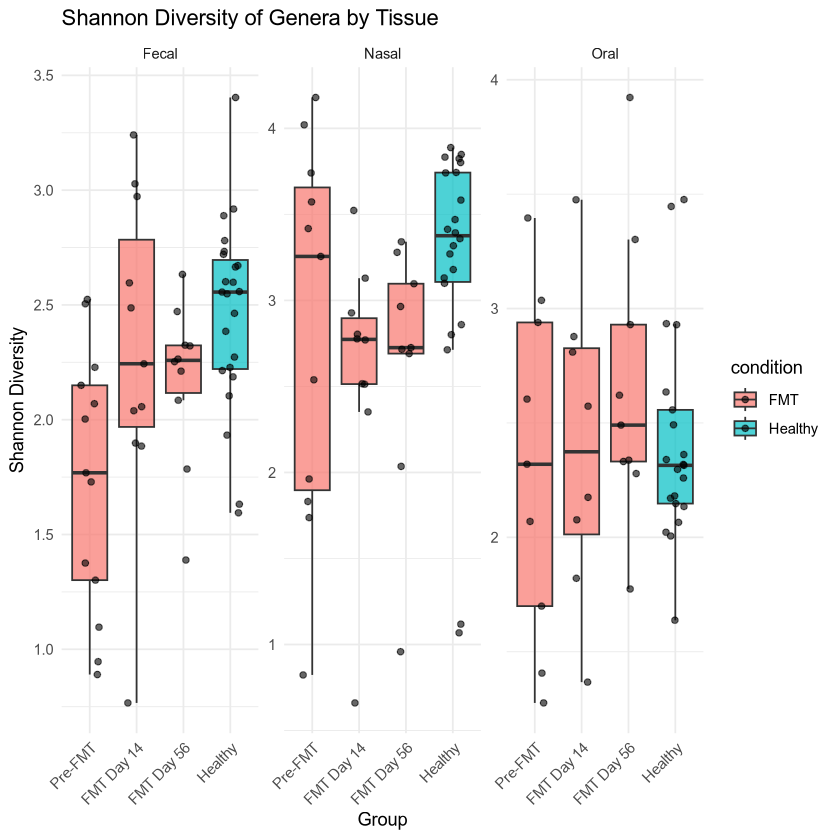

In [110]:

# Ensure you have your data frame loaded (genera_diversity_df)

ggplot(genera_diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter( width = 0.2, alpha = 0.6, size = 1.5) +
  facet_wrap(~ tissue, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "Shannon Diversity of Genera by Tissue",
    x = "Group",
    y = "Shannon Diversity"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

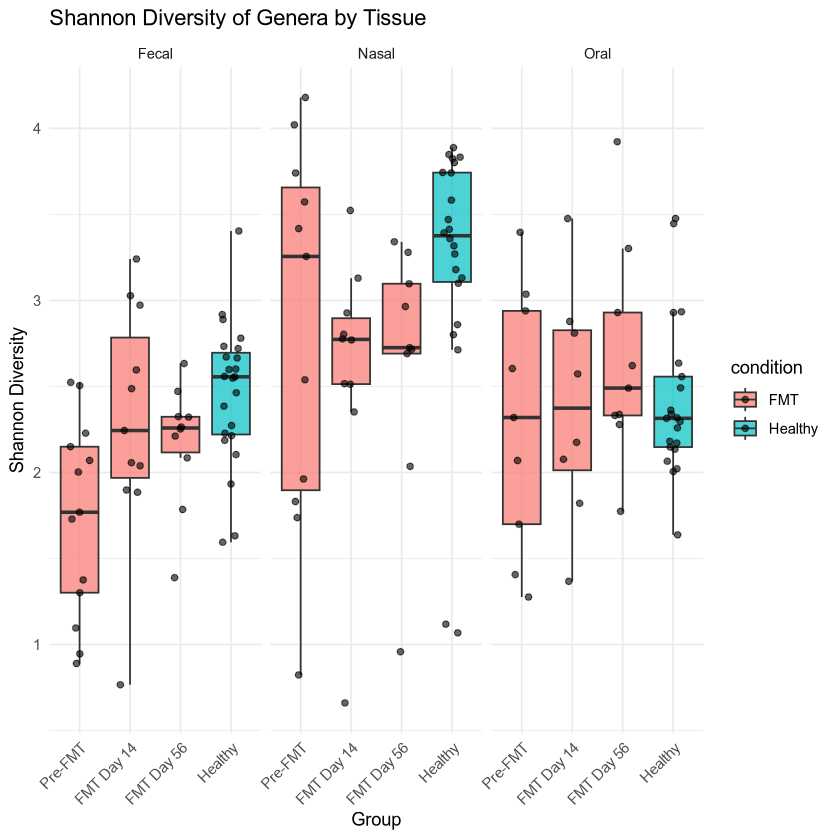

In [111]:

# Ensure you have your data frame loaded (genera_diversity_df)

ggplot(genera_diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter( width = 0.2, alpha = 0.6, size = 1.5) +
  facet_wrap(~ tissue) +  # Removed the scales = "free_y" argument
  theme_minimal() +
  labs(
    title = "Shannon Diversity of Genera by Tissue",
    x = "Group",
    y = "Shannon Diversity"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [112]:
meta

sample,donor,day,tissue,condition,data_origin,sex,age
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
garrett_1,g18,0,Fecal,Healthy,garrett,female,32
garrett_2,g17,0,Fecal,Healthy,garrett,male,30
garrett_3,g10,0,Fecal,FMT,garrett,female,32
garrett_4,g3,0,Fecal,FMT,garrett,female,58
garrett_5,g3,56,Fecal,FMT,garrett,female,58
garrett_6,g19,14,Fecal,Healthy,garrett,female,61
garrett_7,g7,56,Fecal,FMT,garrett,male,40
garrett_8,g12,0,Fecal,FMT,garrett,male,64
garrett_9,g1,56,Fecal,FMT,garrett,female,50


In [113]:
# show rows in meta where age is NA in R
meta[is.na(meta$age), ]


,sample,donor,day,tissue,condition,data_origin,sex,age
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
16,garrett_16,g16,14,Fecal,Healthy,garrett,female,NA
21,garrett_22,g16,0,Fecal,Healthy,garrett,female,NA
72,garrett_63,g16,0,Nasal,Healthy,garrett,female,NA
73,garrett_54,g16,14,Nasal,Healthy,garrett,female,NA
74,garrett_57,g16,0,Oral,Healthy,garrett,female,NA
75,garrett_89,g16,14,Oral,Healthy,garrett,female,NA
97,25617X12,m31,0,Fecal,Healthy,mary,male,NA
98,25617X13,m31,14,Fecal,Healthy,mary,male,NA
120,25617X33,m31,0,Oral,Healthy,mary,male,NA


## Linear Mixed-Effects Model: Genera Alpha Diversity (Shannon)

Dependent variable: Shannon diversity (genera). Fixed effects: group/timepoint, sex, and age (if available). Random effect: `(1 | donor)`, i.e. subject-level intercept, to account for repeated sampling of the same person across timepoints/tissues.

In [114]:
# Load required packages (install once if needed):
# install.packages(c("lme4", "lmerTest", "emmeans"))
library(lme4)
library(lmerTest)   # adds Satterthwaite-approximated p-values to lmer models
library(emmeans)    # for post-hoc pairwise comparisons

# Confirm what columns are actually available to build the model with
colnames(genera_diversity_df)


[1] "sample"              "shannon"             "donor"              
 [4] "day"                 "tissue"              "condition"          
 [7] "data_origin"         "sex"                 "age"                
[10] "condition_day_group"

In [115]:
# ---- Prepare data for the model ----
lme_df <- genera_diversity_df[genera_diversity_df$condition != "Healthy", ]

# donor = subject identifier in this dataset (sample_metadata.tsv has no separate
# "subject_id" column -- "donor" is the column that identifies the same person
# sampled across timepoints/tissues). Rename here for clarity if you'd like:
lme_df$subject_id <- as.factor(lme_df$donor)
lme_df$sex        <- as.factor(lme_df$sex)
lme_df$condition_day_group <- factor(lme_df$condition_day_group,
                                      levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56"))

# Check whether an 'age' column exists in the merged metadata
has_age <- "age" %in% colnames(lme_df)
if (!has_age) {
  message("No 'age' column was found in genera_diversity_df / sample_metadata.tsv.\n",
          "The model below will be fit WITHOUT age as a fixed effect.\n",
          "If you have subject ages, add an 'age' column to sample_metadata.tsv, ",
          "re-run the cells that build genera_diversity_df, then re-run this cell.")
} else {
  lme_df$age <- as.numeric(lme_df$age)
}


In [116]:
# ---- Build and fit the model ----
fixed_terms <- c("condition_day_group", "sex")
if (has_age) fixed_terms <- c(fixed_terms, "age")

lme_formula <- as.formula(
  paste("shannon ~", paste(fixed_terms, collapse = " + "), "+ (1 | subject_id)")
)
lme_formula

genera_lme <- lmer(lme_formula, data = lme_df)
summary(genera_lme)


shannon ~ condition_day_group + sex + age + (1 | subject_id)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: lme_formula
   Data: lme_df

REML criterion at convergence: 216.3

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.03746 -0.60323 -0.03203  0.50373  2.43942 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.02003  0.1415  
 Residual               0.55482  0.7449  
Number of obs: 90, groups:  subject_id, 13

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                    1.853038   0.365475 16.046420   5.070 0.000113
condition_day_groupFMT Day 14  0.207837   0.191820 82.098849   1.084 0.281757
condition_day_groupFMT Day 56  0.268368   0.193589 83.416623   1.386 0.169356
sexmale                       -0.176742   0.180854 10.806843  -0.977 0.349808
age                            0.010172   0.006464 13.103885   1.574 0.139416
                                 
(Intercept)            

In [117]:
# ---- Type III ANOVA (Satterthwaite approximation) for the fixed effects ----
anova(genera_lme)

# ---- 95% Wald confidence intervals for fixed-effect coefficients ----
confint(genera_lme, method = "Wald")


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,1.1971398,0.5985699,2,80.95209,1.0788582,0.3448207
sex,0.5298769,0.5298769,1,10.80684,0.9550465,0.3498077
age,1.3737737,1.3737737,1,13.10388,2.4760801,0.1394156


,2.5 %,97.5 %
.sig01,NA,NA
.sigma,NA,NA
(Intercept),1.136720469,2.56935596
condition_day_groupFMT Day 14,-0.168122315,0.58379684
condition_day_groupFMT Day 56,-0.111059356,0.64779613
sexmale,-0.531209684,0.17772512
age,-0.002497849,0.02284169


 Groups     Name        Std.Dev.
 subject_id (Intercept) 0.14152 
 Residual               0.74486 


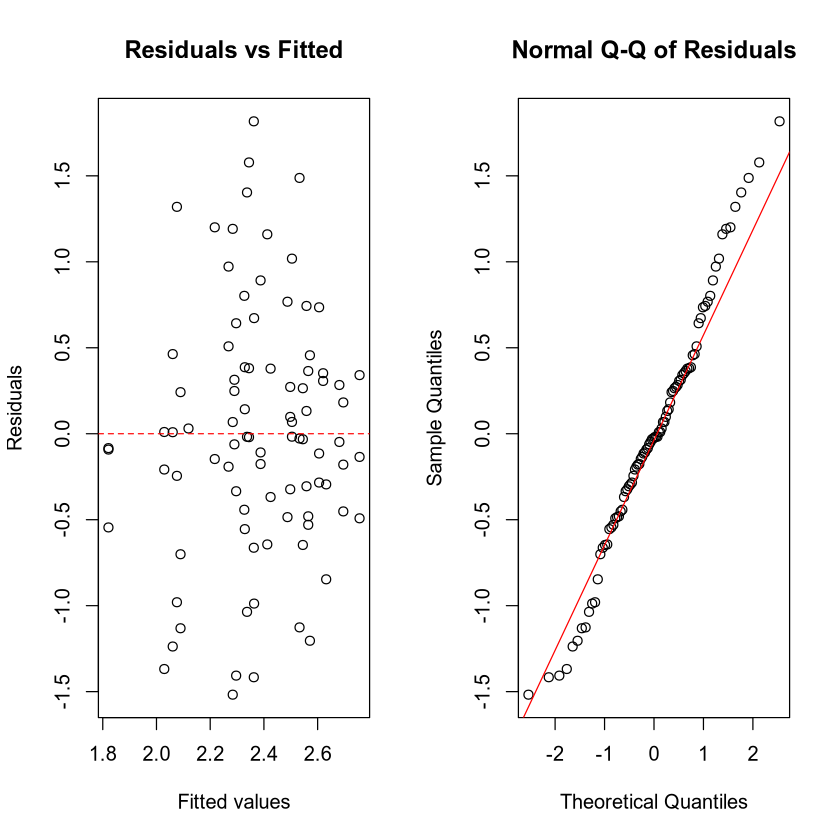

In [118]:
# ---- Model diagnostics ----
par(mfrow = c(1, 2))

plot(fitted(genera_lme), resid(genera_lme),
     xlab = "Fitted values", ylab = "Residuals",
     main = "Residuals vs Fitted")
abline(h = 0, lty = 2, col = "red")

qqnorm(resid(genera_lme), main = "Normal Q-Q of Residuals")
qqline(resid(genera_lme), col = "red")

par(mfrow = c(1, 1))

# Random-effect (subject-level) variance relative to residual variance
print(VarCorr(genera_lme))


In [119]:
# ---- Post-hoc pairwise comparisons across group/timepoint ----
genera_emm <- emmeans(genera_lme, pairwise ~ condition_day_group, adjust = "tukey")
genera_emm$contrasts


 contrast                estimate    SE   df t.ratio p.value
 (Pre-FMT) - FMT Day 14   -0.2078 0.193 81.6  -1.077  0.5313
 (Pre-FMT) - FMT Day 56   -0.2684 0.195 83.2  -1.374  0.3590
 FMT Day 14 - FMT Day 56  -0.0605 0.198 77.2  -0.305  0.9499

Results are averaged over the levels of: sex 
Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 3 estimates 

**Notes / things worth double-checking:**
- `donor` is being used as the subject-level random effect (renamed to `subject_id` for clarity) since that's the column that ties repeated samples back to the same person.
- **Healthy is now excluded from this model** (and from the tissue-stratified models below, since they share `lme_df`). This model is fit on FMT patients only, across all tissues pooled together -- `condition_day_group` has 3 levels: Pre-FMT, FMT Day 14, FMT Day 56.
- This model still pools all `tissue` types (Fecal/Oral/Nasal) together. Since each subject contributes samples from multiple tissues, see the tissue-stratified section below, which fits this same model separately per tissue instead.


In [120]:
# show rows in meta where age is NA
meta[is.na(meta$age), ]

,sample,donor,day,tissue,condition,data_origin,sex,age
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
16,garrett_16,g16,14,Fecal,Healthy,garrett,female,NA
21,garrett_22,g16,0,Fecal,Healthy,garrett,female,NA
72,garrett_63,g16,0,Nasal,Healthy,garrett,female,NA
73,garrett_54,g16,14,Nasal,Healthy,garrett,female,NA
74,garrett_57,g16,0,Oral,Healthy,garrett,female,NA
75,garrett_89,g16,14,Oral,Healthy,garrett,female,NA
97,25617X12,m31,0,Fecal,Healthy,mary,male,NA
98,25617X13,m31,14,Fecal,Healthy,mary,male,NA
120,25617X33,m31,0,Oral,Healthy,mary,male,NA


## Tissue-Stratified Models: FMT Effect by Site (Fecal / Oral / Nasal)

Addressing the reviewer comment that oral, nasal, and fecal microbiota should be evaluated separately (they can be highly individualized, so pooling all three risks masking or confounding site-specific effects). This fits the same model structure -- `shannon ~ condition_day_group + sex [+ age] + (1 | subject_id)` -- independently within each tissue, rather than pooling all three tissues into one model as before.

In [121]:
# ---- Helper: fit the LMM within a single tissue ----
fit_tissue_lmm <- function(tissue_name) {
  d <- subset(lme_df, tissue == tissue_name)
  d$condition_day_group <- droplevels(d$condition_day_group)
  d$sex <- droplevels(d$sex)

  cat("====", tissue_name, "====\n")
  cat("N obs:", nrow(d), "| N subjects:", length(unique(d$subject_id)), "\n\n")

  fixed_terms <- c("condition_day_group", "sex")
  if (has_age) fixed_terms <- c(fixed_terms, "age")
  f <- as.formula(paste("shannon ~", paste(fixed_terms, collapse = " + "), "+ (1 | subject_id)"))

  m <- lmer(f, data = d)
  list(model = m, data = d)
}


**ICC (Intraclass Correlation Coefficient)** measures what fraction of the *total* variance in your outcome (Shannon diversity) is due to consistent differences *between subjects*, versus variance *within* a subject (i.e., noise, timepoint effects, measurement variability, etc.).

**The formula, for a simple random-intercept model like yours:**

$$ICC = \frac{\sigma^2_{subject}}{\sigma^2_{subject} + \sigma^2_{residual}}$$

**Worked example from Fecal model (FMT patients only, Healthy excluded):**
```
Groups     Name        Variance
subject_id (Intercept) 0.1038
Residual               0.2379
```
$$ICC = \frac{0.1038}{0.1038 + 0.2379} = 0.304$$

Same arithmetic gives Oral ≈ 0.3235/(0.3235+0.2031) = 0.614, and Nasal ≈ 0.1576/(0.1576+0.4233) = 0.271.

**Intuition:** if ICC = 0, knowing who the subject is tells you nothing — all variation is "random" within a person too. If ICC = 1, every sample from a given subject would be identical, and all variation would be pure between-person differences. Practically, high ICC means repeated samples from the same person cluster tightly together and resemble each other much more than they resemble samples from a different person.

**Note:** these ICC values are computed from models restricted to FMT patients only (Healthy excluded) -- see the callout after the summary table below for how this changes the story compared to the earlier Healthy-inclusive models.


**Fecal Shannon Diversity — LMM Results**

*n = 34 samples, 13 subjects (FMT patients only; Healthy excluded from the model)*

- **Subject-level variance (ICC ≈ 30%):** random-effect variance (0.104) vs. residual (0.238) — about 30% of the variability in fecal diversity among FMT patients is stable, person-specific variation.
- **FMT Day 14 vs. Pre-FMT: +0.57, p = 0.011 (\*)** — diversity increases significantly two weeks after transplant.
- **FMT Day 56 vs. Pre-FMT: +0.45, p = 0.043 (\*)** — diversity remains elevated at day 56 in the raw model summary (see the Tukey-adjusted version below, which is more conservative).
- **Sex: p = 0.95, Age: p = 0.42** — neither predicts fecal diversity.

**Interpretation:** With Healthy excluded, this is now a purely within-FMT-patient longitudinal comparison. It confirms the fecal diversity increase after FMT is a genuine within-subject phenomenon over time, not an artifact of contrasting FMT patients against a separate Healthy cohort. The effect is a bit weaker here than in the earlier Healthy-inclusive model, consistent with the much smaller sample (13 subjects vs. 22 previously) rather than a different underlying effect.


In [122]:
# ---- Fecal ----
fecal_fit <- fit_tissue_lmm("Fecal")
summary(fecal_fit$model)


==== Fecal ====
N obs: 34 | N subjects: 13 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 66.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.26249 -0.60725  0.04901  0.71763  1.41777 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.1038   0.3222  
 Residual               0.2379   0.4878  
Number of obs: 34, groups:  subject_id, 13

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)                    1.384712   0.489126 13.736105   2.831   0.0135 *
condition_day_groupFMT Day 14  0.572004   0.203494 19.903236   2.811   0.0108 *
condition_day_groupFMT Day 56  0.451243   0.209393 20.426489   2.155   0.0433 *
sexmale                       -0.015796   0.252105  9.595966  -0.063   0.9513  
age                            0.007499   0.008924 12.066750   0.840   0.4171  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 

**Omnibus test (Type III ANOVA):**

- **condition_day_group: F(2, 19.8) = 4.42, p = 0.026 (\*)** — group/timepoint still has a statistically significant overall effect on fecal Shannon diversity, restricted to FMT patients only (now 2 numerator df, since only 3 levels remain without Healthy).
- **sex: F(1, 9.6) = 0.004, p = 0.95** — no effect.
- **age: F(1, 12.1) = 0.71, p = 0.42** — no effect.

**Bottom line:** The significant fecal effect survives removing Healthy from the model -- reassuring, since it confirms the effect reflects a genuine within-patient change over time rather than something driven by contrasting against a different cohort. The p-value is a bit weaker than the Healthy-inclusive version (0.026 vs. 0.007), which lines up with having roughly half the subjects (13 vs. 22) rather than a weaker underlying effect.


In [123]:
anova(fecal_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,2.1033097472,1.0516548736,2,19.801990,4.420467311,0.02586939
sex,0.0009339633,0.0009339633,1,9.595966,0.003925769,0.95132628
age,0.1679830232,0.1679830232,1,12.066750,0.706090450,0.41708413


**Oral Shannon Diversity — LMM Results**

*n = 26 samples, 11 subjects (FMT patients only; Healthy excluded from the model)*

- **Subject-level variance (ICC ≈ 61%):** random-effect variance (0.324) vs. residual (0.203) — roughly three-fifths of the variability in oral diversity among FMT patients is stable, person-specific variation. This is notably *higher* than when Healthy was included (~50%), and is now the highest ICC of the three tissues.
- **FMT Day 14 vs. Pre-FMT: −0.07, p = 0.751** — no change.
- **FMT Day 56 vs. Pre-FMT: +0.23, p = 0.331** — a modest upward trend, not significant.
- **Sex: p = 0.55, Age: p = 0.42** — neither predicts oral diversity.

**Interpretation:** Same conclusion as before -- no detectable FMT effect on oral diversity over time -- but now with an even higher ICC, reinforcing that oral microbiome composition here is overwhelmingly a matter of individual identity rather than treatment or timepoint.


In [124]:
# ---- Oral ----
oral_fit <- fit_tissue_lmm("Oral")
summary(oral_fit$model)


==== Oral ====
N obs: 26 | N subjects: 11 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 54.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.73276 -0.35624 -0.04344  0.48749  1.80395 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.3235   0.5688  
 Residual               0.2031   0.4507  
Number of obs: 26, groups:  subject_id, 11

Fixed effects:
                              Estimate Std. Error       df t value Pr(>|t|)   
(Intercept)                    2.99341    0.75192  9.76850   3.981  0.00272 **
condition_day_groupFMT Day 14 -0.07479    0.23105 14.54594  -0.324  0.75079   
condition_day_groupFMT Day 56  0.22949    0.22825 15.06747   1.005  0.33056   
sexmale                       -0.24855    0.40047  8.24622  -0.621  0.55160   
age                           -0.01100    0.01302  9.16192  -0.845  0.41969   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


**Omnibus test (Type III ANOVA):**

- **condition_day_group: F(2, 14.4) = 1.01, p = 0.388** — no significant effect of timepoint on oral diversity.
- **sex: F(1, 8.2) = 0.39, p = 0.55** — no effect.
- **age: F(1, 9.2) = 0.71, p = 0.42** — no effect.

**Bottom line:** Consistent with before -- no evidence that FMT changes oral diversity over time, considering FMT patients on their own.


In [125]:
anova(oral_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,0.41118001,0.20559001,2,14.441946,1.0122888,0.3877719
sex,0.07823268,0.07823268,1,8.246216,0.3852039,0.5515955
age,0.14497784,0.14497784,1,9.161922,0.7138452,0.4196858


**Nasal Shannon Diversity — LMM Results**

*n = 30 samples, 12 subjects (FMT patients only; Healthy excluded from the model)*

- **Subject-level variance (ICC ≈ 27%):** random-effect variance (0.158) vs. residual (0.423) — a substantial *drop* from the Healthy-inclusive nasal model (~65%). With Healthy controls removed, nasal diversity among FMT patients alone looks considerably less dominated by stable individual differences than it appeared before.
- **FMT Day 14 vs. Pre-FMT: −0.06, p = 0.851** — no change.
- **FMT Day 56 vs. Pre-FMT: +0.01, p = 0.984** — no change.
- **Sex: p = 0.28** — no effect.
- **Age: +0.033, p = 0.018 (\*)** — a new finding: among FMT patients, older age is associated with significantly higher nasal diversity. This wasn't detectable in the Healthy-inclusive model (p = 0.90).

**Interpretation:** Timepoint/FMT still shows no effect on nasal diversity. The notable change is age emerging as a significant predictor once Healthy is excluded -- plausibly because the Healthy cohort's age distribution was previously diluting or masking an age-diversity relationship specific to the FMT patient population. Worth flagging as a new result to look into further (e.g. whether it holds up with more data, and whether it's biologically plausible) rather than folding it silently into the existing narrative.


In [126]:
# ---- Nasal ----
nasal_fit <- fit_tissue_lmm("Nasal")
summary(nasal_fit$model)


==== Nasal ====
N obs: 30 | N subjects: 12 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 72.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0908 -0.5419  0.1526  0.7209  1.2949 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.1576   0.3970  
 Residual               0.4233   0.6506  
Number of obs: 30, groups:  subject_id, 12

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)  
(Intercept)                    1.438993   0.640457 11.652664   2.247   0.0449 *
condition_day_groupFMT Day 14 -0.055616   0.292350 17.073832  -0.190   0.8514  
condition_day_groupFMT Day 56  0.006249   0.301828 17.647884   0.021   0.9837  
sexmale                       -0.387934   0.337202  7.811461  -1.150   0.2840  
age                            0.033364   0.011797  9.942278   2.828   0.0180 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Cor

**Omnibus test (Type III ANOVA):**

- **condition_day_group: F(2, 16.7) = 0.027, p = 0.974** — no effect of timepoint on nasal diversity, even more clearly null than before.
- **sex: F(1, 7.8) = 1.32, p = 0.284** — no effect.
- **age: F(1, 9.9) = 8.00, p = 0.018 (\*)** — significant. Age explains a real amount of variance in nasal diversity among FMT patients specifically.

**Bottom line:** No FMT/timepoint effect, as before -- but age is now a significant, independent predictor of nasal diversity in this patient population, the first significant age effect seen anywhere in this analysis, pooled or tissue-stratified, with or without Healthy.


In [127]:
anova(nasal_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,0.0224574,0.0112287,2,16.740097,0.02652835,0.97386129
sex,0.5602144,0.5602144,1,7.811461,1.32353349,0.28395683
age,3.3855077,3.3855077,1,9.942278,7.99842517,0.01800491


| Tissue | ICC (subject variance) | Omnibus group/timepoint p | Other notable effects |
|---|---|---|---|
| **Fecal** | ~30% | **0.026 (\*)** | Significant FMT effect, driven mainly by Day 14 |
| **Oral** | ~61% | 0.388 | No effect; now the highest ICC of the three |
| **Nasal** | ~27% | 0.974 | No effect; **age significant (p = 0.018)** |

**Important change from the Healthy-inclusive analysis:** excluding Healthy changes the ICC pattern substantially. Previously (with Healthy included), ICC rose monotonically from Fecal (~30%) → Oral (~50%) → Nasal (~65%) -- a clean "increasing individualization" story. **With Healthy excluded, that gradient no longer holds:** Oral is now the highest-ICC tissue (~61%), and Nasal drops to the lowest (~27%), essentially tied with Fecal.

This is worth sitting with rather than smoothing over:
1. **Sample size:** each tissue model now has only 11-13 subjects, down from 22-24. Variance-component estimates (especially the subject-level one the ICC depends on) get noticeably noisier with so few groups -- part of this swing may reflect estimation instability rather than a true underlying pattern.
2. **Healthy's role in the original gradient:** it's possible the original increasing-ICC story was partly driven by how differently Healthy controls' oral/nasal microbiomes looked compared to FMT patients, rather than reflecting individual variation *within* FMT patients specifically. Removing Healthy removes that source of between-group variance, and the ICC can shift either direction depending on the tissue.




**Note on convergence:** with samples split three ways, some tissues have as few as ~2 observations per subject on average. If you see a `boundary (singular fit)` warning, it means the subject-level variance was estimated at (or near) zero for that tissue -- i.e. not enough repeated structure to separately estimate between- vs. within-subject variance. That's a sample-size limitation to report, not a coding error, and the fixed-effect estimates above are still valid.

In [128]:
# ---- Omnibus group/timepoint effect, side-by-side across tissues ----
extract_group_effect <- function(fit, tissue_name) {
  a <- anova(fit$model)
  data.frame(tissue = tissue_name,
             n_obs = nrow(fit$data),
             n_subjects = length(unique(fit$data$subject_id)),
             group_F = a["condition_day_group", "F value"],
             group_p = a["condition_day_group", "Pr(>F)"])
}

group_effect_summary <- rbind(
  extract_group_effect(fecal_fit, "Fecal"),
  extract_group_effect(oral_fit,  "Oral"),
  extract_group_effect(nasal_fit, "Nasal")
)
group_effect_summary


tissue,n_obs,n_subjects,group_F,group_p
<chr>,<int>,<int>,<dbl>,<dbl>
Fecal,34,13,4.42046731,0.02586939
Oral,26,11,1.01228878,0.38777194
Nasal,30,12,0.02652835,0.97386129


**Post-Hoc Pairwise Comparisons (Tukey-adjusted) by Tissue**

With Healthy excluded, each tissue now has only 3 pairwise comparisons (Pre-FMT vs. Day 14, Pre-FMT vs. Day 56, Day 14 vs. Day 56) instead of 6.

*Note on sign convention:* contrasts are ordered as `(first level) − (second level)`. E.g. `(Pre-FMT) − FMT Day 14 = −0.572` means Day 14 is higher than Pre-FMT by 0.572, matching the `+0.572` from the model summary.

**Fecal:**
- **Pre-FMT vs. Day 14: p = 0.029 (\*)** — still significant after Tukey correction.
- **Pre-FMT vs. Day 56: p = 0.107** — not significant after correction (was borderline at p = 0.043 in the uncorrected model summary).
- **Day 14 vs. Day 56: p = 0.842** — no difference between the two post-treatment timepoints; diversity doesn't keep rising (or fall back) between Day 14 and Day 56.

**Oral:** all three comparisons non-significant (p = 0.946, 0.597, 0.390).

**Nasal:** all three comparisons non-significant (p = 0.981, 1.000, 0.977).

**Bottom line:** With Healthy no longer in the model, the clearest fecal signal is specifically the Pre-FMT → Day 14 increase; Day 56 trends the same direction but doesn't clear the corrected significance bar at this smaller sample size (13 subjects). Oral and Nasal show no significant pairwise differences at any timepoint, consistent with their null omnibus tests.


In [129]:
# ---- Pairwise comparisons across group/timepoint, within each tissue ----
posthoc_by_tissue <- rbind(
  as.data.frame(emmeans(fecal_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Fecal"),
  as.data.frame(emmeans(oral_fit$model,  pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Oral"),
  as.data.frame(emmeans(nasal_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Nasal")
)
posthoc_by_tissue <- posthoc_by_tissue[, c("tissue", setdiff(names(posthoc_by_tissue), "tissue"))]
posthoc_by_tissue


tissue,contrast,estimate,SE,df,t.ratio,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fecal,(Pre-FMT) - FMT Day 14,-0.572003746,0.2046807,20.39298,-2.79461428,0.02854426
Fecal,(Pre-FMT) - FMT Day 56,-0.451242954,0.2112705,20.89953,-2.13585392,0.10674822
Fecal,FMT Day 14 - FMT Day 56,0.120760792,0.2150388,19.63036,0.56157670,0.84178814
Oral,(Pre-FMT) - FMT Day 14,0.074786527,0.2343865,14.27417,0.31907346,0.94563698
Oral,(Pre-FMT) - FMT Day 56,-0.229490169,0.2328313,14.80831,-0.98565020,0.59686624
Oral,FMT Day 14 - FMT Day 56,-0.304276696,0.2242979,13.54532,-1.35657381,0.38980965
Nasal,(Pre-FMT) - FMT Day 14,0.055616116,0.2958305,17.94026,0.18799992,0.98072478
Nasal,(Pre-FMT) - FMT Day 56,-0.006248662,0.3067188,18.47554,-0.02037261,0.99977120
Nasal,FMT Day 14 - FMT Day 56,-0.061864778,0.3020253,16.66733,-0.20483310,0.97716715


**Figure 2 (Shannon panel), with LMM/Tukey significance brackets**

Brackets are drawn only for comparisons significant at Tukey-adjusted p < 0.05 in `posthoc_by_tissue` (computed above). Healthy is shown as a visual reference only, as before -- it was never part of the LMM/Tukey comparisons, so it never gets a bracket.


In [130]:
# install.packages("ggsignif")  # if not already installed
library(ggsignif)

# ---- Helper: build significance-bracket data from a Tukey-adjusted emmeans contrast table ----
# Parses "(GroupA) - GroupB" contrast strings into x-axis positions, keeps only p < alpha,
# and stacks brackets within a tissue (narrower spans lower, wider spans higher) so they don't overlap.
build_sig_brackets <- function(posthoc_df, outcome_df, outcome_col, group_levels, alpha = 0.05) {
  contrast_split <- stringr::str_split_fixed(gsub("[()]", "", posthoc_df$contrast), " - ", 2)

  brackets <- posthoc_df %>%
    mutate(
      group1 = trimws(contrast_split[, 1]),
      group2 = trimws(contrast_split[, 2]),
      xmin   = match(group1, group_levels),
      xmax   = match(group2, group_levels)
    ) %>%
    filter(p.value < alpha, !is.na(xmin), !is.na(xmax)) %>%
    mutate(
      label = case_when(
        p.value < 0.001 ~ "***",
        p.value < 0.01  ~ "**",
        TRUE            ~ "*"
      ),
      span = abs(xmax - xmin)
    ) %>%
    select(tissue, xmin, xmax, label, span)

  if (nrow(brackets) == 0) return(brackets)  # nothing significant -- no brackets to draw

  range_df <- outcome_df %>%
    group_by(tissue) %>%
    summarize(y_max = max(.data[[outcome_col]], na.rm = TRUE),
              y_range = diff(range(.data[[outcome_col]], na.rm = TRUE)), .groups = "drop")

  brackets %>%
    left_join(range_df, by = "tissue") %>%
    group_by(tissue) %>%
    arrange(span, .by_group = TRUE) %>%
    mutate(y_position = y_max + row_number() * 0.10 * y_range) %>%
    ungroup()
}

# Only the 3 FMT timepoints have LMM/Tukey contrasts (Healthy was excluded from the model)
group_levels_fmt <- c("Pre-FMT", "FMT Day 14", "FMT Day 56")

sig_diversity <- build_sig_brackets(posthoc_by_tissue, genera_diversity_df, "shannon", group_levels_fmt)
sig_diversity


tissue,xmin,xmax,label,span,y_max,y_range,y_position
<chr>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Fecal,1,2,*,1,3.403649,2.637363,3.667385


Warning message in geom_signif(data = sig_diversity, aes(xmin = xmin, xmax = xmax, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”


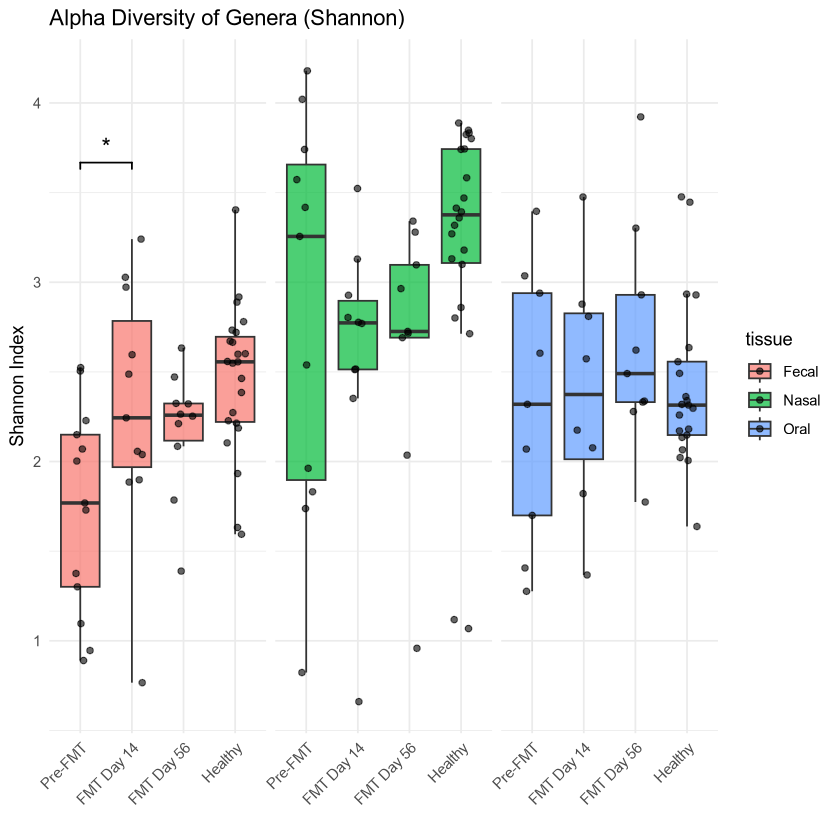

In [131]:
# ---- Shannon diversity boxplot with significance brackets from the tissue-stratified LMM ----
ggplot(genera_diversity_df, aes(x = condition_day_group, y = shannon, fill = tissue)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.6, size = 1.5) +
  geom_signif(
    data = sig_diversity,
    aes(xmin = xmin, xmax = xmax, annotations = label, y_position = y_position),
    manual = TRUE, inherit.aes = FALSE, tip_length = 0.01, textsize = 5
  ) +
  facet_wrap(~ tissue) +
  theme_minimal() +
  labs(
    title = "Alpha Diversity of Genera (Shannon)",
    x = " ",
    y = "Shannon Index"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), strip.text = element_blank())


**Summary of what this section adds:**
- Three independent models (Fecal, Oral, Nasal), each restricted to FMT patients only (Healthy excluded), with the same fixed/random effect structure as before.
- An omnibus F-test for `condition_day_group` within each tissue (`group_effect_summary`), now testing only Pre-FMT vs. Day 14 vs. Day 56 (2 df instead of 3).
- Pairwise contrasts among the three FMT timepoints within each tissue, Tukey-adjusted via `emmeans` (`posthoc_by_tissue`) -- no Healthy contrasts, since Healthy is no longer part of the model.
- Reported sample sizes per tissue, now noticeably smaller (11-13 subjects) since both the tissue split and the Healthy exclusion reduce the pool.


## Checking Skewness of Raw Shannon Diversity

This checks the *raw outcome* (before any modeling) for asymmetry -- distinct from the residual diagnostics above, since a skewed raw variable doesn't necessarily mean skewed model residuals.

In [132]:
# ---- Skewness check (base R, no extra packages) ----
skewness <- function(x) {
  x <- x[!is.na(x)]
  n <- length(x)
  m3 <- sum((x - mean(x))^3) / n
  m2 <- sum((x - mean(x))^2) / n
  m3 / m2^1.5
}
# Rule of thumb: |skew| < 0.5 ~ fairly symmetric, 0.5-1 ~ moderate, >1 ~ substantial

cat("Overall shannon skewness:", round(skewness(genera_diversity_df$shannon), 2), "\n")
cat("Overall mean:", round(mean(genera_diversity_df$shannon, na.rm = TRUE), 2),
    " median:", round(median(genera_diversity_df$shannon, na.rm = TRUE), 2), "\n\n")

for (t in c("Fecal", "Oral", "Nasal")) {
  vals <- genera_diversity_df$shannon[genera_diversity_df$tissue == t]
  cat(t, "- skewness:", round(skewness(vals), 2),
      " | mean:", round(mean(vals, na.rm = TRUE), 2),
      " | median:", round(median(vals, na.rm = TRUE), 2), "\n")
}

Overall shannon skewness: -0.16 
Overall mean: 2.51  median: 2.51 

Fecal - skewness: -0.59  | mean: 2.21  | median: 2.25 
Oral - skewness: 0.34  | mean: 2.44  | median: 2.33 
Nasal - skewness: -1.05  | mean: 2.91  | median: 3.11 


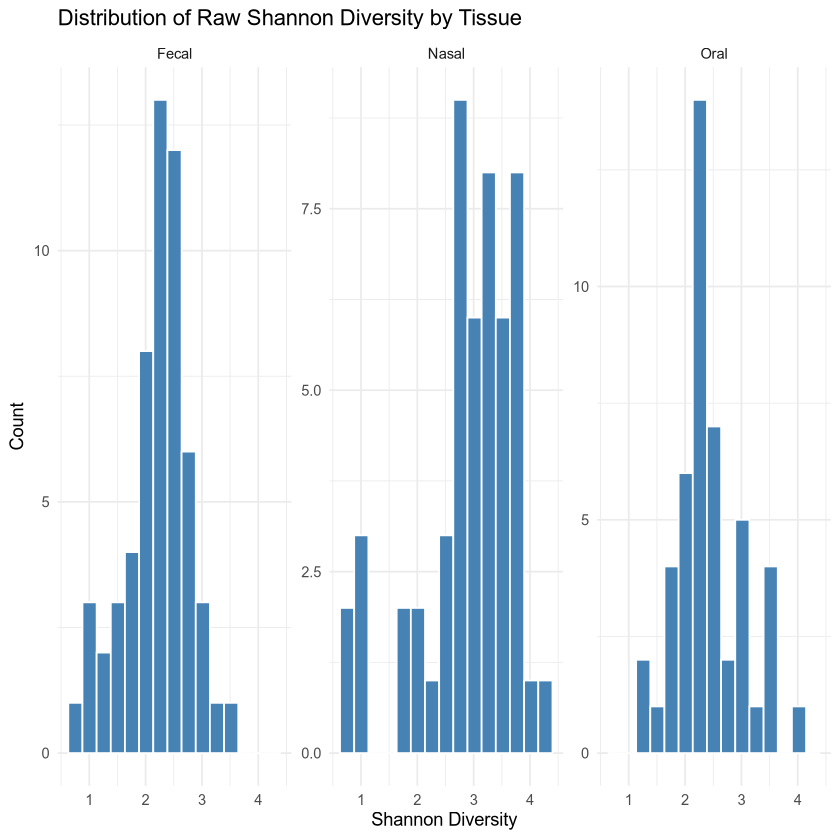

In [133]:
# ---- Visualize the distribution per tissue ----
ggplot(genera_diversity_df, aes(x = shannon)) +
  geom_histogram(bins = 15, fill = "steelblue", color = "white") +
  facet_wrap(~ tissue, scales = "free_y") +
  labs(title = "Distribution of Raw Shannon Diversity by Tissue",
       x = "Shannon Diversity", y = "Count") +
  theme_minimal()

## Checking Model Assumptions (Fecal / Oral / Nasal)

Before leaning on the tissue-stratified p-values, it's worth checking the assumptions the LMM is actually making: linearity, normally-distributed residuals, constant residual variance (homoscedasticity), and normally-distributed subject-level random effects. This uses only base R (`shapiro.test`, `qqnorm`, `plot`) -- no extra packages needed.

In [134]:
# ---- Helper: 4-panel diagnostic plot + normality tests for one model ----
check_lmm_assumptions <- function(model, model_name) {
  resids <- resid(model)
  fitted_vals <- fitted(model)
  re <- ranef(model)$subject_id[[1]]

  par(mfrow = c(2, 2))

  # 1. Residuals vs Fitted -- checks linearity (should scatter randomly around 0,
  #    no curve/funnel shape)
  plot(fitted_vals, resids, xlab = "Fitted values", ylab = "Residuals",
       main = paste(model_name, "- Residuals vs Fitted"))
  abline(h = 0, lty = 2, col = "red")
  lines(lowess(fitted_vals, resids), col = "blue")

  # 2. Q-Q plot of residuals -- checks normality of residuals
  qqnorm(resids, main = paste(model_name, "- Q-Q Residuals"))
  qqline(resids, col = "red")

  # 3. Scale-Location -- checks homoscedasticity (constant spread across fitted values;
  #    a rising/falling trend suggests variance isn't constant)
  plot(fitted_vals, sqrt(abs(resids)), xlab = "Fitted values", ylab = "sqrt(|Residuals|)",
       main = paste(model_name, "- Scale-Location"))
  lines(lowess(fitted_vals, sqrt(abs(resids))), col = "blue")

  # 4. Q-Q plot of subject-level random effects -- checks normality of random intercepts
  qqnorm(re, main = paste(model_name, "- Q-Q Random Effects"))
  qqline(re, col = "red")

  par(mfrow = c(1, 1))

  cat("====", model_name, "====\n")
  sw_resid <- shapiro.test(resids)
  cat("Shapiro-Wilk (residuals):      W =", round(sw_resid$statistic, 3),
      ", p =", signif(sw_resid$p.value, 3), "\n")
  if (length(re) >= 3) {
    sw_re <- shapiro.test(re)
    cat("Shapiro-Wilk (random effects): W =", round(sw_re$statistic, 3),
        ", p =", signif(sw_re$p.value, 3), "\n")
  } else {
    cat("Too few subject groups for a meaningful Shapiro-Wilk test on random effects.\n")
  }
  cat("\n")
}

==== Pooled (all tissues) ====
Shapiro-Wilk (residuals):      W = 0.985 , p = 0.405 
Shapiro-Wilk (random effects): W = 0.87 , p = 0.0527 



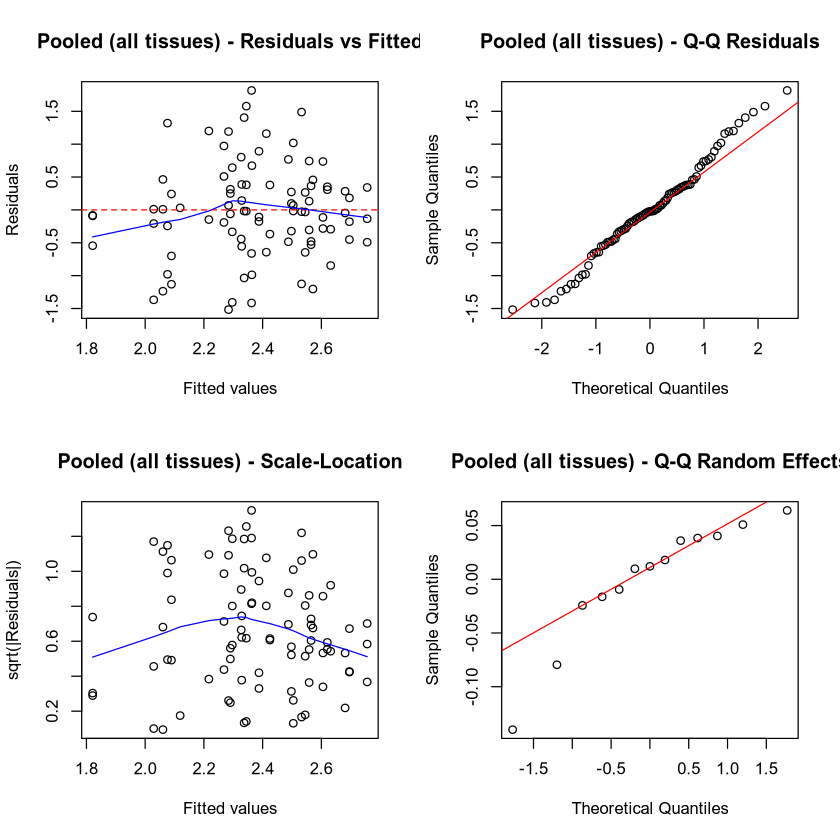

In [135]:
check_lmm_assumptions(genera_lme, "Pooled (all tissues)")


==== Fecal ====
Shapiro-Wilk (residuals):      W = 0.973 , p = 0.536 
Shapiro-Wilk (random effects): W = 0.976 , p = 0.957 



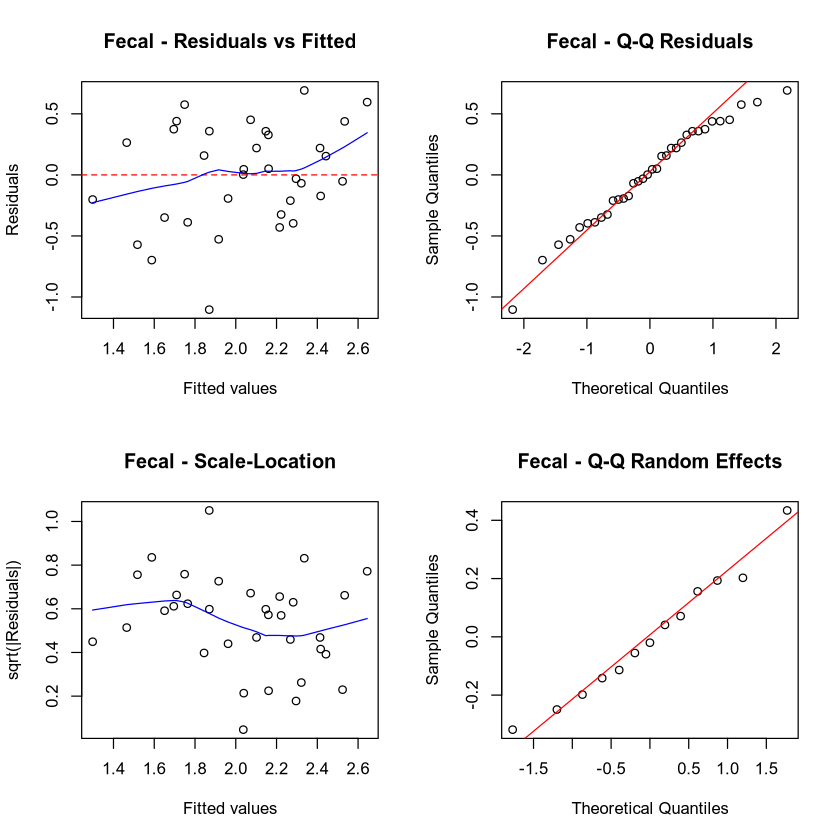

In [136]:
check_lmm_assumptions(fecal_fit$model, "Fecal")


==== Oral ====
Shapiro-Wilk (residuals):      W = 0.988 , p = 0.987 
Shapiro-Wilk (random effects): W = 0.94 , p = 0.521 



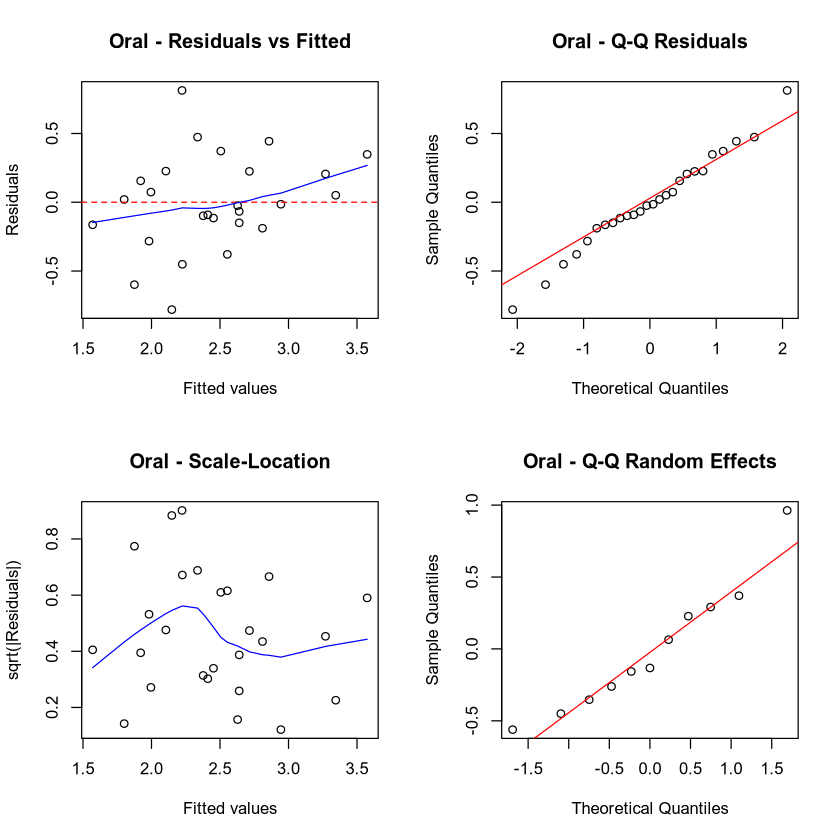

In [137]:
check_lmm_assumptions(oral_fit$model, "Oral")


==== Nasal ====
Shapiro-Wilk (residuals):      W = 0.954 , p = 0.22 
Shapiro-Wilk (random effects): W = 0.959 , p = 0.767 



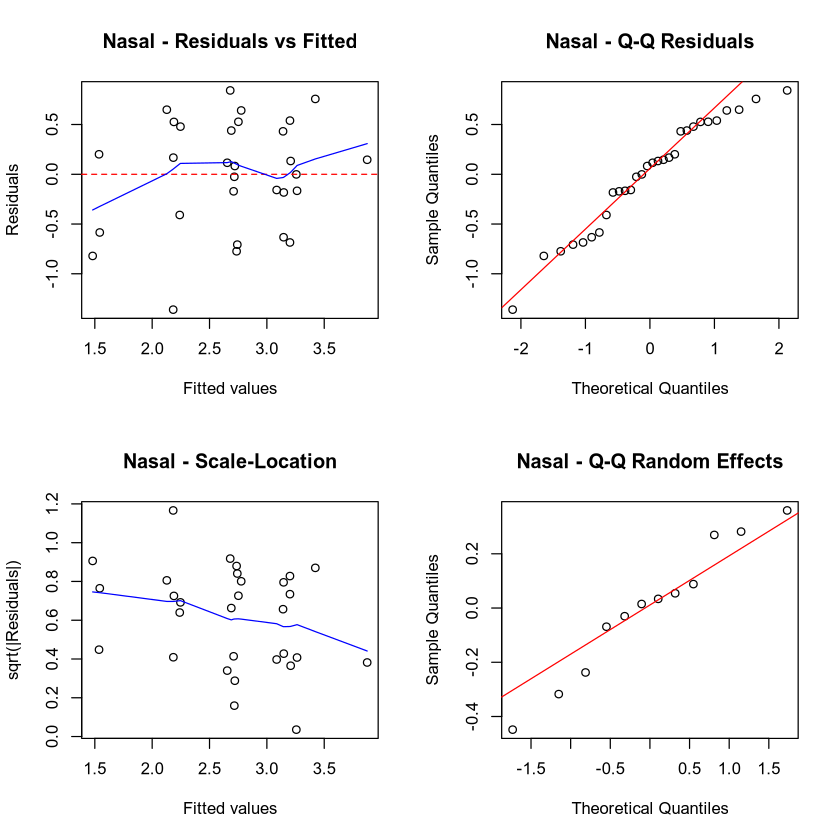

In [138]:
check_lmm_assumptions(nasal_fit$model, "Nasal")


SHANNON DIVERSITY OF SPECIES

In [139]:
# Load necessary libraries
library(vegan)      # for diversity
library(tidyverse)  # for data manipulation and plotting

# Clean file on the fly (remove single quotes)
counts <- read.table(pipe("sed \"s/'//g\" species_counts.tsv"),
                     header = TRUE, sep = "\t", row.names = 1)


# Transpose if taxa are rows and samples are columns
counts_t <- as.data.frame(t(counts))


In [140]:
#list all of the row names in counts_t and sort
counts_t <- counts_t[order(rownames(counts_t)), ]
# remove row garret_20 from counts_t
counts_t <- counts_t[!rownames(counts_t) %in% "garrett_20", ]
# remove row garret_73 from counts_t
counts_t <- counts_t[!rownames(counts_t) %in% "garrett_73", ]
row_names <- rownames(counts_t)
#row_names

In [141]:
# Shannon diversity for each sample
shannon_div <- diversity(counts_t, index = "shannon")
# see the value of garrett_96 in shannon_div
#shannon_div

In [142]:
meta <- read.table("sample_metadata.tsv", header = TRUE, sep = "\t")
names(shannon_div) <- sub("^X", "", names(shannon_div))
meta$sample <- trimws(meta$sample)


# Merge diversity and metadata
diversity_df <- data.frame(sample = names(shannon_div), shannon = shannon_div)
diversity_df <- merge(diversity_df, meta, by = "sample")
meta$sample[meta$tissue == "Fecal" & meta$condition == "FMT" & meta$day == 56] # list samples that meet the condition
# save diversity_df to excel
write.table(diversity_df, "species_shannon_diversity.tsv", sep = "\t", row.names = FALSE, quote = FALSE)
 

[1] "garrett_5"  "garrett_7"  "garrett_9"  "garrett_13" "garrett_15"
 [6] "garrett_19" "garrett_48" "25617X11"   "25617X18"   "25617X21"

In [143]:
#names(shannon_div)

In [144]:
diversity_df <- diversity_df %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    condition == "Healthy"~ "Healthy",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group, 
                                      levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))


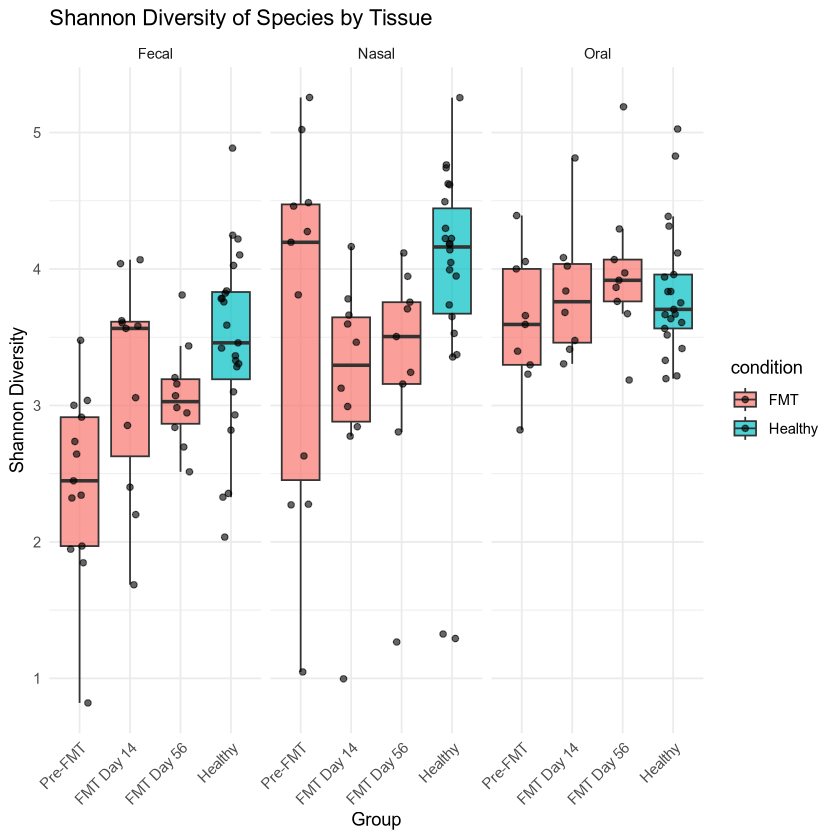

In [145]:
# Ensure you have your data frame loaded (genera_diversity_df)

ggplot(diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter( width = 0.2, alpha = 0.6, size = 1.5) +
  facet_wrap(~ tissue) +  # Removed the scales = "free_y" argument
  theme_minimal() +
  labs(
    title = "Shannon Diversity of Species by Tissue",
    x = "Group",
    y = "Shannon Diversity"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

RICHNESS

In [146]:
# Richness: number of nonzero taxa per sample
richness <- apply(genera_counts_t, 1, function(x) sum(x > 0))
richness
names(richness) <- sub("^X", "", names(richness))
meta$sample <- trimws(meta$sample)

# Log10 richness
log_richness <- log10(richness)

# Optionally: create a data frame and merge with metadata
genera_richness_df <- data.frame(sample = names(richness), richness = richness, log10_richness = log_richness)
genera_richness_df <- merge(genera_richness_df, meta, by = "sample")

write.table(genera_richness_df, "genera_richness.tsv", sep = "\t", row.names = FALSE, quote = FALSE)


garrett_1 garrett_10 garrett_11 garrett_12 garrett_13 garrett_14 garrett_15 
      1517       1062       1234       1625        849        187       1263 
garrett_16 garrett_17 garrett_18 garrett_19  garrett_2 garrett_21 garrett_22 
      1631        246        487       1272       1144       1196       1463 
garrett_23 garrett_24 garrett_25 garrett_26 garrett_27 garrett_28 garrett_29 
      1435       1548       1554       1334       1370       1451       1878 
 garrett_3 garrett_30 garrett_31 garrett_32 garrett_33 garrett_34 garrett_35 
      1434       1083        927       1653         81         95        719 
garrett_36 garrett_37 garrett_38 garrett_39  garrett_4 garrett_40 garrett_41 
       956         99        434        726        280        365        182 
garrett_42 garrett_43 garrett_44 garrett_45 garrett_46 garrett_47 garrett_48 
       122        781        134        180       1154        257       1244 
garrett_49  garrett_5 garrett_50 garrett_51 garrett_52 garrett_53 garrett_54 
       135        486        193        177        108        205         54 
garrett_55 garrett_56 garrett_57 garrett_58 garrett_59  garrett_6 garrett_60 
       105        114         93         62         87       1711        141 
garrett_61 garrett_62 garrett_63 garrett_64 garrett_65 garrett_66 garrett_67 
       195        436         36        163        149        388        564 
garrett_68 garrett_69  garrett_7 garrett_70 garrett_71 garrett_72 garrett_74 
       327         81       1451        372        234        644        119 
garrett_75 garrett_76 garrett_77 garrett_78 garrett_79  garrett_8 garrett_80 
        49        286       1388        378        135        294         58 
garrett_81 garrett_83 garrett_84 garrett_85 garrett_86 garrett_87 garrett_88 
        41         37         58        277        191        178        384 
garrett_89  garrett_9 garrett_90 garrett_91 garrett_92 garrett_93 garrett_94 
       178       1692         64        120        192         80        107 
garrett_95 garrett_96   X25617X1  X25617X10  X25617X11  X25617X12  X25617X13 
       319        409       2077       1328       1039       2022       2080 
 X25617X14  X25617X15  X25617X16  X25617X17  X25617X18  X25617X19   X25617X2 
       764       1952       2068       2215       2313       1299       2043 
 X25617X20  X25617X21  X25617X22  X25617X23  X25617X24  X25617X25  X25617X26 
      2025       1961        954       1564       1367       1158       1386 
 X25617X27  X25617X28  X25617X29   X25617X3  X25617X30  X25617X31  X25617X32 
      1208       1699       1368       2033        579        555        573 
 X25617X33  X25617X34  X25617X35  X25617X36  X25617X37  X25617X38  X25617X39 
      1208        748        699        680       1370        881        644 
  X25617X4  X25617X40  X25617X41  X25617X42  X25617X43  X25617X44  X25617X45 
      1945        788        577        560        279        235        407 
 X25617X46  X25617X47  X25617X48  X25617X49   X25617X5  X25617X50  X25617X51 
       447        287        327        401       1823        713        495 
 X25617X52  X25617X53  X25617X54  X25617X55  X25617X56  X25617X57  X25617X58 
       608        533        443        489        592        368        139 
 X25617X59   X25617X6  X25617X60  X25617X61  X25617X62  X25617X63   X25617X7 
       154       1972        138        258        303        246       2123 
  X25617X8   X25617X9 
      2110        776

In [147]:
# 6. Create a custom grouping: separate FMT by day, collapse Healthy into one group
genera_richness_df <- genera_richness_df %>%
  mutate(condition_day_group = ifelse(condition == "Healthy", "Healthy_AllDays", paste0("FMT_day", day)))


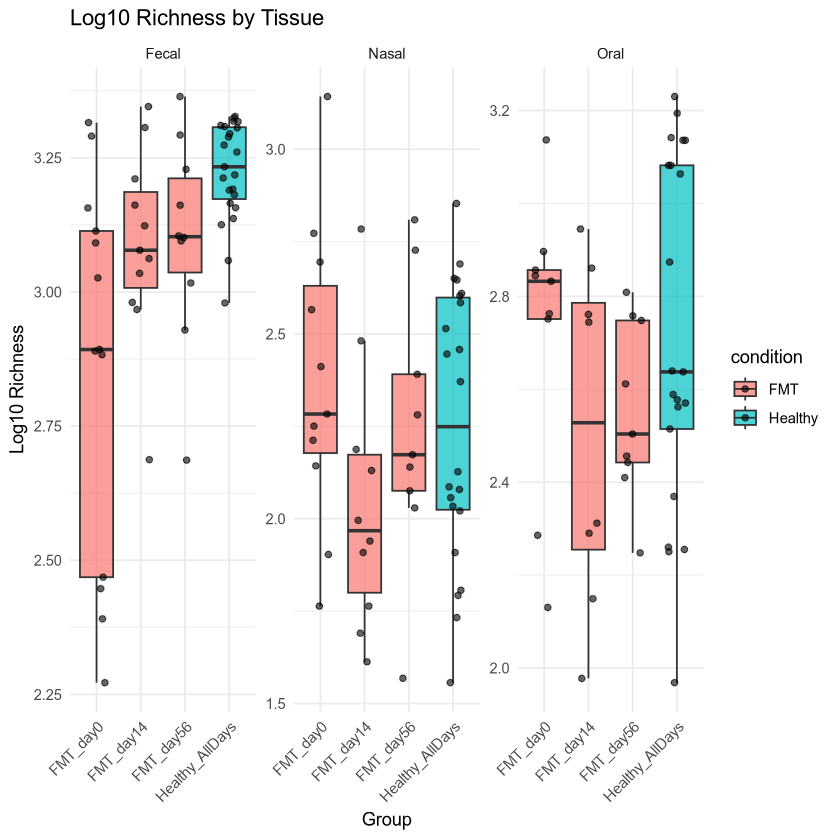

In [148]:
ggplot(genera_richness_df, aes(x = condition_day_group, y = log10_richness, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Hide boxplot outliers to avoid clutter
  geom_jitter(width = 0.2, alpha = 0.6, size = 1.5) +  # Add jittered points
  facet_wrap(~ tissue, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "Log10 Richness by Tissue",
    x = "Group",
    y = "Log10 Richness"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


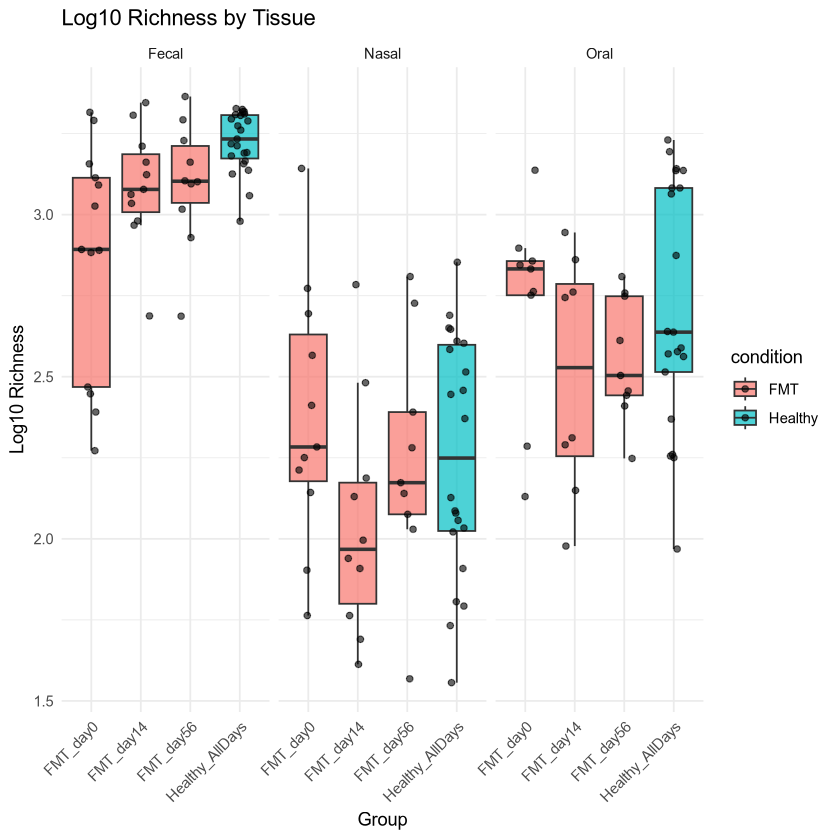

In [149]:
ggplot(genera_richness_df, aes(x = condition_day_group, y = log10_richness, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Hide boxplot outliers to avoid clutter
  geom_jitter( width = 0.2, alpha = 0.6, size = 1.5) +  # Add jittered points
  facet_wrap(~ tissue) +
  theme_minimal() +
  labs(
    title = "Log10 Richness by Tissue",
    x = "Group",
    y = "Log10 Richness"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [150]:
# 6. Create a custom grouping: separate FMT by day, collapse Healthy into one group
genera_richness_df <- genera_richness_df %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    condition == "Healthy"~ "Healthy",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group, 
                                      levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))

# # 7. Plot
# ggplot(diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
#   geom_boxplot() +
#   theme_minimal() +
#   labs(
#     title = "Shannon Diversity: FMT by Day, All Healthy Combined",
#     x = "Group",
#     y = "Shannon Diversity"
#   ) +
#   theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Linear Mixed-Effects Model: Genera Richness (log10), Tissue-Stratified

Mirrors the Shannon diversity analysis exactly: same fixed effects (`condition_day_group + sex [+ age]`), same random intercept (`1 | subject_id`), same tissue stratification, and **Healthy excluded from the model** (kept only as a visual reference in Figure 2). Outcome here is `log10_richness` rather than `shannon`.

In [151]:
# ---- Prepare data for the richness model ----
# Excluding Healthy from the model itself, same as the Shannon analysis -- Healthy
# remains in Figure 2 as a visual reference only.
lme_df_richness <- genera_richness_df[genera_richness_df$condition != "Healthy", ]

lme_df_richness$subject_id <- as.factor(lme_df_richness$donor)
lme_df_richness$sex        <- as.factor(lme_df_richness$sex)
lme_df_richness$condition_day_group <- factor(lme_df_richness$condition_day_group,
                                                levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56"))

has_age_richness <- "age" %in% colnames(lme_df_richness)
if (has_age_richness) {
  lme_df_richness$age <- as.numeric(lme_df_richness$age)
}


In [152]:
# ---- Helper: fit the richness LMM within a single tissue ----
fit_tissue_lmm_richness <- function(tissue_name) {
  d <- subset(lme_df_richness, tissue == tissue_name)
  d$condition_day_group <- droplevels(d$condition_day_group)
  d$sex <- droplevels(d$sex)

  cat("====", tissue_name, "====\n")
  cat("N obs:", nrow(d), "| N subjects:", length(unique(d$subject_id)), "\n\n")

  fixed_terms <- c("condition_day_group", "sex")
  if (has_age_richness) fixed_terms <- c(fixed_terms, "age")
  f <- as.formula(paste("log10_richness ~", paste(fixed_terms, collapse = " + "), "+ (1 | subject_id)"))

  m <- lmer(f, data = d)
  list(model = m, data = d)
}


In [153]:
# ---- Fecal ----
fecal_rich_fit <- fit_tissue_lmm_richness("Fecal")
summary(fecal_rich_fit$model)


==== Fecal ====
N obs: 34 | N subjects: 13 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 18.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.82463 -0.32749  0.03538  0.50076  1.43158 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.02477  0.1574  
 Residual               0.04406  0.2099  
Number of obs: 34, groups:  subject_id, 13

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                    2.885378   0.223147 12.707763  12.930  1.1e-08
condition_day_groupFMT Day 14  0.233539   0.087748 19.159171   2.661   0.0153
condition_day_groupFMT Day 56  0.250830   0.090370 19.651335   2.776   0.0118
sexmale                        0.156993   0.116344  8.977224   1.349   0.2103
age                           -0.001946   0.004088 11.243919  -0.476   0.6431
                                 
(Intercept)                   ***
condi

In [154]:
anova(fecal_rich_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,0.445813162,0.222906581,2,19.044969,5.059242,0.01728947
sex,0.080224015,0.080224015,1,8.977224,1.820820,0.21025958
age,0.009986083,0.009986083,1,11.243919,0.226651,0.64313462


In [155]:
# ---- Oral ----
oral_rich_fit <- fit_tissue_lmm_richness("Oral")
summary(oral_rich_fit$model)


==== Oral ====
N obs: 26 | N subjects: 11 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 21.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0219 -0.2372  0.1317  0.5195  1.7740 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.006842 0.08272 
 Residual               0.068091 0.26094 
Number of obs: 26, groups:  subject_id, 11

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                    2.768644   0.243351  9.221206  11.377 9.83e-07
condition_day_groupFMT Day 14 -0.212117   0.128475 15.277932  -1.651    0.119
condition_day_groupFMT Day 56 -0.172630   0.124948 15.990720  -1.382    0.186
sexmale                        0.210809   0.119320  6.490514   1.767    0.124
age                           -0.003420   0.004093  8.166540  -0.835    0.427
                                 
(Intercept)                   ***
condition_day_g

In [156]:
anova(oral_rich_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,0.2142251,0.1071125,2,14.945582,1.5730893,0.2398819
sex,0.2125392,0.2125392,1,6.490514,3.1214190,0.1239529
age,0.0475260,0.0475260,1,8.166540,0.6979822,0.4272273


In [157]:
# ---- Nasal ----
nasal_rich_fit <- fit_tissue_lmm_richness("Nasal")
summary(nasal_rich_fit$model)


==== Nasal ====
N obs: 30 | N subjects: 12 



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: f
   Data: d

REML criterion at convergence: 31.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.10570 -0.44964 -0.07174  0.57407  1.97948 

Random effects:
 Groups     Name        Variance Std.Dev.
 subject_id (Intercept) 0.10389  0.3223  
 Residual               0.05501  0.2345  
Number of obs: 30, groups:  subject_id, 12

Fixed effects:
                               Estimate Std. Error        df t value Pr(>|t|)
(Intercept)                    2.381880   0.365542 10.920211   6.516 4.48e-05
condition_day_groupFMT Day 14 -0.275748   0.107555 16.870221  -2.564   0.0202
condition_day_groupFMT Day 56 -0.086580   0.111686 17.090797  -0.775   0.4488
sexmale                        0.082530   0.207404  8.931088   0.398   0.7000
age                           -0.001268   0.006914 10.209886  -0.183   0.8580
                                 
(Intercept)                   ***
condi

In [158]:
anova(nasal_rich_fit$model)


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition_day_group,0.381922432,0.190961216,2,16.679945,3.47131521,0.05489819
sex,0.008710445,0.008710445,1,8.931088,0.15833949,0.70003376
age,0.001851439,0.001851439,1,10.209886,0.03365567,0.85803334


In [159]:
# ---- Omnibus group/timepoint effect, side-by-side across tissues (richness) ----
extract_group_effect_richness <- function(fit, tissue_name) {
  a <- anova(fit$model)
  vc <- as.data.frame(VarCorr(fit$model))
  icc <- vc$vcov[vc$grp == "subject_id"] / sum(vc$vcov)
  data.frame(tissue = tissue_name,
             n_obs = nrow(fit$data),
             n_subjects = length(unique(fit$data$subject_id)),
             ICC = round(icc, 3),
             group_F = a["condition_day_group", "F value"],
             group_p = a["condition_day_group", "Pr(>F)"])
}

richness_group_effect_summary <- rbind(
  extract_group_effect_richness(fecal_rich_fit, "Fecal"),
  extract_group_effect_richness(oral_rich_fit,  "Oral"),
  extract_group_effect_richness(nasal_rich_fit, "Nasal")
)
richness_group_effect_summary


tissue,n_obs,n_subjects,ICC,group_F,group_p
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
Fecal,34,13,0.360,5.059242,0.01728947
Oral,26,11,0.091,1.573089,0.23988189
Nasal,30,12,0.654,3.471315,0.05489819


In [160]:
# ---- Tukey-adjusted pairwise comparisons across timepoint, within each tissue (richness) ----
posthoc_richness_by_tissue <- rbind(
  as.data.frame(emmeans(fecal_rich_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Fecal"),
  as.data.frame(emmeans(oral_rich_fit$model,  pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Oral"),
  as.data.frame(emmeans(nasal_rich_fit$model, pairwise ~ condition_day_group, adjust = "tukey")$contrasts) |>
    transform(tissue = "Nasal")
)
posthoc_richness_by_tissue <- posthoc_richness_by_tissue[, c("tissue", setdiff(names(posthoc_richness_by_tissue), "tissue"))]
posthoc_richness_by_tissue


tissue,contrast,estimate,SE,df,t.ratio,p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Fecal,(Pre-FMT) - FMT Day 14,-0.23353874,0.08825795,20.28839,-2.6460928,0.03913516
Fecal,(Pre-FMT) - FMT Day 56,-0.25082974,0.09116145,20.74841,-2.7514890,0.03100578
Fecal,FMT Day 14 - FMT Day 56,-0.01729100,0.09257842,19.54392,-0.1867714,0.98097152
Oral,(Pre-FMT) - FMT Day 14,0.21211654,0.13056074,15.81161,1.6246579,0.26462007
Oral,(Pre-FMT) - FMT Day 56,0.17263002,0.12733025,16.47760,1.3557660,0.38583685
Oral,FMT Day 14 - FMT Day 56,-0.03948651,0.12792271,14.45399,-0.3086748,0.94901675
Nasal,(Pre-FMT) - FMT Day 14,0.27574760,0.10840725,16.91212,2.5436268,0.05228951
Nasal,(Pre-FMT) - FMT Day 56,0.08657958,0.11281115,17.13208,0.7674736,0.72736878
Nasal,FMT Day 14 - FMT Day 56,-0.18916802,0.10909858,16.19769,-1.7339182,0.22309115


**Figure 2 (Richness panel), with LMM/Tukey significance brackets**

Same approach as the Shannon panel: brackets are drawn only for comparisons significant at Tukey-adjusted p < 0.05 in `posthoc_richness_by_tissue` (computed above). `build_sig_brackets()` is reused from the Shannon section.


In [161]:
sig_richness <- build_sig_brackets(posthoc_richness_by_tissue, genera_richness_df, "log10_richness", group_levels_fmt)
sig_richness


tissue,xmin,xmax,label,span,y_max,y_range,y_position
<chr>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Fecal,1,2,*,1,3.364176,1.092334,3.473409
Fecal,1,3,*,2,3.364176,1.092334,3.582642


Warning message in geom_signif(data = sig_richness, aes(xmin = xmin, xmax = xmax, :
“Ignoring unknown aesthetics: xmin, xmax, annotations, and y_position”


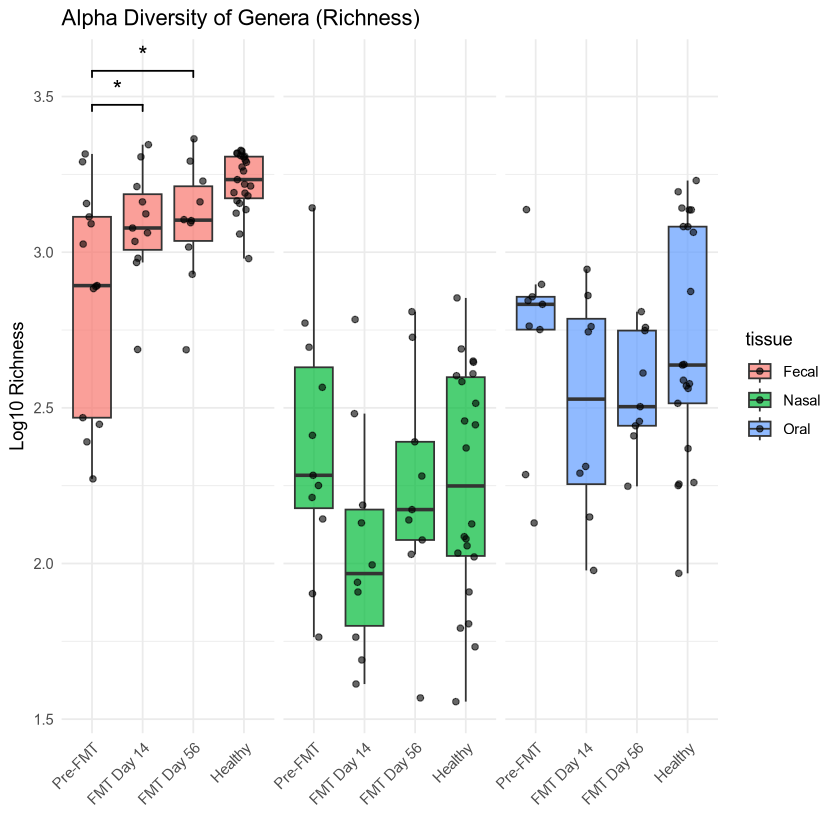

In [162]:
# ---- Log10 richness boxplot with significance brackets from the tissue-stratified LMM ----
ggplot(genera_richness_df, aes(x = condition_day_group, y = log10_richness, fill = tissue)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.6, size = 1.5) +
  geom_signif(
    data = sig_richness,
    aes(xmin = xmin, xmax = xmax, annotations = label, y_position = y_position,
    group = seq_len(nrow(sig_richness))),  # ensure each bracket is treated as a separate group
    manual = TRUE, inherit.aes = FALSE, tip_length = 0.01, textsize = 5
  ) +
  facet_wrap(~ tissue) +
  theme_minimal() +
  labs(
    title = "Alpha Diversity of Genera (Richness)",
    x = " ",
    y = "Log10 Richness"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), strip.text = element_blank())


**What this section adds:**
- Three tissue-stratified richness models (log10 scale, matching the Figure 2 y-axis), Healthy excluded from the model, same structure as the Shannon analysis.
- `richness_group_effect_summary` -- omnibus F-test and ICC for `condition_day_group` per tissue.
- `posthoc_richness_by_tissue` -- Tukey-adjusted pairwise comparisons among Pre-FMT / Day 14 / Day 56, per tissue.



## Effect Size Forest Plot: LMM Fixed Effects (Shannon Diversity & Richness)

Summarizes the fixed-effect estimates (with 95% Wald CIs) from all six tissue-stratified LMMs (3 tissues x 2 outcomes: Shannon diversity, log10 richness) in a single forest plot with an aligned numeric table -- analogous to a meta-analysis forest plot, except each row here is a coefficient from an independently-fit model (not multiple studies estimating the same effect), so there is intentionally no pooled/combined estimate at the bottom.

Row order: timepoint contrasts (Day 14 vs Pre-FMT, Day 56 vs Pre-FMT) are grouped by tissue first (Fecal, then Oral, then Nasal); Sex and Age are grouped by term first (Sex across all three tissues, then Age across all three tissues).


In [163]:
# ---- Helper: pull fixed effects (excl. intercept) + 95% Wald CI + p-value from a tissue LMM ----
extract_fixed_effects <- function(fit, tissue_name, outcome_name) {
  model <- fit$model
  coefs <- summary(model)$coefficients          # Estimate, SE, df, t value, Pr(>|t|) (Satterthwaite, via lmerTest)
  ci    <- suppressMessages(confint(model, method = "Wald", parm = "beta_"))  # Wald CIs, fast + adequate for a forest plot
  terms <- rownames(coefs)

  data.frame(
    outcome   = outcome_name,
    tissue    = tissue_name,
    term      = terms,
    estimate  = coefs[, "Estimate"],
    conf_low  = ci[terms, 1],
    conf_high = ci[terms, 2],
    p_value   = coefs[, "Pr(>|t|)"],
    row.names = NULL
  ) %>%
    filter(term != "(Intercept)")   # drop the intercept -- not an effect of interest for the forest plot
}


In [164]:
# ---- Combine fixed effects across all 6 tissue-stratified models ----
effect_size_df <- bind_rows(
  extract_fixed_effects(fecal_fit,      "Fecal", "Shannon Diversity"),
  extract_fixed_effects(oral_fit,       "Oral",  "Shannon Diversity"),
  extract_fixed_effects(nasal_fit,      "Nasal", "Shannon Diversity"),
  extract_fixed_effects(fecal_rich_fit, "Fecal", "Log10 Richness"),
  extract_fixed_effects(oral_rich_fit,  "Oral",  "Log10 Richness"),
  extract_fixed_effects(nasal_rich_fit, "Nasal", "Log10 Richness")
)

# ---- Clean up term labels for plotting (works regardless of exact factor-level spelling) ----
effect_size_df <- effect_size_df %>%
  mutate(
    term_label = case_when(
      grepl("^condition_day_group", term) ~ paste(sub("^condition_day_group", "", term), "vs Pre-FMT"),
      grepl("^sex", term)                 ~ "Sex",
      term == "age"                       ~ "Age",
      TRUE                                 ~ term
    ),
    tissue     = factor(tissue, levels = c("Fecal", "Oral", "Nasal")),
    sig        = ifelse(p_value < 0.05, "p < 0.05", "n.s.")
  )

effect_size_df


outcome,tissue,term,estimate,conf_low,conf_high,p_value,term_label,sig
<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Shannon Diversity,Fecal,condition_day_groupFMT Day 14,0.572003746,0.173163384,0.970844108,0.01082644,FMT Day 14 vs Pre-FMT,p < 0.05
Shannon Diversity,Fecal,condition_day_groupFMT Day 56,0.451242954,0.040840603,0.861645305,0.04326058,FMT Day 56 vs Pre-FMT,p < 0.05
Shannon Diversity,Fecal,sexmale,-0.015795889,-0.509912877,0.478321100,0.95132628,Sex,n.s.
Shannon Diversity,Fecal,age,0.007498916,-0.009992156,0.024989989,0.41708413,Age,n.s.
Shannon Diversity,Oral,condition_day_groupFMT Day 14,-0.074786527,-0.527635461,0.378062406,0.75078604,FMT Day 14 vs Pre-FMT,n.s.
Shannon Diversity,Oral,condition_day_groupFMT Day 56,0.229490169,-0.217867614,0.676847952,0.33055853,FMT Day 56 vs Pre-FMT,n.s.
Shannon Diversity,Oral,sexmale,-0.248553747,-1.033469564,0.536362071,0.55159553,Sex,n.s.
Shannon Diversity,Oral,age,-0.011000267,-0.036518424,0.014517890,0.41968584,Age,n.s.
Shannon Diversity,Nasal,condition_day_groupFMT Day 14,-0.055616116,-0.628611511,0.517379279,0.85136603,FMT Day 14 vs Pre-FMT,n.s.


In [165]:
# ---- Order rows: timepoint terms grouped by tissue first; Sex/Age keep term-first grouping ----
term_order      <- c("FMT Day 14 vs Pre-FMT", "FMT Day 56 vs Pre-FMT", "Sex", "Age")
tissue_levels   <- c("Fecal", "Oral", "Nasal")
timepoint_terms <- c("FMT Day 14 vs Pre-FMT", "FMT Day 56 vs Pre-FMT")

# Block 1: timepoint rows, tissue-first -> Fecal Day14, Fecal Day56, Oral Day14, Oral Day56, Nasal Day14, Nasal Day56
timepoint_order <- as.vector(sapply(tissue_levels, function(tissue) paste(tissue, timepoint_terms, sep = " \u2013 ")))

# Block 2: Sex/Age rows, term-first (Fecal/Oral/Nasal Sex, then Fecal/Oral/Nasal Age)
sex_age_order <- as.vector(sapply(c("Sex", "Age"), function(term) paste(tissue_levels, term, sep = " \u2013 ")))

row_order <- c(timepoint_order, sex_age_order)

plot_df_by_tissue <- effect_size_df %>%
  mutate(
    term_label = factor(term_label, levels = term_order),
    tissue     = factor(tissue, levels = tissue_levels),
    row_label  = paste(tissue, term_label, sep = " \u2013 "),
    row_label  = factor(row_label, levels = rev(row_order))
  )


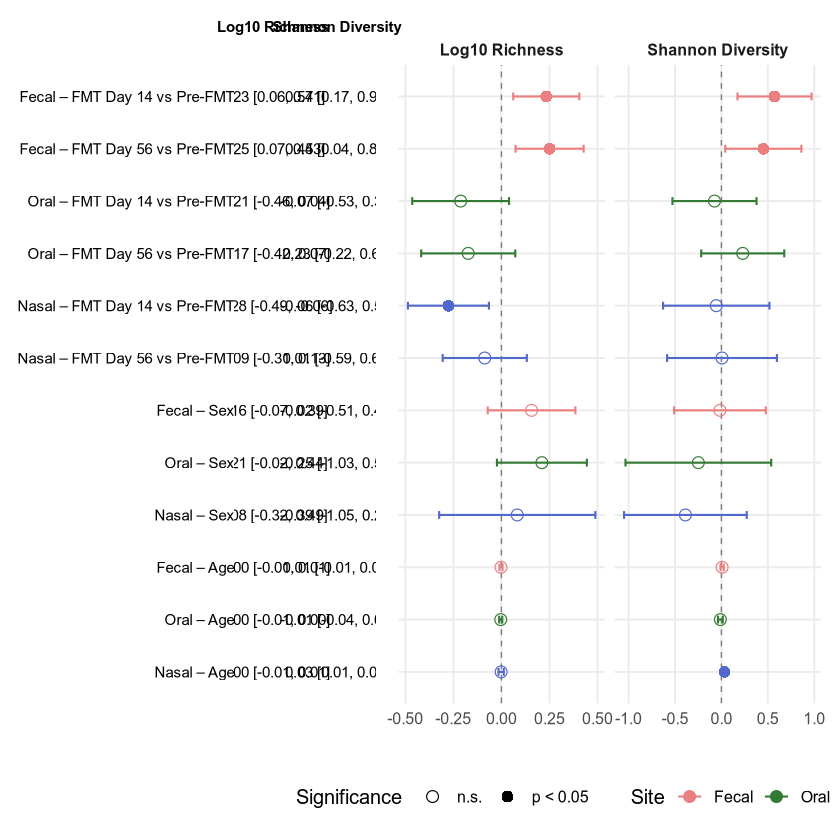

In [166]:
# install.packages("patchwork")  # if not already installed
library(patchwork)

# ---- Build a compact "Estimate [95% CI]" table, in the same row order as the forest plot ----
table_df <- plot_df_by_tissue %>%
  mutate(estimate_ci = sprintf("%.2f [%.2f, %.2f]", estimate, conf_low, conf_high)) %>%
  select(row_label, outcome, estimate_ci) %>%
  tidyr::pivot_wider(names_from = outcome, values_from = estimate_ci)

# Lock in the same top-to-bottom order used by the forest plot (row_order was defined earlier)
table_df$row_label <- factor(table_df$row_label, levels = row_order)

table_long <- table_df %>%
  tidyr::pivot_longer(cols = -row_label, names_to = "column", values_to = "text") %>%
  mutate(
    row_label = factor(row_label, levels = rev(row_order)),  # matches the forest plot's y-axis order
    column    = factor(column, levels = c("Log10 Richness", "Shannon Diversity"))
  )

# ---- Table panel (no axes, just aligned text) ----
table_plot <- ggplot(table_long, aes(x = column, y = row_label, label = text)) +
  geom_text(size = 3.2, hjust = 0.5) +
  scale_x_discrete(position = "top") +
  theme_void() +
  theme(
    axis.text.x = element_text(face = "bold", size = 9),
    axis.text.y = element_text(hjust = 1, size = 9),
    plot.margin = margin(5, 5, 5, 5)
  ) +
  labs(x = NULL, y = NULL)

# ---- Forest plot, with y-axis text removed since the table now carries the row labels ----
forest_plot <- ggplot(plot_df_by_tissue, aes(x = estimate, y = row_label, color = tissue, shape = sig)) +
  geom_vline(xintercept = 0, color = "grey50", linetype = "dashed", linewidth = 0.4) +
  geom_errorbarh(aes(xmin = conf_low, xmax = conf_high), height = 0.15, linewidth = 0.6) +
  geom_point(size = 3) +
  facet_wrap(~ outcome, scales = "free_x") +
  scale_color_manual(values = c("Fecal" = "#eb7e7e", "Oral" = "#337a33", "Nasal" = "#5268ca")) +
  scale_shape_manual(values = c("p < 0.05" = 16, "n.s." = 1)) +
  labs(
    #title = "Fixed-Effect Estimates",
    x = " ", y = NULL,
    color = "Site", shape = "Significance"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid.minor = element_blank(),
    strip.text = element_text(face = "bold"),
    legend.position = "bottom"
  )

# ---- Combine: table on the left, forest plot on the right ----
table_plot + forest_plot + plot_layout(widths = c(1, 3))

ggsave("Figure_LMM_ForestPlot_withTable.png", width = 12, height = 6, dpi = 300)

**Interpretation of the forest plot:**

- **Fecal is the only tissue with confidence intervals excluding zero** for the timepoint contrasts, in both outcomes -- Fecal Day 14 vs Pre-FMT is significant for Shannon diversity and log10 richness, and Fecal Day 56 vs Pre-FMT is significant for richness (the Shannon Day 56 effect trends the same direction but its CI includes zero after Tukey correction, consistent with the earlier post-hoc results).
- **Oral and Nasal timepoint contrasts all have CIs spanning zero** in both outcomes -- no detectable FMT effect on diversity or richness at either site, matching the null omnibus tests reported earlier.
- **Age is significant only for Nasal Shannon diversity** (point estimate clearly off zero, narrow CI relative to the other Age rows); Age is not a significant predictor for any other tissue/outcome combination.
- **Sex shows no significant effect in any tissue or outcome** -- every Sex row's CI comfortably spans zero.
- Taken together, the plot visually reinforces the manuscript's core revised claim: **FMT is associated with a compositional shift in the fecal compartment specifically**, while oral and nasal compartments show no statistical evidence of a treatment effect, and the one notable covariate effect (age) is site-specific (Nasal) rather than a general pattern.


RICHNESS BY SPECIES

In [167]:
# Richness: number of nonzero taxa per sample
richness <- apply(counts_t, 1, function(x) sum(x > 0))
#richness
names(richness) <- sub("^X", "", names(richness))
meta$sample <- trimws(meta$sample)

# Log10 richness
log_richness <- log10(richness)

# Optionally: create a data frame and merge with metadata
richness_df <- data.frame(sample = names(richness), richness = richness, log10_richness = log_richness)
richness_df <- merge(richness_df, meta, by = "sample")

write.table(richness_df, "species_richness.tsv", sep = "\t", row.names = FALSE, quote = FALSE)


In [168]:
# 6. Create a custom grouping: separate FMT by day, collapse Healthy into one group
richness_df <- richness_df %>%
  mutate(condition_day_group = ifelse(condition == "Healthy", "Healthy_AllDays", paste0("FMT_day", day)))


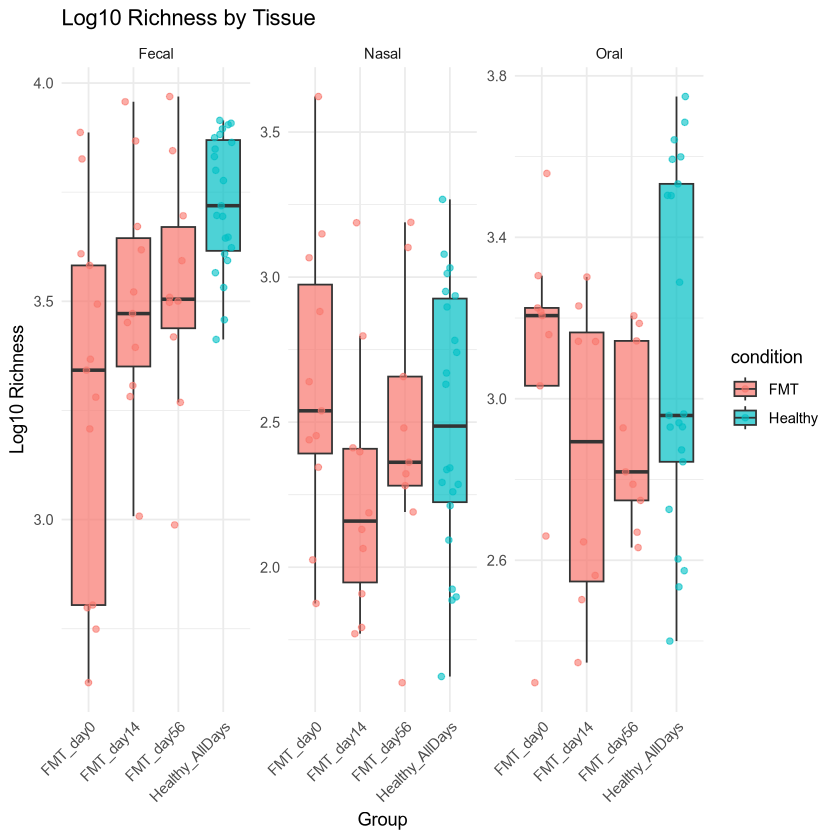

In [169]:
ggplot(richness_df, aes(x = condition_day_group, y = log10_richness, fill = condition)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Hide boxplot outliers to avoid clutter
  geom_jitter(aes(color = condition), width = 0.2, alpha = 0.6, size = 1.5) +  # Add jittered points
  facet_wrap(~ tissue, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "Log10 Richness by Tissue",
    x = "Group",
    y = "Log10 Richness"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


In [170]:
# 6. Create a custom grouping: separate FMT by day, collapse Healthy into one group
richness_df <- richness_df %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    condition == "Healthy"~ "Healthy",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group, 
                                      levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))

# # 7. Plot
# ggplot(diversity_df, aes(x = condition_day_group, y = shannon, fill = condition)) +
#   geom_boxplot() +
#   theme_minimal() +
#   labs(
#     title = "Shannon Diversity: FMT by Day, All Healthy Combined",
#     x = "Group",
#     y = "Shannon Diversity"
#   ) +
#   theme(axis.text.x = element_text(angle = 45, hjust = 1))

DESEQ VOLCANO PLOTS

DDS Counts for Healthy Controls

In [171]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Fecal tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Fecal") #%>%
  #filter(condition == 'FMT')

# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))

counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)

# Run the DESeq2 analysis
dds <- DESeq(dds)



Loading required package: S4Vectors

Loading required package: stats4



Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:Matrix’:

    expand, unname


The following objects are masked from ‘package:lubridate’:

    second, seco

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, an

In [172]:
# ---- Capture Healthy-inclusive genera normalized counts (for reference plotting only) ----
norm_counts_healthy_genera <- counts(dds, normalized = TRUE)
healthy_samples_genera <- rownames(metadata_fecal)[metadata_fecal$timepoint_group == "healthy-control"]


In [173]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Fecal_Healthy_Relative_Abundance_Percentages.csv", row.names = TRUE)

FECAL PRE VS POST

In [174]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Fecal") %>%
  filter(condition == 'FMT')

# # Find the intersection of sample IDs to ensure only matching samples are kept
# common_samples <- intersect(colnames(counts_df), rownames(metadata_oral))

# # Filter both the counts and metadata to include only common samples
# counts_oral <- counts_df[, common_samples]
# metadata_oral <- metadata_oral[common_samples, ]

# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_fecal %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_fecal <- metadata_fecal %>%
  filter(donor %in% paired_donors$donor)

counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~donor + timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]
# write csv
write.csv(res_df, "Fecal_Genera_Volcano.csv", row.names = TRUE)

# # Save the differential abundance results to a CSV file
# write.csv(res_df, "Oral_Corrected_PostFMT_vs_PreFMT_DA_results.csv")

# Calculate the minimum and maximum log2FoldChange to set the x-axis limits
min_x <- min(res_df$log2FoldChange) 
max_x <- max(res_df$log2FoldChange) 

x_limits <- c(min_x, max_x)

max_y <- -log10(min(res_df$pvalue))
#max_y <- round(max_y, 0)

# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Fecal Microbiome: Pre-FMT vs Post-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 5.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL,
  ylim = c(0, max_y)
  #xlim = x_limits
)

# Save the plot as a PNG file
png("Fecal_Corrected_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_409299644 
                   2

In [175]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Convert to data frame for easier manipulation
normalized_counts_df <- as.data.frame(normalized_counts)

# Add metadata information (including original day values) to see timepoints
counts_with_metadata <- t(normalized_counts_df)  # transpose so samples are rows
counts_with_metadata <- as.data.frame(counts_with_metadata)

# Add the original day and timepoint_group columns from metadata
counts_with_metadata$day <- metadata_fecal[rownames(counts_with_metadata), "day"]
counts_with_metadata$timepoint_group <- metadata_fecal[rownames(counts_with_metadata), "timepoint_group"]
counts_with_metadata$donor <- metadata_fecal[rownames(counts_with_metadata), "donor"]

# Save with timepoint info
#write.csv(counts_with_metadata, "Fecal_Normalized_Counts_With_Timepoints.csv", row.names = TRUE)

In [176]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Fecal_Genera_Relative_Abundance_Percentages.csv", row.names = TRUE)

Individual Fecal FMT Genera

In [177]:
# ---- DESeq2-normalized counts for individual Fecal genera (Klebsiella, Shigella) ----
# Reuses `dds` and `res_df` from the "FECAL PRE VS POST" cell above (genera-level,
# FMT-paired design). Do not rerun any cell that rebuilds `dds` before this one.

norm_counts_genera <- counts(dds, normalized = TRUE)

# Recover the original day-level grouping (pre-fmt / day14 / day56) for these same
# samples, rather than the collapsed pre-fmt/post-fmt used in the DESeq2 design itself
sample_days <- metadata_df[colnames(norm_counts_genera), "day"]
day_group <- case_when(
  sample_days == 0  ~ "Pre-FMT",
  sample_days == 14 ~ "FMT Day 14",
  sample_days == 56 ~ "FMT Day 56"
)

norm_counts_long_genera <- norm_counts_genera %>%
  as.data.frame() %>%
  rownames_to_column("taxa") %>%
  pivot_longer(-taxa, names_to = "sample", values_to = "norm_count") %>%
  left_join(
    data.frame(sample = colnames(norm_counts_genera), timepoint_group = day_group),
    by = "sample"
  ) %>%
  mutate(timepoint_group = factor(timepoint_group, levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56")))

write.csv(norm_counts_long_genera, "Fecal_Genera_Normalized_Counts_Long.csv", row.names = FALSE)


*Healthy samples added below as a visual reference only -- not included in any statistical test/padj calculation.*

In [178]:
# ---- Add Healthy samples as a visual reference (4th box) -- NOT part of any
#      statistical test/padj calculation, consistent with how Healthy is treated
#      throughout this analysis ----
norm_counts_healthy_long_genera <- norm_counts_healthy_genera[, healthy_samples_genera, drop = FALSE] %>%
  as.data.frame() %>%
  rownames_to_column("taxa") %>%
  pivot_longer(-taxa, names_to = "sample", values_to = "norm_count") %>%
  mutate(timepoint_group = "Healthy")

norm_counts_long_genera <- bind_rows(norm_counts_long_genera, norm_counts_healthy_long_genera) %>%
  mutate(timepoint_group = factor(timepoint_group, levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))


In [179]:
# ---- Reusable boxplot: DESeq2-normalized counts on the y-axis, with optional significance brackets ----
plot_taxon_boxplot_counts <- function(long_df, taxon_name, title_expr, sig_df = NULL) {
  df <- long_df %>%
    filter(taxa == taxon_name) %>%
    filter(norm_count > 0)

  if (nrow(df) == 0) {
    stop(paste0("Taxon '", taxon_name, "' not found or all-zero. Check exact spelling via: ",
                "grep('", taxon_name, "', unique(long_df$taxa), value = TRUE, ignore.case = TRUE)"))
  }

  # ---- Manual color scale: shades of red for FMT timepoints, gray for Healthy ----
  timepoint_colors <- c(
    "Pre-FMT"     = "#ee0b0b",  # dark red
    "FMT Day 14"  = "#fd5454",  # mid red
    "FMT Day 56"  = "#f78588",  # lightest red
    "Healthy"     = "#148831"   # greenh
  )

  p <- ggplot(df, aes(x = timepoint_group, y = norm_count)) +
    geom_boxplot(outlier.shape = NA, aes(fill = timepoint_group), color = "black", alpha = 0.7, width = 0.5) +
    geom_point(position = position_jitter(width = 0.2, seed = 42), size = 2, color = "black", alpha = 0.8) +
    scale_y_continuous(trans = "log10") +
    scale_fill_manual(values = timepoint_colors) +
    labs(#title = title_expr,
         x = " ", y = " ", fill = "Time Point") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5, face = "bold"),
          axis.title.x = element_text(face = "bold"),
          axis.title.y = element_text(face = "bold"),
          panel.grid.major.x = element_blank(),
          legend.position = "none")

  # ---- Optional: draw significance brackets from a pre-built sig_df (xmin, xmax, label, y_position) ----
  if (!is.null(sig_df) && nrow(sig_df) > 0) {
    p <- p + geom_signif(
      data = sig_df,
      aes(xmin = xmin, xmax = xmax, annotations = label, y_position = y_position,
          group = seq_len(nrow(sig_df))),
      manual = TRUE, inherit.aes = FALSE, tip_length = 0.01, textsize = 5
    )
  }

  p
}


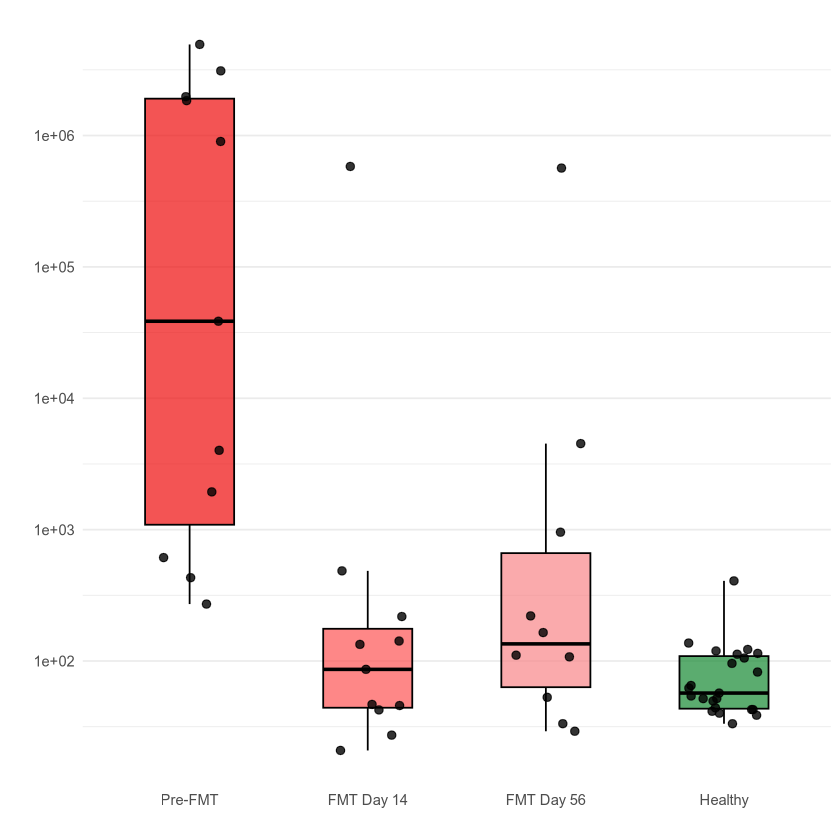

In [180]:
plot_taxon_boxplot_counts(norm_counts_long_genera, "Klebsiella",
  expression(paste("DESeq2-Normalized Counts of ", italic("Klebsiella"))))


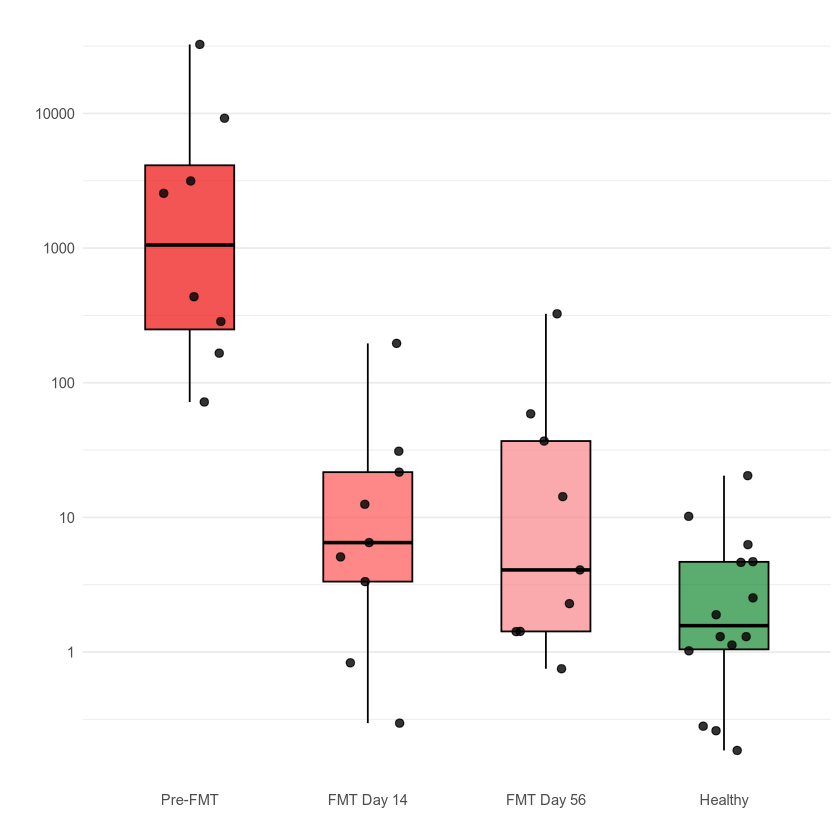

In [181]:
plot_taxon_boxplot_counts(norm_counts_long_genera, "Shigella",
  expression(paste("DESeq2-Normalized Counts of ", italic("Shigella"), " (Fecal)")))


In [184]:
# ---- padj / log2FC values from DESeq2 (numbers only -- not plotted as significance) ----
genera_padj_table <- res_df[c("Klebsiella", "Shigella"), c("log2FoldChange", "padj")]
genera_padj_table


,log2FoldChange,padj
,<dbl>,<dbl>
Klebsiella,-9.066986,8.171098e-24
Shigella,-5.786637,2.169186e-08


**Pairwise DESeq2 Contrasts by Timepoint (Klebsiella, Shigella)**

The `genera_padj_table` above comes from a single pooled contrast (Day 14 + Day 56 collapsed into one "post-fmt" group vs. Pre-FMT), which doesn't distinguish Day 14 from Day 56. This section refits the model with all 3 timepoints kept separate, so the reported p-values line up 1:1 with the three boxes shown in each plot above.

In [185]:
# ---- Refit genera-level DESeq2 with 3 separate timepoints instead of collapsed pre/post ----
metadata_fecal_genera_3lvl <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    day == 0  ~ "pre-fmt",
    day == 14 ~ "day14",
    day == 56 ~ "day56"
  ))
metadata_fecal_genera_3lvl$timepoint_group <- factor(
  metadata_fecal_genera_3lvl$timepoint_group, levels = c("pre-fmt", "day14", "day56"))

dds_genera_3lvl <- DESeqDataSetFromMatrix(countData = counts_fecal,
                                           colData = metadata_fecal_genera_3lvl,
                                           design = ~ donor + timepoint_group)
dds_genera_3lvl <- DESeq(dds_genera_3lvl)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [186]:
# ---- Helper: pull all 3 pairwise timepoint contrasts for one taxon, then BH-adjust
#      across just those 3 comparisons (separate from DESeq2's own across-taxa padj) ----
get_pairwise_deseq_stats <- function(dds_3lvl, taxon_name) {
  pairs <- list(c("day14", "pre-fmt"), c("day56", "pre-fmt"), c("day56", "day14"))

  results_list <- lapply(pairs, function(p) {
    res <- as.data.frame(results(dds_3lvl, contrast = c("timepoint_group", p[1], p[2])))
    data.frame(
      taxon           = taxon_name,
      comparison      = paste(p[1], "vs", p[2]),
      log2FC          = res[taxon_name, "log2FoldChange"],
      pvalue          = res[taxon_name, "pvalue"],
      padj_genomewide = res[taxon_name, "padj"]  # DESeq2's own BH correction, across all taxa, per contrast
    )
  })

  out <- do.call(rbind, results_list)
  # BH-adjust across these 3 timepoint comparisons, specific to this one taxon
  out$padj_timepoint <- p.adjust(out$pvalue, method = "BH")
  out
}


In [187]:
genera_pairwise <- rbind(
  get_pairwise_deseq_stats(dds_genera_3lvl, "Klebsiella"),
  get_pairwise_deseq_stats(dds_genera_3lvl, "Shigella")
)
genera_pairwise


taxon,comparison,log2FC,pvalue,padj_genomewide,padj_timepoint
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Klebsiella,day14 vs pre-fmt,-9.52747892,1.275401e-22,9.144628e-20,3.826204e-22
Klebsiella,day56 vs pre-fmt,-8.73456247,4.669808e-18,4.268205e-15,7.004713e-18
Klebsiella,day56 vs day14,0.79291645,4.323226e-01,1.000000e+00,4.323226e-01
Shigella,day14 vs pre-fmt,-5.75872510,1.371066e-07,2.978953e-06,4.113199e-07
Shigella,day56 vs pre-fmt,-5.80291498,3.251376e-07,1.061342e-05,4.877064e-07
Shigella,day56 vs day14,-0.04418988,9.697004e-01,1.000000e+00,9.697004e-01


**Fecal Genera Boxplots, with manually-placed significance brackets**

Switched from the automated whisker-height calculation to manual bracket placement. These taxa are heavily right-skewed within a single group (e.g. Pre-FMT genuinely contains both very low and very high Klebsiella counts -- that's the real biology, not an outlier to correct for), so no single automatic formula (linear IQR, log-scale IQR, etc.) reliably picks a sensible bracket height. Instead, `add_sig_bracket()` draws a bracket at whatever `y` you specify, directly on top of the already-working plot -- look at the un-annotated boxplot's own y-axis to pick sensible values, then adjust as needed.


In [188]:
# ---- Helper: manually add one significance bracket to an existing ggplot object ----
# xmin/xmax: numeric x-axis positions (1 = pre-fmt, 2 = day14, 3 = day56, 4 = Healthy -- never bracketed)
# y: height of the horizontal bar, in the SAME units as the y-axis (real counts, not log-transformed --
#    ggplot handles the log10 transform automatically since the plot's scale is already log10)
# tip_pct: how far the little vertical ticks drop below the bar, as a fraction of y (not a fixed amount --
#          a fixed additive drop would look wildly different depending on where on the log scale it sits)
add_sig_bracket <- function(p, xmin, xmax, y, label, tip_pct = 0.15, textsize = 5) {
  tip_y <- y * (1 - tip_pct)
  p +
    annotate("segment", x = xmin, xend = xmax, y = y, yend = y, linewidth = 0.5) +
    annotate("segment", x = xmin, xend = xmin, y = y, yend = tip_y, linewidth = 0.5) +
    annotate("segment", x = xmax, xend = xmax, y = y, yend = tip_y, linewidth = 0.5) +
    annotate("text", x = (xmin + xmax) / 2, y = y, label = label, vjust = -0.4, size = textsize)
}


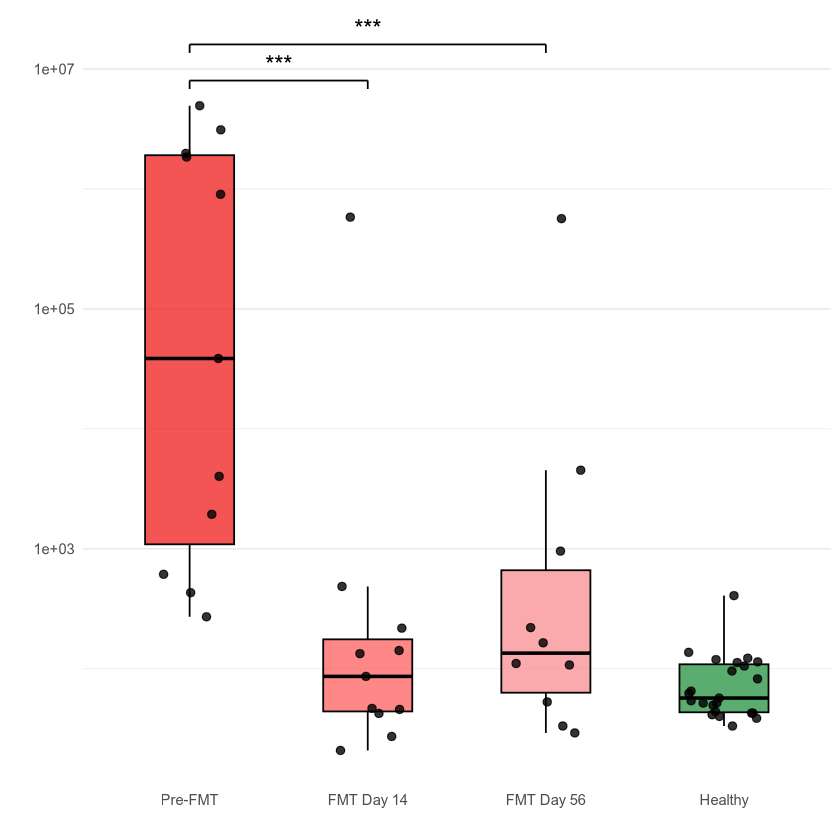

In [189]:
# ---- Klebsiella: build the plot first, then add brackets manually ----
p_kleb <- plot_taxon_boxplot_counts(norm_counts_long_genera, "Klebsiella",
  expression(paste("DESeq2-Normalized Counts of ", italic("Klebsiella"))))

# Check genera_pairwise for which comparisons are actually significant (padj_timepoint < 0.05) before
# committing to these -- and look at p_kleb's own y-axis (print it without brackets first) to pick y-values
p_kleb <- add_sig_bracket(p_kleb, xmin = 1, xmax = 2, y = 8e6,  label = "***")   # Pre-FMT vs Day 14
p_kleb <- add_sig_bracket(p_kleb, xmin = 1, xmax = 3, y = 1.6e7, label = "***")  # Pre-FMT vs Day 56
p_kleb


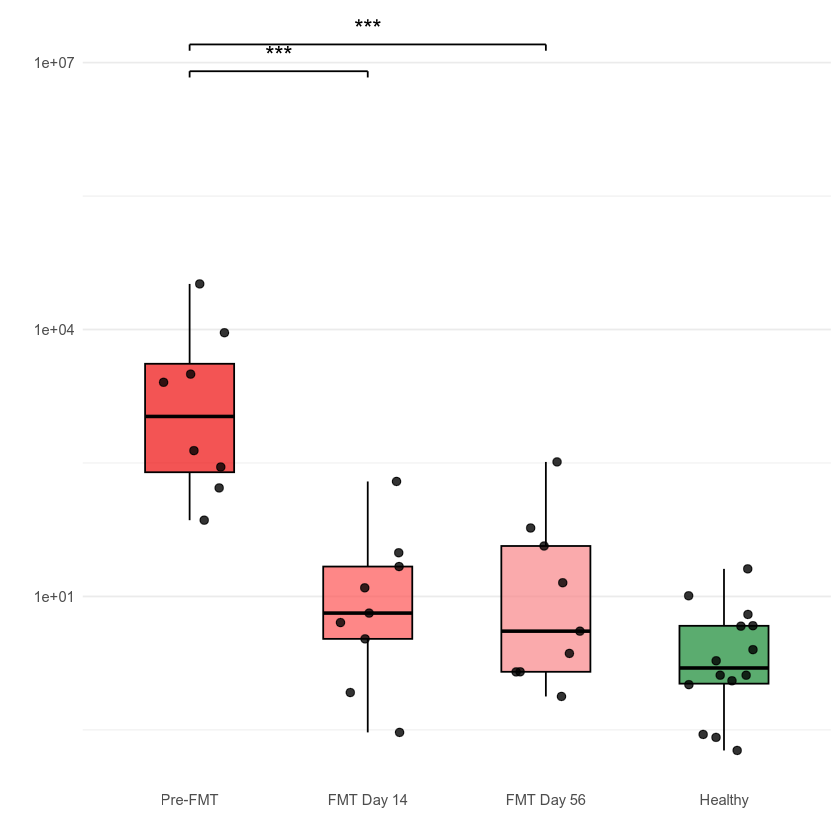

In [190]:
# ---- Shigella: same approach -- adjust xmin/xmax/label/y based on your own results and plot ----
p_shig <- plot_taxon_boxplot_counts(norm_counts_long_genera, "Shigella",
  expression(paste("DESeq2-Normalized Counts of ", italic("Shigella"))))

p_shig <- add_sig_bracket(p_shig, xmin = 1, xmax = 2, y = 8e6,  label = "***")   # Pre-FMT vs Day 14
p_shig <- add_sig_bracket(p_shig, xmin = 1, xmax = 3, y = 1.6e7, label = "***")  # Pre-FMT vs Day 56
p_shig


Fecal Healthy Species DDS Counts

In [191]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Fecal") #%>%
  #filter(condition == 'FMT')


# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))



counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)



# Run the DESeq2 analysis
dds <- DESeq(dds)



[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [192]:
# ---- Capture Healthy-inclusive species normalized counts (for reference plotting only) ----
# `dds` here is the Healthy-inclusive model built just above. Saved under a distinct
# name since `dds` gets overwritten by the FMT-only paired model in the next section.
norm_counts_healthy_species <- counts(dds, normalized = TRUE)
healthy_samples_species <- rownames(metadata_fecal)[metadata_fecal$timepoint_group == "healthy-control"]


In [193]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv 
write.csv(relative_abundance_pct, "Fecal_Healthy_Species_Relative_Abundance.csv", row.names=TRUE)

FECAL SPECIES VOLCANO

In [194]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Fecal") %>%
  filter(condition == 'FMT')

# # Find the intersection of sample IDs to ensure only matching samples are kept
# common_samples <- intersect(colnames(counts_df), rownames(metadata_oral))

# # Filter both the counts and metadata to include only common samples
# counts_oral <- counts_df[, common_samples]
# metadata_oral <- metadata_oral[common_samples, ]

# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_fecal %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_fecal <- metadata_fecal %>%
  filter(donor %in% paired_donors$donor)

counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~donor + timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]

# Save the differential abundance results to a CSV file for plotting
write.csv(res_df, "Fecal_Species_DA_Volcano_Data.csv", row.names = TRUE)

# # Save the differential abundance results to a CSV file
# write.csv(res_df, "Oral_Corrected_PostFMT_vs_PreFMT_DA_results.csv")

# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Fecal Microbiome (Species): Post-FMT vs Pre-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 3.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL
)

# Save the plot as a PNG file
png("Fecal_Species_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_2045997022 
                    2

In [195]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

**Individual Fecal Species (Klebsiella pneumoniae, Veillonella parvula) -- DESeq2-Normalized Counts**

In [196]:
# ---- DESeq2-normalized counts for individual Fecal species ----
# Reuses `dds` and `res_df` from the "FECAL SPECIES VOLCANO" cell above (species-level,
# FMT-paired design). Do not rerun any cell that rebuilds `dds` before this one.

norm_counts_species <- counts(dds, normalized = TRUE)

sample_days_sp <- metadata_df[colnames(norm_counts_species), "day"]
day_group_sp <- case_when(
  sample_days_sp == 0  ~ "Pre-FMT",
  sample_days_sp == 14 ~ "FMT Day 14",
  sample_days_sp == 56 ~ "FMT Day 56"
)

norm_counts_long_species <- norm_counts_species %>%
  as.data.frame() %>%
  rownames_to_column("taxa") %>%
  pivot_longer(-taxa, names_to = "sample", values_to = "norm_count") %>%
  left_join(
    data.frame(sample = colnames(norm_counts_species), timepoint_group = day_group_sp),
    by = "sample"
  ) %>%
  mutate(timepoint_group = factor(timepoint_group, levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56")))

write.csv(norm_counts_long_species, "Fecal_Species_Normalized_Counts_Long.csv", row.names = FALSE)

# Sanity check: confirm the exact taxon name strings exist before plotting
# (species names in the count matrix may use underscores instead of spaces)
grep("pneumoniae", unique(norm_counts_long_species$taxa), value = TRUE, ignore.case = TRUE)
grep("parvula",    unique(norm_counts_long_species$taxa), value = TRUE, ignore.case = TRUE)


[1] "Streptococcus pneumoniae"        "Streptococcus pseudopneumoniae" 
 [3] "Klebsiella pneumoniae"           "Klebsiella quasipneumoniae"     
 [5] "Mesomycoplasma hyopneumoniae"    "Mesomycoplasma ovipneumoniae"   
 [7] "Actinobacillus pleuropneumoniae" "Leclercia pneumoniae"           
 [9] "Chlamydia pneumoniae"            "Mycoplasmoides pneumoniae"

[1] "Blautia parvula"            "Veillonella parvula"       
[3] "Lancefieldella parvula"     "Lacipirellula parvula"     
[5] "Parvularcula bermudensis"   "Parvularcula sp. IMCC14364"
[7] "Parvularcula sp. LCG005"

*Healthy samples added below as a visual reference only -- not included in any statistical test/padj calculation.*

In [197]:
# ---- Add Healthy samples as a visual reference (4th box) -- NOT part of any
#      statistical test/padj calculation, consistent with how Healthy is treated
#      throughout this analysis ----
norm_counts_healthy_long_species <- norm_counts_healthy_species[, healthy_samples_species, drop = FALSE] %>%
  as.data.frame() %>%
  rownames_to_column("taxa") %>%
  pivot_longer(-taxa, names_to = "sample", values_to = "norm_count") %>%
  mutate(timepoint_group = "Healthy")

norm_counts_long_species <- bind_rows(norm_counts_long_species, norm_counts_healthy_long_species) %>%
  mutate(timepoint_group = factor(timepoint_group, levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))


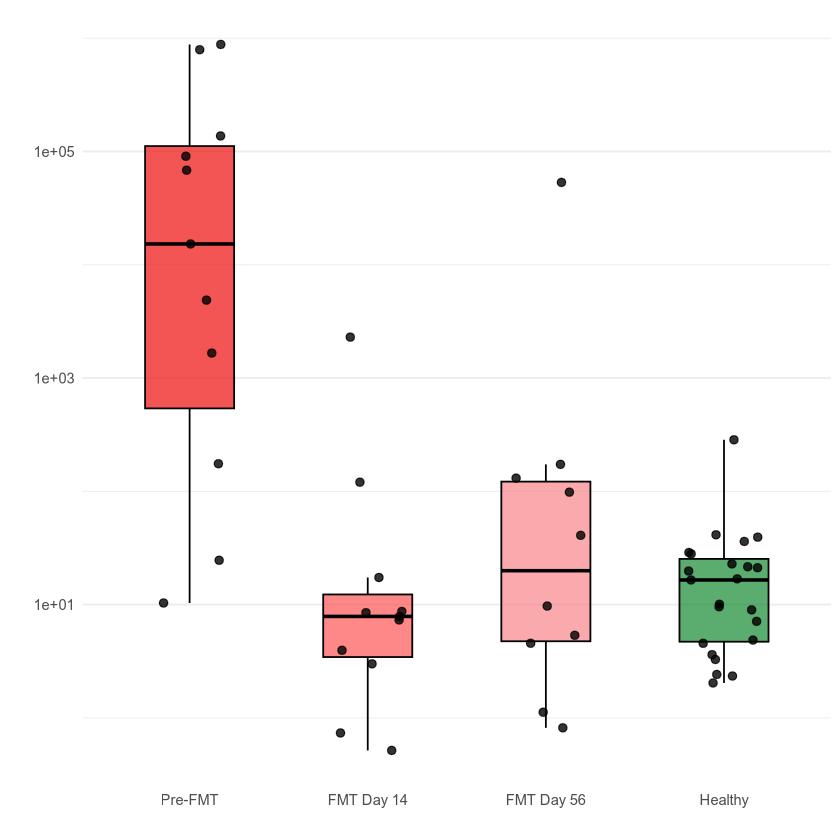

In [198]:
# NOTE: if the sanity-check grep above shows a different exact string
# (e.g. "Klebsiella_pneumoniae" with an underscore), update the taxon_name
# argument below to match exactly.
plot_taxon_boxplot_counts(norm_counts_long_species, "Klebsiella pneumoniae",
  expression(paste("DESeq2-Normalized Counts of ", italic("Klebsiella pneumoniae"))))


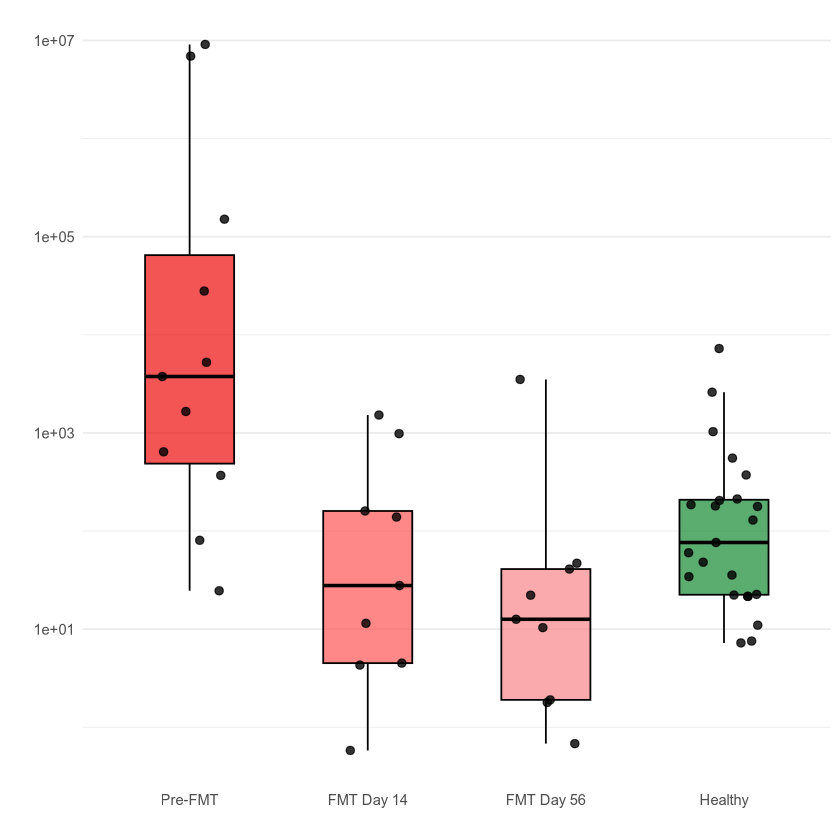

In [199]:
plot_taxon_boxplot_counts(norm_counts_long_species, "Veillonella parvula",
  expression(paste("DESeq2-Normalized Counts of ", italic("Veillonella parvula"), " (Fecal)")))


In [201]:
# ---- padj / log2FC values from DESeq2 (numbers only -- not plotted as significance) ----
species_padj_table <- res_df[c("Klebsiella pneumoniae", "Veillonella parvula"), c("log2FoldChange", "padj")]
species_padj_table


,log2FoldChange,padj
,<dbl>,<dbl>
Klebsiella pneumoniae,-9.063783,1.901072e-19
Veillonella parvula,-11.479408,5.325132e-20


**Pairwise DESeq2 Contrasts by Timepoint (Klebsiella pneumoniae, Veillonella parvula)**

Same fix as the genera section above -- refits with 3 separate timepoints instead of the collapsed pre/post grouping, so p-values line up 1:1 with the three boxes shown in each species plot above.

In [202]:
# ---- Refit species-level DESeq2 with 3 separate timepoints instead of collapsed pre/post ----
metadata_fecal_species_3lvl <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    day == 0  ~ "pre-fmt",
    day == 14 ~ "day14",
    day == 56 ~ "day56"
  ))
metadata_fecal_species_3lvl$timepoint_group <- factor(
  metadata_fecal_species_3lvl$timepoint_group, levels = c("pre-fmt", "day14", "day56"))

# NOTE: `counts_fecal` here must still be the SPECIES-level matrix (the one used to
# build the species volcano plot above) -- do not run this after any cell that
# reassigns counts_fecal back to genera-level data.
dds_species_3lvl <- DESeqDataSetFromMatrix(countData = counts_fecal,
                                            colData = metadata_fecal_species_3lvl,
                                            design = ~ donor + timepoint_group)
dds_species_3lvl <- DESeq(dds_species_3lvl)


converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [203]:
species_pairwise <- rbind(
  get_pairwise_deseq_stats(dds_species_3lvl, "Klebsiella pneumoniae"),
  get_pairwise_deseq_stats(dds_species_3lvl, "Veillonella parvula")
)
species_pairwise


taxon,comparison,log2FC,pvalue,padj_genomewide,padj_timepoint
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Klebsiella pneumoniae,day14 vs pre-fmt,-10.723924,5.808268e-25,3.687669e-21,1.742480e-24
Klebsiella pneumoniae,day56 vs pre-fmt,-8.117648,2.813734e-14,4.805232e-12,4.220600e-14
Klebsiella pneumoniae,day56 vs day14,2.606276,1.587496e-02,1.000000e+00,1.587496e-02
Veillonella parvula,day14 vs pre-fmt,-10.958123,9.210656e-17,1.624402e-14,1.381598e-16
Veillonella parvula,day56 vs pre-fmt,-12.681445,1.937568e-20,1.191217e-16,5.812705e-20
Veillonella parvula,day56 vs day14,-1.723321,2.088394e-01,1.000000e+00,2.088394e-01


**Fecal Species Boxplots, with manually-placed significance brackets**

Same `add_sig_bracket()` helper as the genera boxplots above. Note K. pneumoniae may need a *third* bracket (Day 14 vs Day 56) if your `species_pairwise` table shows a significant partial rebound between those two timepoints, in addition to the two Pre-FMT contrasts -- check the padj_timepoint values before finalizing which brackets to draw.


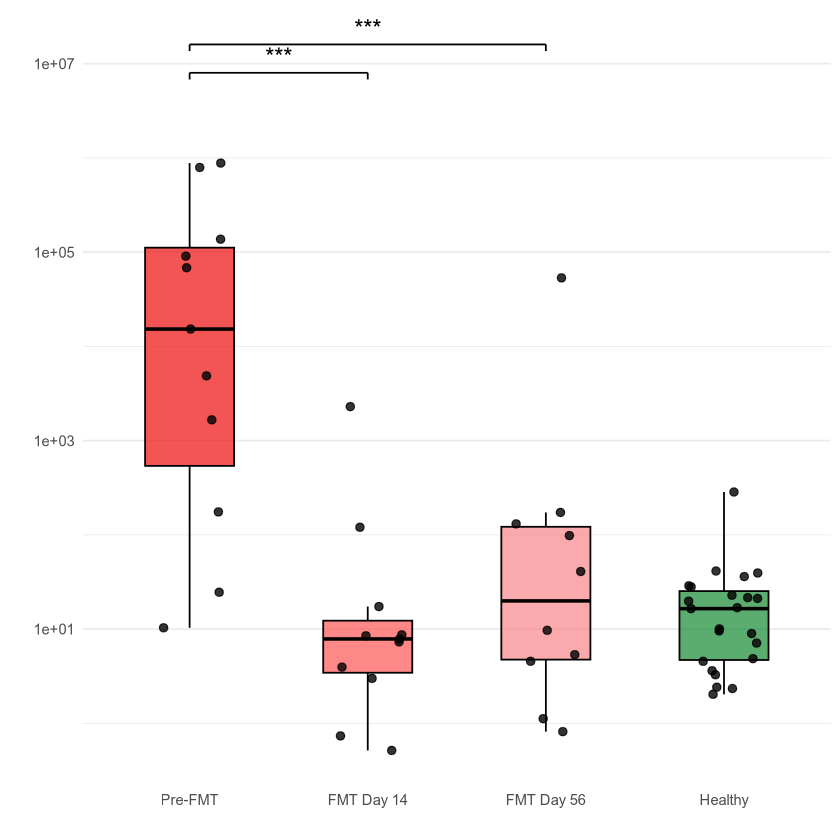

In [204]:
# ---- Klebsiella pneumoniae: check species_pairwise for exact significant comparisons first ----
p_kpn <- plot_taxon_boxplot_counts(norm_counts_long_species, "Klebsiella pneumoniae",
  expression(paste("DESeq2-Normalized Counts of ", italic("Klebsiella pneumoniae"))))

p_kpn <- add_sig_bracket(p_kpn, xmin = 1, xmax = 2, y = 8e6,   label = "***")   # Pre-FMT vs Day 14
p_kpn <- add_sig_bracket(p_kpn, xmin = 1, xmax = 3, y = 1.6e7, label = "***")   # Pre-FMT vs Day 56
# p_kpn <- add_sig_bracket(p_kpn, xmin = 2, xmax = 3, y = 3.2e7, label = "*")  # Day 14 vs Day 56 rebound -- uncomment if significant
p_kpn


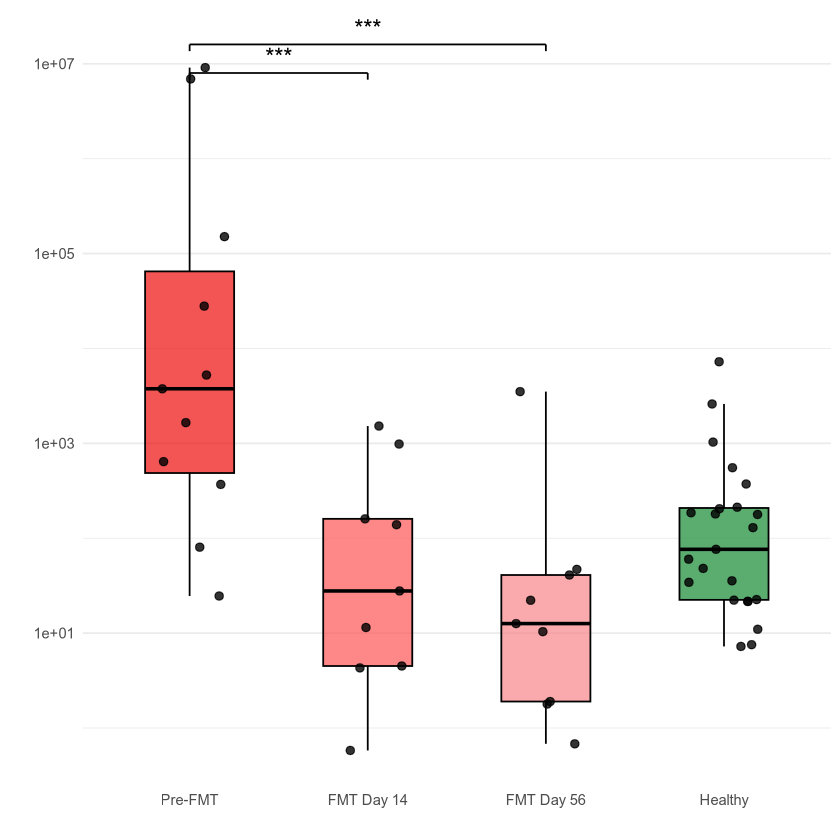

In [205]:
# ---- Veillonella parvula: adjust xmin/xmax/label/y based on your own results and plot ----
p_vp <- plot_taxon_boxplot_counts(norm_counts_long_species, "Veillonella parvula",
  expression(paste("DESeq2-Normalized Counts of ", italic("Veillonella parvula"))))

p_vp <- add_sig_bracket(p_vp, xmin = 1, xmax = 2, y = 8e6,  label = "***")   # Pre-FMT vs Day 14
p_vp <- add_sig_bracket(p_vp, xmin = 1, xmax = 3, y = 1.6e7, label = "***")  # Pre-FMT vs Day 56
p_vp


In [206]:
#write relative abundance to a CSV file
write.csv(relative_abundance_pct, "Fecal_Species_Relative_Abundance.csv", row.names=TRUE)

Healthy DDS counts Nasal

In [ ]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))
metadata_df <- metadata_df[rownames(metadata_df) != "garrett_82", ]


# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Nasal") #%>%
  #filter(condition == 'FMT')



# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))



counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)


# Run the DESeq2 analysis
dds <- DESeq(dds)



[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [ ]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Nasal_Healthy_Genera_Relative_Abundance_Percentages.csv", row.names = TRUE)

Nasal PRE VS POST FMT

In [ ]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)
# remove garrett_82 from metadata_df
metadata_df <- metadata_df[rownames(metadata_df) != "garrett_82", ]

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_nasal <- metadata_df %>%
  filter(tissue == "Nasal") %>%
  filter(condition == 'FMT')


# Create a new column to group time points
metadata_nasal <- metadata_nasal %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_nasal %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_nasal <- metadata_nasal %>%
  filter(donor %in% paired_donors$donor)

counts_nasal <- counts_df[, rownames(metadata_nasal)]

# Remove taxa with zero counts across all samples
counts_nasal <- counts_nasal[rowSums(counts_nasal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_nasal) == colnames(counts_nasal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_nasal,
                              colData = metadata_nasal,
                              design = ~donor + timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]
#write csv
write.csv(res_df, "Nasal_Genera_Volcano.csv", row.names = TRUE)


# # Save the differential abundance results to a CSV file
# write.csv(res_df, "Oral_Corrected_PostFMT_vs_PreFMT_DA_results.csv")
max_y <- -log10(min(res_df$pvalue))
#max_y <- round(max_y, 0)
# Calculate the minimum and maximum log2FoldChange to set the x-axis limits
min_x <- min(res_df$log2FoldChange) 
max_x <- max(res_df$log2FoldChange) 

x_limits <- c(min_x, max_x)
# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Nasal Microbiome: Pre-FMT vs Post-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 5.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL,
  ylim = c(0, max_y )
  #xlim = x_limits
)

# Save the plot as a PNG file
png("Nasal_Corrected_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_2050775282 
                    2

In [ ]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Nasal_Genera_Relative_Abundance_Percentages.csv", row.names = TRUE)

Nasal Species Healthy DDS Counts

In [ ]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))
# exclude garrett_82
metadata_df <- metadata_df[rownames(metadata_df) != "garrett_82", ]
# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Nasal") #%>%
  #filter(condition == 'FMT')

# # Find the intersection of sample IDs to ensure only matching samples are kept
# common_samples <- intersect(colnames(counts_df), rownames(metadata_oral))

# # Filter both the counts and metadata to include only common samples
# counts_oral <- counts_df[, common_samples]
# metadata_oral <- metadata_oral[common_samples, ]

# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))

# # Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
# paired_donors <- metadata_fecal %>%
#   group_by(donor) %>%
#   summarize(unique_groups = n_distinct(timepoint_group)) %>%
#   filter(unique_groups > 1)

# metadata_fecal <- metadata_fecal %>%
#   filter(donor %in% paired_donors$donor)

counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)

# # Set the reference level for the comparison (pre-fmt)
# dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)



[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [ ]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

# write csv
write.csv(relative_abundance_pct, "Nasal_Healthy_Species_Relative_Abundance.csv", row.names = TRUE)

NASAL SPECIES VOLCANO

In [1]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)
# remove garrett_82 from metadata_df
metadata_df <- metadata_df[rownames(metadata_df) != "garrett_82", ]

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_nasal <- metadata_df %>%
  filter(tissue == "Nasal") %>%
  filter(condition == 'FMT')

# # Find the intersection of sample IDs to ensure only matching samples are kept
# common_samples <- intersect(colnames(counts_df), rownames(metadata_oral))

# # Filter both the counts and metadata to include only common samples
# counts_oral <- counts_df[, common_samples]
# metadata_oral <- metadata_oral[common_samples, ]

# Create a new column to group time points
metadata_nasal <- metadata_nasal %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_nasal %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_nasal <- metadata_nasal %>%
  filter(donor %in% paired_donors$donor)

counts_nasal <- counts_df[, rownames(metadata_nasal)]

# Remove taxa with zero counts across all samples
counts_nasal <- counts_nasal[rowSums(counts_nasal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_nasal) == colnames(counts_nasal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_nasal,
                              colData = metadata_nasal,
                              design = ~ donor + timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]
#write csv
write.csv(res_df, "Nasal_Species_DA_Volcano_Data.csv", row.names = TRUE)

# # Save the differential abundance results to a CSV file
# write.csv(res_df, "Oral_Corrected_PostFMT_vs_PreFMT_DA_results.csv")

# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Nasal Microbiome (Species): Post-FMT vs Pre-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 3.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL
)

# Save the plot as a PNG file
png("Nasal_Species_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_527491919 
                   2

In [2]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

# write csv
write.csv(relative_abundance_pct, "Nasal_Species_Relative_Abundance.csv", row.names = TRUE)


Healthy ORAL DDS counts

In [3]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))


# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Oral") #%>%
  #filter(condition == 'FMT')



# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))



counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)



# Run the DESeq2 analysis
dds <- DESeq(dds)



[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [4]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Oral_Healthy_Genera_Relative_Abundance_Percentages.csv", row.names = TRUE)

ORAL PRE VS POST FMT

In [5]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_oral <- metadata_df %>%
  filter(tissue == "Oral") %>%
  filter(condition == 'FMT')


# Create a new column to group time points
metadata_oral <- metadata_oral %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_oral %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_oral <- metadata_oral %>%
  filter(donor %in% paired_donors$donor)

counts_oral <- counts_df[, rownames(metadata_oral)]

# Remove taxa with zero counts across all samples
counts_oral <- counts_oral[rowSums(counts_oral) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_oral) == colnames(counts_oral))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_oral,
                              colData = metadata_oral,
                              design = ~donor+ timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]
#write csv
write.csv(res_df, "Oral_Genera_DA_Volcano_Data.csv", row.names = TRUE)

# Save the differential abundance results to a CSV file
write.csv(res_df, "Oral_Corrected_PostFMT_vs_PreFMT_DA_results.csv")
# Calculate the maximum -log10(p-value) to set the y-axis limit
max_y <- -log10(min(res_df$pvalue))
#max_y <- round(max_y, 0)

# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Oral Microbiome: Pre-FMT vs Post-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 5.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL,
  ylim = c(0, max_y)
)

# Save the plot as a PNG file
png("Oral_Corrected_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_138731825 
                   2

In [6]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

#write csv
write.csv(relative_abundance_pct, "Oral_Genera_Relative_Abundance_Percentages.csv", row.names = TRUE)

Oral Healthy Species DDS Counts

In [7]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))
# exclude garrett_82
# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_fecal <- metadata_df %>%
  filter(tissue == "Oral") #%>%
  #filter(condition == 'FMT')



# Create a new column to group time points
metadata_fecal <- metadata_fecal %>%
  mutate(timepoint_group = case_when(
    condition == 'Healthy' ~ 'healthy-control',
    condition =='FMT' & day == 0 ~ "pre-fmt",
    condition =='FMT' & day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c('healthy-control', "pre-fmt", "post-fmt"))


counts_fecal <- counts_df[, rownames(metadata_fecal)]

# Remove taxa with zero counts across all samples
counts_fecal <- counts_fecal[rowSums(counts_fecal) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_fecal) == colnames(counts_fecal))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_fecal,
                              colData = metadata_fecal,
                              design = ~timepoint_group)



# Run the DESeq2 analysis
dds <- DESeq(dds)



[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

In [8]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)
#vst_counts <- assay(varianceStabilizingTransformation(dds, blind = FALSE, fitType = "local"))

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")
#relative_abundance <- sweep(vst_counts, 2, colSums(vst_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

# write csv
write.csv(relative_abundance_pct, "Oral_Healthy_Species_Relative_Abundance.csv", row.names = TRUE)

Species ORAL PRE VS POST VOLCANO

In [9]:

library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)

# Load the data
counts_df <- read.csv("species_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)

# Clean up sample names to ensure perfect matching
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
rownames(metadata_df) <- trimws(rownames(metadata_df))

# Ensure data is in the correct format for DESeq2
counts_df <- as.matrix(counts_df)

# Filter for Oral tissue and FMT condition
metadata_oral <- metadata_df %>%
  filter(tissue == "Oral") %>%
  filter(condition == 'FMT')



# Create a new column to group time points
metadata_oral <- metadata_oral %>%
  mutate(timepoint_group = case_when(
    day == 0 ~ "pre-fmt",
    day == 14 | day == 56 ~ "post-fmt",
    .default = "other"
  )) %>%
  filter(timepoint_group %in% c("pre-fmt", "post-fmt"))

# Filter to keep only donors who have samples in both pre-fmt and post-fmt groups
paired_donors <- metadata_oral %>%
  group_by(donor) %>%
  summarize(unique_groups = n_distinct(timepoint_group)) %>%
  filter(unique_groups > 1)

metadata_oral <- metadata_oral %>%
  filter(donor %in% paired_donors$donor)

counts_oral <- counts_df[, rownames(metadata_oral)]

# Remove taxa with zero counts across all samples
counts_oral <- counts_oral[rowSums(counts_oral) > 0, ]

# Check that the sample order is the same
all(rownames(metadata_oral) == colnames(counts_oral))

# Create the DESeqDataSet object with the **CORRECTED** paired design
dds <- DESeqDataSetFromMatrix(countData = counts_oral,
                              colData = metadata_oral,
                              design = ~donor + timepoint_group)

# Set the reference level for the comparison (pre-fmt)
dds$timepoint_group <- relevel(as.factor(dds$timepoint_group), ref = "pre-fmt")

# Run the DESeq2 analysis
dds <- DESeq(dds)

# Extract the results for post-fmt vs pre-fmt
res <- results(dds, contrast=c("timepoint_group", "post-fmt", "pre-fmt"))

# Convert results to a data frame and remove rows with missing values
res_df <- as.data.frame(res)
res_df <- res_df[complete.cases(res_df), ]

# Save the differential abundance results to a CSV file
write.csv(res_df, "Oral_Species_Volcano_DA_results.csv")

# Create the volcano plot
p <- EnhancedVolcano(
  res_df,
  lab = rownames(res_df),
  x = 'log2FoldChange',
  y = 'padj',
  title = 'Oral Microbiome (Species): Post-FMT vs Pre-FMT',
  pCutoff = 0.05,
  FCcutoff = 2.0,
  pointSize = 2.0,
  labSize = 3.0,
  legendPosition = 'right',
  caption = 'padj < 0.05, Log2 Fold Change > 2',
  colAlpha = 0.5,
  subtitle = NULL
)

# Save the plot as a PNG file
png("Oral_Species_PostFMT_vs_PreFMT_Volcano_Plot.png", width = 800, height = 600)
print(p)
dev.off()

[1] TRUE

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is reco

agg_record_773037349 
                   2

In [10]:
# Get normalized counts
normalized_counts <- counts(dds, normalized = TRUE)
#vst_counts <- assay(varianceStabilizingTransformation(dds, blind = FALSE, fitType = "local"))

# Calculate relative abundance (proportions that sum to 1 per sample)
relative_abundance <- sweep(normalized_counts, 2, colSums(normalized_counts), FUN = "/")
#relative_abundance <- sweep(vst_counts, 2, colSums(vst_counts), FUN = "/")

# Convert to percentages if you prefer
relative_abundance_pct <- relative_abundance * 100

# write csv
write.csv(relative_abundance_pct, "Oral_Species_Relative_Abundance.csv", row.names = TRUE)


Bray Curtis Distance (Beta Diversity)

In [76]:
# Load count data (rows = taxa, columns = sample IDs)
counts <- read.delim("ali_merged_counts.tsv", row.names = 1, check.names = FALSE)
meta <- read.delim("sample_metadata.tsv", sep = "\t")
meta$sample <- trimws(meta$sample)   # <-- add this


In [77]:
counts_t <- t(counts)  # Transpose the counts matrix
rownames(counts_t) <- sub("^X", "", rownames(counts_t))


In [78]:
library(vegan)

# Bray-Curtis
bray <- vegdist(counts_t, method = "bray")



In [79]:
# PCoA
pcoa_res <- cmdscale(bray, k = 2)
#plot(pcoa_res, main = "PCoA - Bray-Curtis", xlab = "PCoA1", ylab = "PCoA2")

# Optional: Add sample names
#text(pcoa_res, labels = rownames(pcoa_res), pos = 3)



In [80]:
# Extract coordinates
pcoa_df <- as.data.frame(pcoa_res)
colnames(pcoa_df) <- c("PCoA1", "PCoA2")
rownames(pcoa_df) <- sub("^X", "", rownames(pcoa_df))

pcoa_df$sample <- rownames(pcoa_df)

# # Load metadata
# # Load metadata
#meta <- read.delim("sample_metadata.tsv")
pcoa_df <- merge(pcoa_df, meta, by = "sample")


In [81]:
# Assuming you have your distance matrix `bray_dist`

pcoa <- cmdscale(bray, eig = TRUE, k = 2)  # k = number of axes you want

# Eigenvalues
eig_vals <- pcoa$eig

# Calculate proportion of variance explained by positive eigenvalues
pos_eig <- eig_vals[eig_vals > 0]
var_explained <- pos_eig / sum(pos_eig)

# Variance explained for the first two axes (as %)
var_explained_1 <- round(var_explained[1] * 100, 1)
var_explained_2 <- round(var_explained[2] * 100, 1)
var_explained_3 <- round(var_explained[3] * 100, 1)

print(paste0("PCoA1 explains ", var_explained_1, "% of variance"))
print(paste0("PCoA2 explains ", var_explained_2, "% of variance"))
print(paste0("PCoA3 explains ", var_explained_3, "% of variance"))


[1] "PCoA1 explains 15.7% of variance"
[1] "PCoA2 explains 12.2% of variance"
[1] "PCoA3 explains 8.7% of variance"


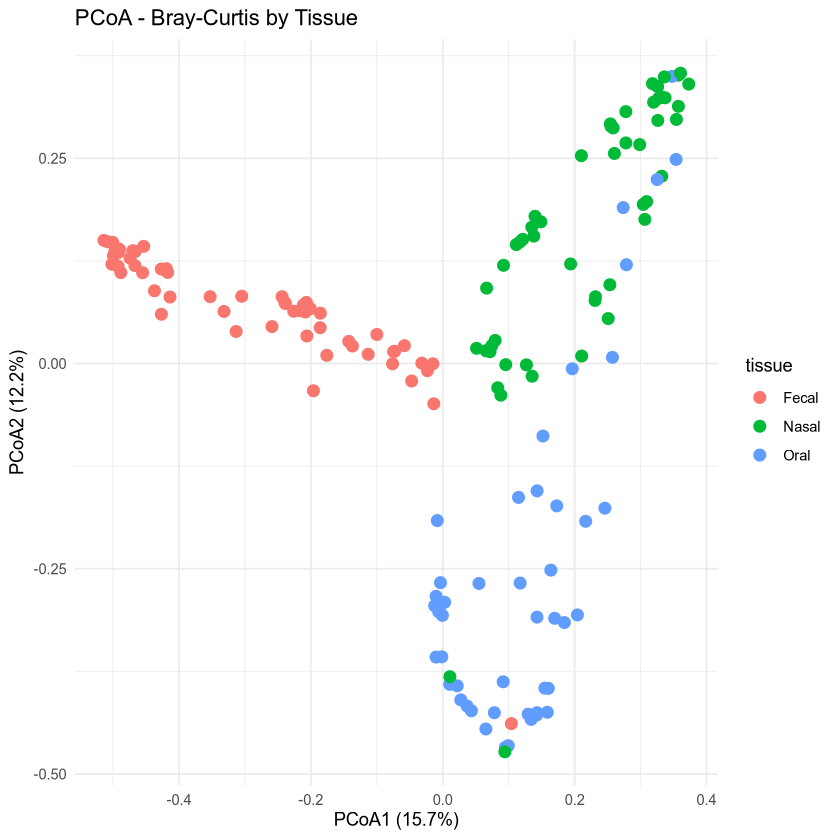

In [82]:
library(ggrepel)
ggplot(pcoa_df, aes(x = PCoA1, y = PCoA2, color = tissue)) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(
    title = "PCoA - Bray-Curtis by Tissue",
    x = paste0("PCoA1 (", var_explained_1, "%)"),
    y = paste0("PCoA2 (", var_explained_2, "%)")
  ) 

## PERMANOVA (Beta Diversity): Tissue-Stratified, Repeated-Measures Aware

Applied to community composition (Bray-Curtis) rather than Shannon diversity: fit **separately per tissue** (Fecal / Oral / Nasal), with `condition_day_group` + `sex` [+ `age`] as fixed-effect-style terms, and `strata = subject_id` to restrict permutations to within-donor -- the PERMANOVA analog of the `(1 | subject_id)` random intercept used in the LMMs. This keeps repeated samples from the same person from being treated as independent, and mirrors the exact tissue-by-tissue structure used above so the two analyses read as one.

**Effect size:** R² from `adonis2` (proportion of Bray-Curtis dissimilarity explained), reported for every term, analogous to the eta-squared-style effect size implied by the LMM F-tests.

**Note on the existing PCoA plot above:** that plot pools all three tissues into one ordination -- useful for showing that tissue is (unsurprisingly) the dominant axis of variation, but it isn't the right basis for testing the FMT effect, since pooling tissues would let that huge between-tissue signal swamp any site-specific treatment effect. So the tests below re-subset the Bray-Curtis distance matrix within each tissue, the same way the LMMs were refit within each tissue, rather than reusing the one combined ordination.

In [83]:
library(vegan)
library(dplyr)

# Align metadata to the samples in the Bray-Curtis matrix and rebuild the same
# condition_day_group / subject_id used in the LMM section above
meta_bray <- meta %>%
  filter(sample %in% rownames(counts_t)) %>%
  filter(condition!="Healthy") %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group,
                                       levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56")))

meta_bray$subject_id <- as.factor(meta_bray$donor)
meta_bray$sex        <- as.factor(meta_bray$sex)

# Same age handling as the LMM section: include age as a covariate if present,
# and listwise-delete missing age so results are directly comparable to the LMMs
has_age_bray <- "age" %in% colnames(meta_bray)
if (has_age_bray) {
  meta_bray$age <- as.numeric(meta_bray$age)
  meta_bray <- meta_bray[!is.na(meta_bray$age), ]
} else {
  message("No 'age' column found -- PERMANOVA models below will exclude age, matching the LMM fallback.")
}


In [84]:
# ---- Helper: fit PERMANOVA within a single tissue, blocked by subject ----
fit_tissue_permanova <- function(tissue_name, dist_mat, meta_df, perm = 999) {

  samples_tissue <- meta_df$sample[meta_df$tissue == tissue_name]
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- as.dist(dist_full[samples_tissue, samples_tissue])

  d <- meta_df[match(samples_tissue, meta_df$sample), ]
  d$condition_day_group <- droplevels(d$condition_day_group)
  d$sex <- droplevels(d$sex)

  cat("====", tissue_name, "====\n")
  cat("N obs:", nrow(d), "| N subjects:", length(unique(d$subject_id)), "\n\n")

  fixed_terms <- c("condition_day_group", "sex")
  if (has_age_bray) fixed_terms <- c(fixed_terms, "age")
  f <- as.formula(paste("dist_sub ~", paste(fixed_terms, collapse = " + ")))

  # by = "margin" -> marginal (Type III-style) R2/F/p for each term, so terms
  # can be compared to the Satterthwaite Type III ANOVA used in the LMMs
  res <- adonis2(f, data = d, permutations = perm, by = "margin", strata = d$subject_id)

  list(result = res, data = d)
}


In [85]:
# ---- Fecal ----
fecal_permanova <- fit_tissue_permanova("Fecal", dist_mat = bray, meta_df = meta_bray)
fecal_permanova$result


==== Fecal ====
N obs: 34 | N subjects: 13 



,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
condition_day_group,2,1.1565601,0.09444207,1.718545,0.001
sex,1,0.8746102,0.07141868,2.599185,0.021
age,1,0.3788629,0.03093709,1.125913,0.799
Residual,29,9.7583270,0.79684284,NA,NA
Total,33,12.2462379,1.00000000,NA,NA


In [86]:
# ---- Oral ----
oral_permanova <- fit_tissue_permanova("Oral", dist_mat = bray, meta_df = meta_bray)
oral_permanova$result


==== Oral ====
N obs: 26 | N subjects: 11 



,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
condition_day_group,2,0.5026130,0.06007242,0.7601704,0.609
sex,1,0.5420112,0.06478129,1.6395151,0.740
age,1,0.2903112,0.03469805,0.8781545,0.178
Residual,21,6.9424395,0.82976183,NA,NA
Total,25,8.3667858,1.00000000,NA,NA


In [87]:
# ---- Nasal ----
nasal_permanova <- fit_tissue_permanova("Nasal", dist_mat = bray, meta_df = meta_bray)
nasal_permanova$result


==== Nasal ====
N obs: 30 | N subjects: 12 



,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
condition_day_group,2,0.5717399,0.05166059,0.7715841,0.578
sex,1,0.5982328,0.05405440,1.6146744,0.238
age,1,0.5652560,0.05107473,1.5256678,0.226
Residual,25,9.2624363,0.83692410,NA,NA
Total,29,11.0672357,1.00000000,NA,NA


In [88]:
# ---- Omnibus condition_day_group effect, side-by-side across tissues ----
extract_permanova_effect <- function(fit, tissue_name) {
  res <- fit$result
  data.frame(
    tissue     = tissue_name,
    n_obs      = nrow(fit$data),
    n_subjects = length(unique(fit$data$subject_id)),
    R2         = round(res["condition_day_group", "R2"], 3),  # effect size
    F          = round(res["condition_day_group", "F"], 3),
    p_value    = res["condition_day_group", "Pr(>F)"]
  )
}

permanova_group_effect_summary <- rbind(
  extract_permanova_effect(fecal_permanova, "Fecal"),
  extract_permanova_effect(oral_permanova,  "Oral"),
  extract_permanova_effect(nasal_permanova, "Nasal")
)

# BH-adjust across the three tissue-level omnibus tests
permanova_group_effect_summary$p_adj <- p.adjust(permanova_group_effect_summary$p_value, method = "BH")
permanova_group_effect_summary


tissue,n_obs,n_subjects,R2,F,p_value,p_adj
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Fecal,34,13,0.094,1.719,0.001,0.003
Oral,26,11,0.060,0.760,0.609,0.609
Nasal,30,12,0.052,0.772,0.578,0.609


**Post-Hoc Pairwise PERMANOVA by Tissue**

Same idea as the Tukey-adjusted `emmeans` contrasts for the LMMs: for each tissue, every pair of `condition_day_group` levels is compared directly (Bray-Curtis, `strata = subject_id`), with p-values BH-adjusted **within each tissue** for the multiple pairwise comparisons performed there.

In [89]:
# ---- Pairwise PERMANOVA comparisons across group/timepoint, within each tissue ----
pairwise_tissue_permanova <- function(fit, tissue_name, dist_mat, perm = 999) {

  d <- fit$data
  dist_full <- as.matrix(dist_mat)
  group_levels <- levels(d$condition_day_group)
  pairs <- combn(group_levels, 2, simplify = FALSE)

  pair_results <- lapply(pairs, function(pair) {
    keep <- d$condition_day_group %in% pair
    samp_keep <- d$sample[keep]
    dist_pair <- as.dist(dist_full[samp_keep, samp_keep])

    d_pair <- d[keep, ]
    d_pair$condition_day_group <- droplevels(d_pair$condition_day_group)
    # Same fix as the omnibus function -- drop unused subject_id levels so
    # donors absent from this specific pair don't leave an empty stratum behind
    d_pair$subject_id <- droplevels(d_pair$subject_id)

    res <- adonis2(
      dist_pair ~ condition_day_group,
      data = d_pair,
      permutations = perm,
      strata = d_pair$subject_id
    )

    data.frame(
      tissue     = tissue_name,
      comparison = paste(pair, collapse = " vs "),
      R2         = round(res$R2[1], 3),
      F          = round(res$F[1], 3),
      p_value    = res$`Pr(>F)`[1]
    )
  })

  do.call(rbind, pair_results)
}

permanova_posthoc_by_tissue <- rbind(
  pairwise_tissue_permanova(fecal_permanova, "Fecal", bray),
  pairwise_tissue_permanova(oral_permanova,  "Oral",  bray),
  pairwise_tissue_permanova(nasal_permanova, "Nasal", bray)
)

# BH-adjust within each tissue (multiple pairwise comparisons per tissue)
permanova_posthoc_by_tissue <- permanova_posthoc_by_tissue %>%
  group_by(tissue) %>%
  mutate(p_adj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  arrange(tissue, p_value)

permanova_posthoc_by_tissue


Set of permutations < 'minperm'. Generating entire set.

Set of permutations < 'minperm'. Generating entire set.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.



tissue,comparison,R2,F,p_value,p_adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Fecal,Pre-FMT vs FMT Day 14,0.092,2.218,0.0010000,0.0030000
Fecal,Pre-FMT vs FMT Day 56,0.085,1.952,0.0030000,0.0045000
Fecal,FMT Day 14 vs FMT Day 56,0.025,0.484,0.6190000,0.6190000
Nasal,Pre-FMT vs FMT Day 14,0.046,0.915,0.3906250,0.7773438
Nasal,FMT Day 14 vs FMT Day 56,0.030,0.524,0.6601562,0.7773438
Nasal,Pre-FMT vs FMT Day 56,0.030,0.558,0.7773438,0.7773438
Oral,Pre-FMT vs FMT Day 56,0.063,1.067,0.2343750,0.6875000
Oral,Pre-FMT vs FMT Day 14,0.038,0.600,0.6484375,0.6875000
Oral,FMT Day 14 vs FMT Day 56,0.028,0.431,0.6875000,0.6875000


**Within-Tissue PCoA Plots (companion to the tissue-stratified PERMANOVA)**

These re-ordinate the Bray-Curtis distances *separately per tissue* (rather than reusing the single pooled PCoA above), so each panel's axes reflect within-tissue compositional structure and can be read directly alongside that tissue's PERMANOVA result.

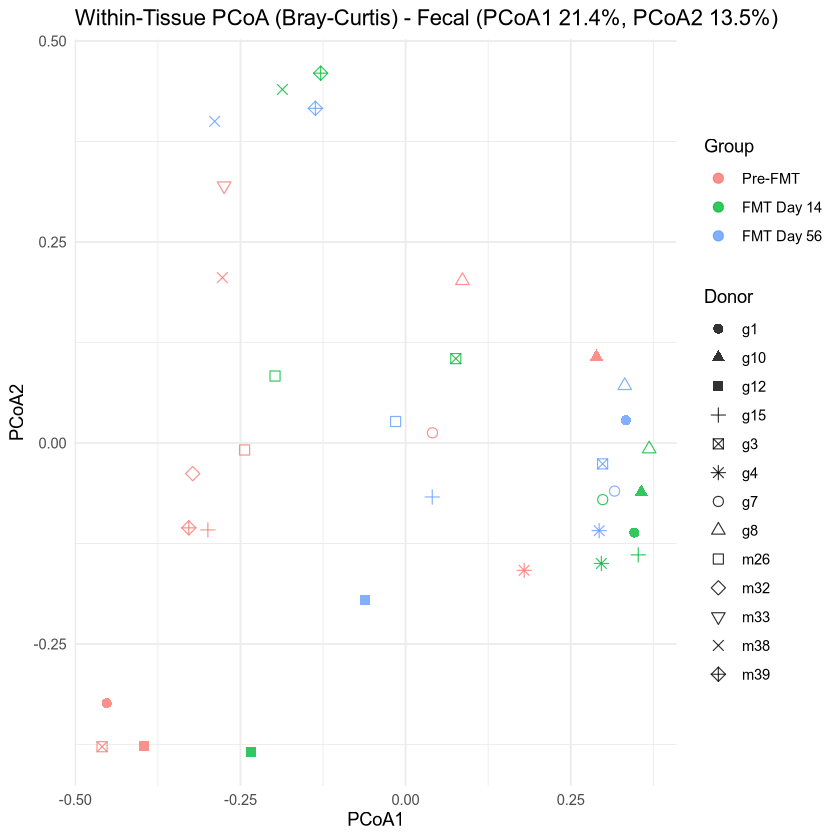

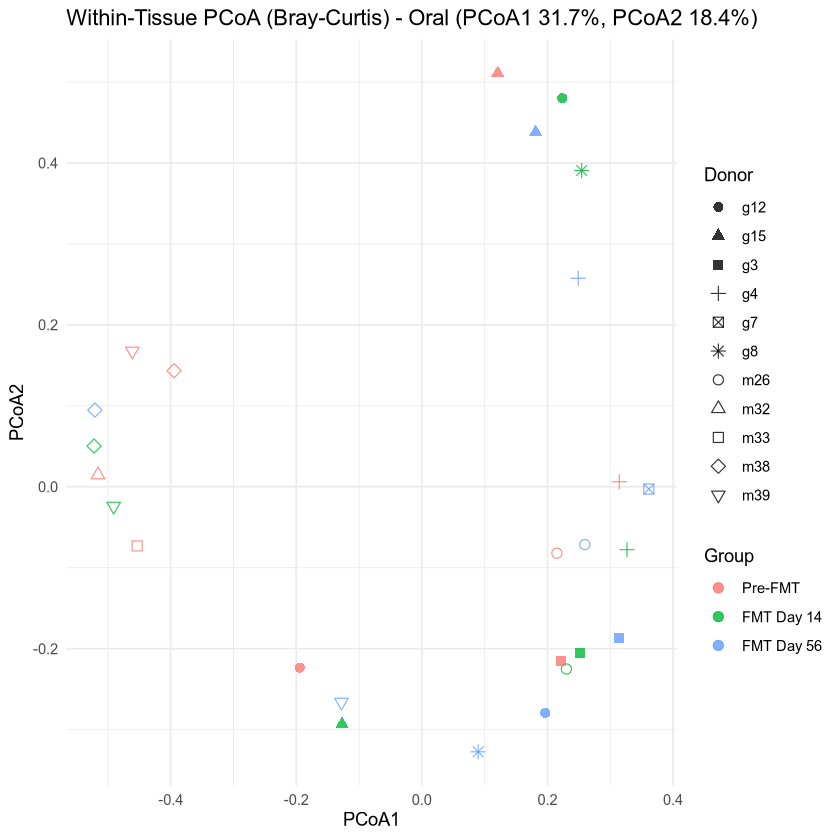

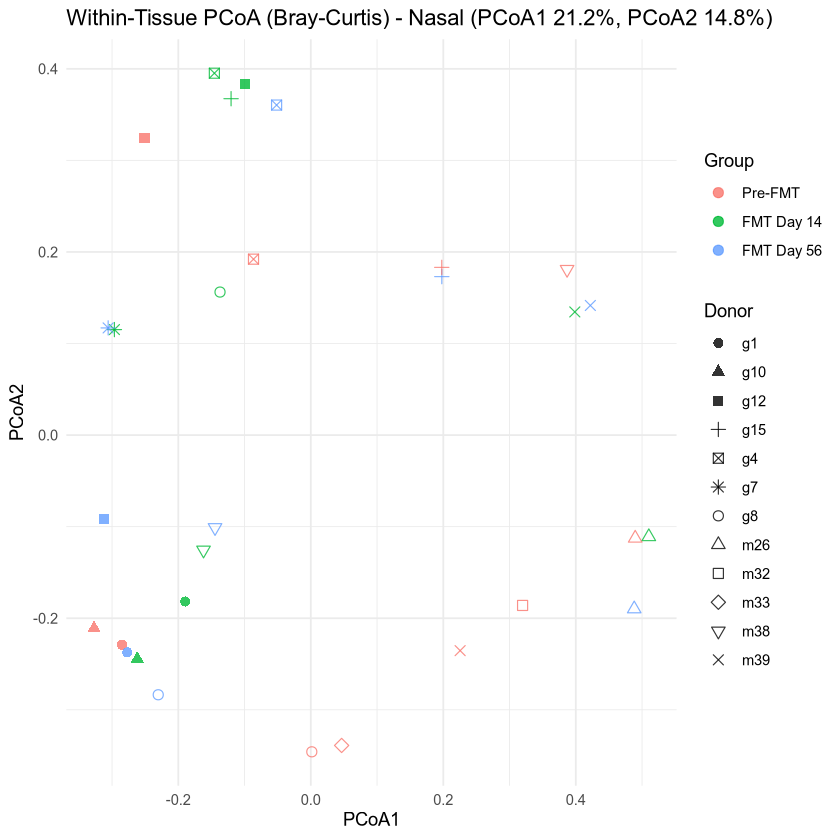

In [90]:
# ---- PCoA computed separately within each tissue (not the pooled one above) ----
tissue_pcoa <- function(tissue_name, dist_mat, meta_df) {
  samples_tissue <- meta_df$sample[meta_df$tissue == tissue_name]
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- as.dist(dist_full[samples_tissue, samples_tissue])

  ord <- cmdscale(dist_sub, eig = TRUE, k = 2)
  pos_eig <- ord$eig[ord$eig > 0]
  var_exp <- round(pos_eig / sum(pos_eig) * 100, 1)

  df <- as.data.frame(ord$points)
  colnames(df) <- c("PCoA1", "PCoA2")
  df$sample <- samples_tissue
  df <- merge(df, meta_df, by = "sample")
  df$tissue_facet <- paste0(tissue_name, " (PCoA1 ", var_exp[1], "%, PCoA2 ", var_exp[2], "%)")
  df
}

# Build one ggplot per tissue and print each separately (instead of faceting)
plot_tissue_pcoa <- function(tissue_name, dist_mat, meta_df) {
  df <- tissue_pcoa(tissue_name, dist_mat, meta_df)

  n_donors <- length(unique(df$donor))

  # ---- Shape palette: pool of up to 25 distinguishable point shapes (pch 0-25 in R) ----
  # Mix of open/filled/different forms so shapes stay visually distinct even as count grows
  shape_pool <- c(16, 17, 15, 3, 7, 8, 1, 2, 0, 5, 6, 4, 9, 10, 11, 12, 13, 14, 18, 21, 22, 23, 24, 25)

  if (n_donors > length(shape_pool)) {
    stop(paste0("Only ", length(shape_pool), " distinguishable shapes available, but ",
                n_donors, " donors present. Consider faceting by donor group or ",
                "using color+shape combinations instead of shape alone."))
  }

  ggplot(df, aes(x = PCoA1, y = PCoA2, color = condition_day_group, shape = donor)) +
    geom_point(size = 2.5, alpha = 0.8) +
    scale_shape_manual(values = shape_pool[1:n_donors]) +
    theme_minimal() +
    labs(
      title = paste0("Within-Tissue PCoA (Bray-Curtis) - ", unique(df$tissue_facet)),
      x = "PCoA1", y = "PCoA2", color = "Group", shape = "Donor"
    )
}

fecal_pcoa_plot <- plot_tissue_pcoa("Fecal", bray, meta_bray)
oral_pcoa_plot  <- plot_tissue_pcoa("Oral",  bray, meta_bray)
nasal_pcoa_plot <- plot_tissue_pcoa("Nasal", bray, meta_bray)

fecal_pcoa_plot
oral_pcoa_plot
nasal_pcoa_plot

**Summary of what this section adds:**
- Three independent PERMANOVA models (Fecal, Oral, Nasal), each testing `condition_day_group` with `sex` [+ `age`] as covariates -- the same fixed-effect structure as the tissue-stratified LMMs -- so alpha diversity (univariate) and community composition (multivariate) are evaluated with parallel models.
- `strata = subject_id` restricts permutations to within-donor, the PERMANOVA equivalent of the `(1 | subject_id)` random intercept.
- R² effect sizes for every omnibus and pairwise test (`permanova_group_effect_summary`, `permanova_posthoc_by_tissue`), with BH-adjusted p-values in both.
- Within-tissue PCoA plots as a visual companion to each tissue's PERMANOVA result, distinct from the single pooled PCoA above (which mainly demonstrates that tissue itself is the dominant source of variation).

## Additional Beta-Diversity Visuals

Four companion visuals to the PERMANOVA results above: subject-trajectory PCoA plots, a distance-to-centroid (dispersion) check, a forest plot of PERMANOVA effect sizes, and pairwise Bray-Curtis distance boxplots. None of these change or re-fit any model above -- they all reuse `bray`, `meta_bray`, and the fitted `*_permanova` objects as-is.

One shared setup step first: a **visualization-only**, Healthy-inclusive version of the metadata (`meta_bray_viz`). The PERMANOVA models themselves correctly exclude Healthy (it was never part of the FMT design or the repeated-measures structure), but showing Healthy as a visual reference point is useful here, matching the convention used in the LMM boxplots above.


In [91]:
# ---- Visualization-only metadata: same construction as meta_bray, but keeps Healthy for reference ----
meta_bray_viz <- meta %>%
  filter(sample %in% rownames(as.matrix(bray))) %>%
  mutate(condition_day_group = case_when(
    condition == "FMT" & day == 0 ~ "Pre-FMT",
    condition == "Healthy" ~ "Healthy",
    TRUE ~ paste0("FMT Day ", day))) %>%
  mutate(condition_day_group = factor(condition_day_group,
                                       levels = c("Pre-FMT", "FMT Day 14", "FMT Day 56", "Healthy")))

meta_bray_viz$subject_id <- as.factor(meta_bray_viz$donor)
meta_bray_viz$sex        <- as.factor(meta_bray_viz$sex)


### 1. Subject-Trajectory PCoA ("Spaghetti") Plots

PCoA axes are fit on the **FMT-only** distance matrix (identical to `tissue_pcoa()`/the within-tissue PCoA above -- same samples, same axes, same % variance explained). Healthy samples are then **projected onto those fixed axes** as supplementary points, using Gower's classical out-of-sample MDS formula, rather than being included in a separate ordination fit on a different sample set. This keeps Healthy purely as a visual reference without letting it change where the axes are drawn or how much variance each one explains -- so this plot's Fecal/Oral/Nasal panels now line up exactly with the within-tissue PCoA plots earlier (same coordinates for every FMT sample), with Healthy added on top.


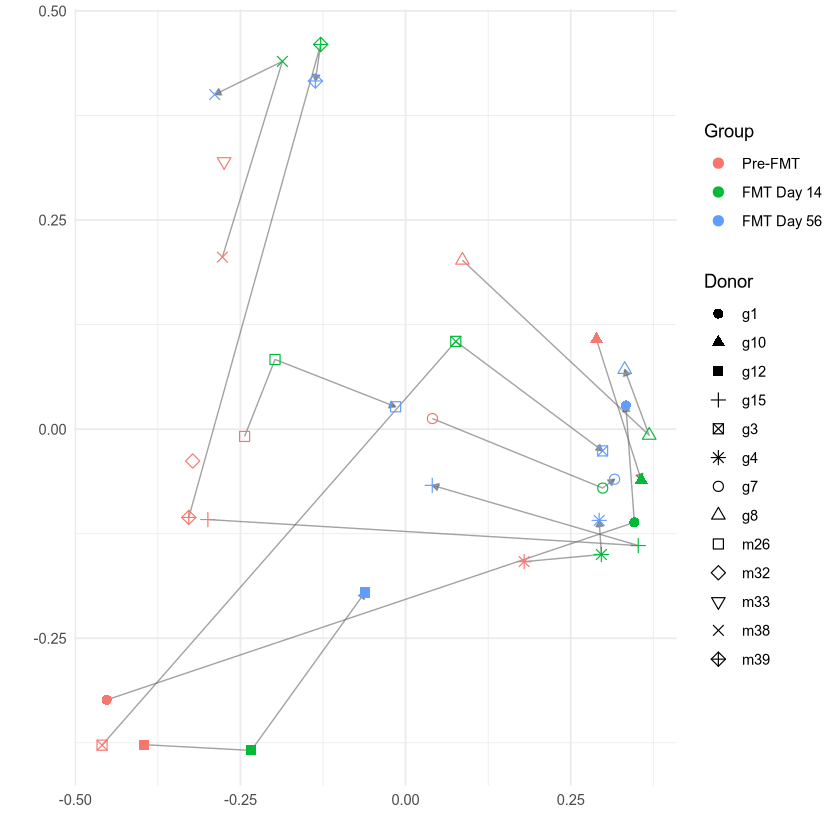

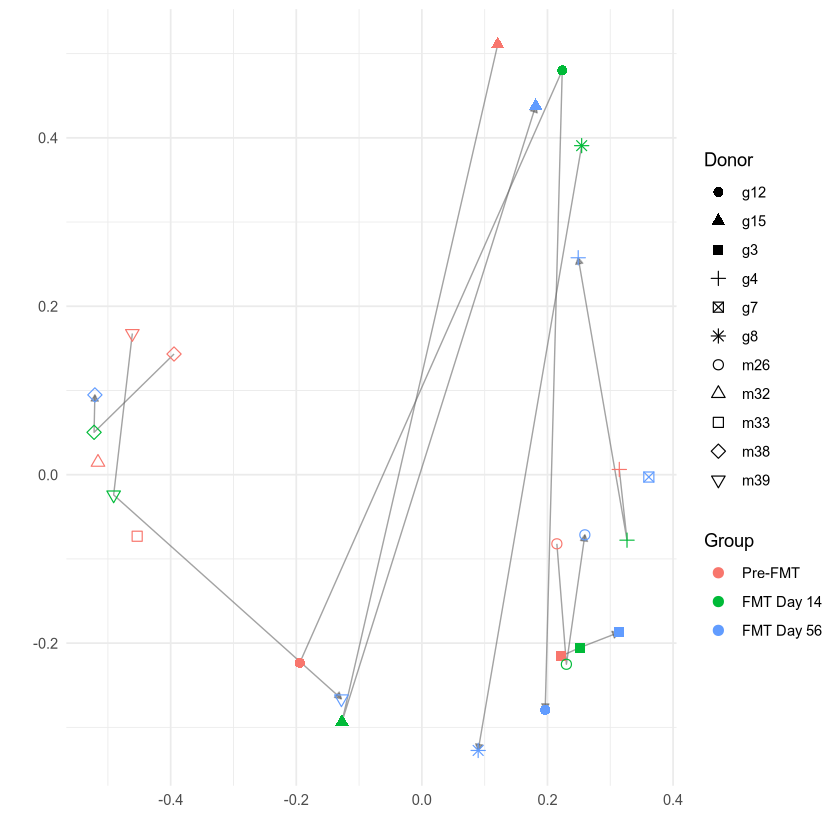

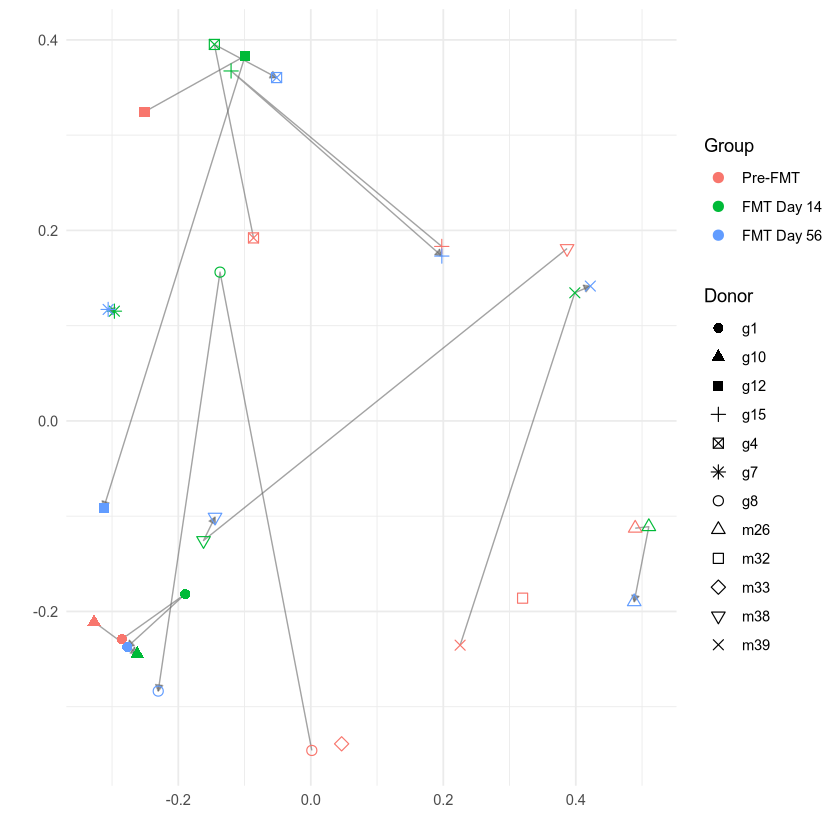

In [208]:
# ---- PCoA fit on FMT-only samples (identical to tissue_pcoa() above) ----
tissue_pcoa_fmt_only <- function(tissue_name, dist_mat, meta_df) {
  samples_tissue <- meta_df$sample[meta_df$tissue == tissue_name]
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- as.dist(dist_full[samples_tissue, samples_tissue])

  ord <- cmdscale(dist_sub, eig = TRUE, k = 2)
  pos_eig <- ord$eig[ord$eig > 0]
  var_exp <- round(pos_eig / sum(pos_eig) * 100, 1)

  df <- as.data.frame(ord$points)
  colnames(df) <- c("PCoA1", "PCoA2")
  df$sample <- samples_tissue
  df <- merge(df, meta_df, by = "sample")
  df$tissue_facet <- paste0(tissue_name, " (PCoA1 ", var_exp[1], "%, PCoA2 ", var_exp[2], "%)")

  df
}

# ---- Shared shape palette (reused across all PCoA-style plots) ----
shape_pool <- c(16, 17, 15, 3, 7, 8, 1, 2, 0, 5, 6, 4, 9, 10, 11, 12, 13, 14, 18, 21, 22, 23, 24, 25)

# ---- Connects each FMT subject's timepoints with an arrowed path -- no Healthy reference ----
plot_subject_trajectory <- function(tissue_name, dist_mat, meta_fmt) {
  df <- tissue_pcoa_fmt_only(tissue_name, dist_mat, meta_fmt) %>%
    arrange(subject_id, condition_day_group)
    
  n_donors <- length(unique(df$donor))
  if (n_donors > length(shape_pool)) {
    stop(paste0("Only ", length(shape_pool), " distinguishable shapes available, but ",
                n_donors, " donors present. Consider faceting by donor group instead."))
  }

  ggplot(df, aes(x = PCoA1, y = PCoA2)) +
    geom_path(aes(group = subject_id),
              color = "grey40", linewidth = 0.4, alpha = 0.6,
              arrow = arrow(length = unit(0.15, "cm"), type = "closed")) +
    geom_point(aes(color = condition_day_group, shape = donor), size = 2.5) +
    scale_shape_manual(values = shape_pool[1:n_donors]) +
    theme_minimal() +
    labs(
      #title = paste0("Subject Trajectories (Bray-Curtis PCoA) - ", unique(df$tissue_facet)),
      x = " ", y = " ", color = "Group", shape= "Donor"
    )
}

fecal_trajectory_plot <- plot_subject_trajectory("Fecal", bray, meta_bray)
oral_trajectory_plot  <- plot_subject_trajectory("Oral",  bray, meta_bray)
nasal_trajectory_plot <- plot_subject_trajectory("Nasal", bray, meta_bray)

fecal_trajectory_plot
oral_trajectory_plot
nasal_trajectory_plot


### 1. Subject-Trajectory PCoA ("Spaghetti") Plots

Re-uses the within-tissue PCoA ordination approach from `tissue_pcoa()` above, but keeps Healthy (plotted as static grey reference points, no trajectory) and connects each subject's own Pre-FMT → Day 14 → Day 56 points with an arrowed path -- a visual complement to the subject-blocked PERMANOVA, since it's the same within-donor structure the `strata = subject_id` term is accounting for statistically.


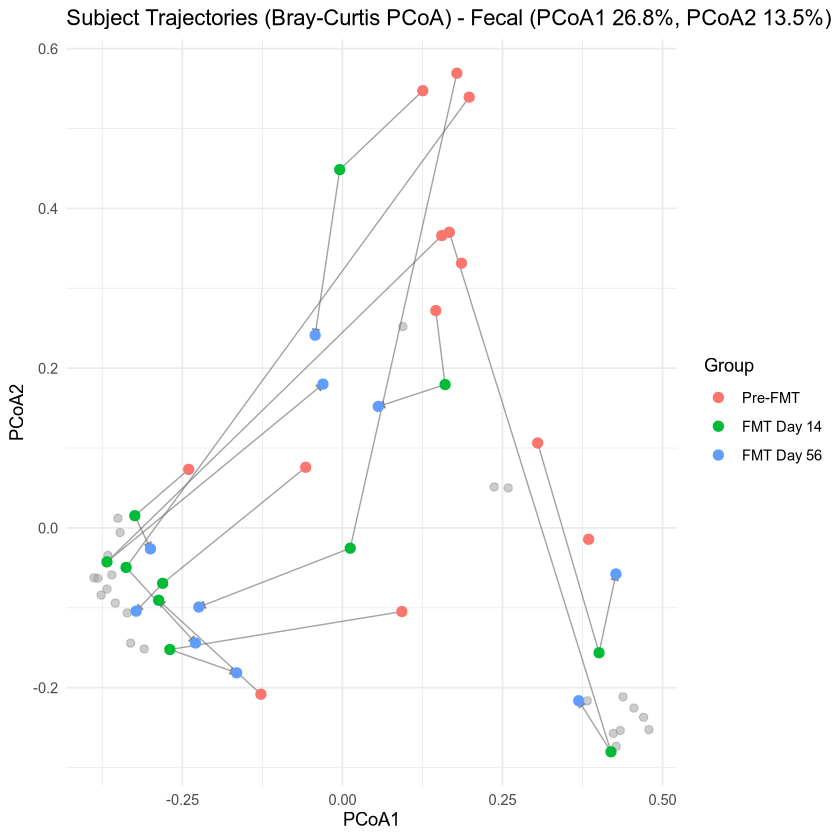

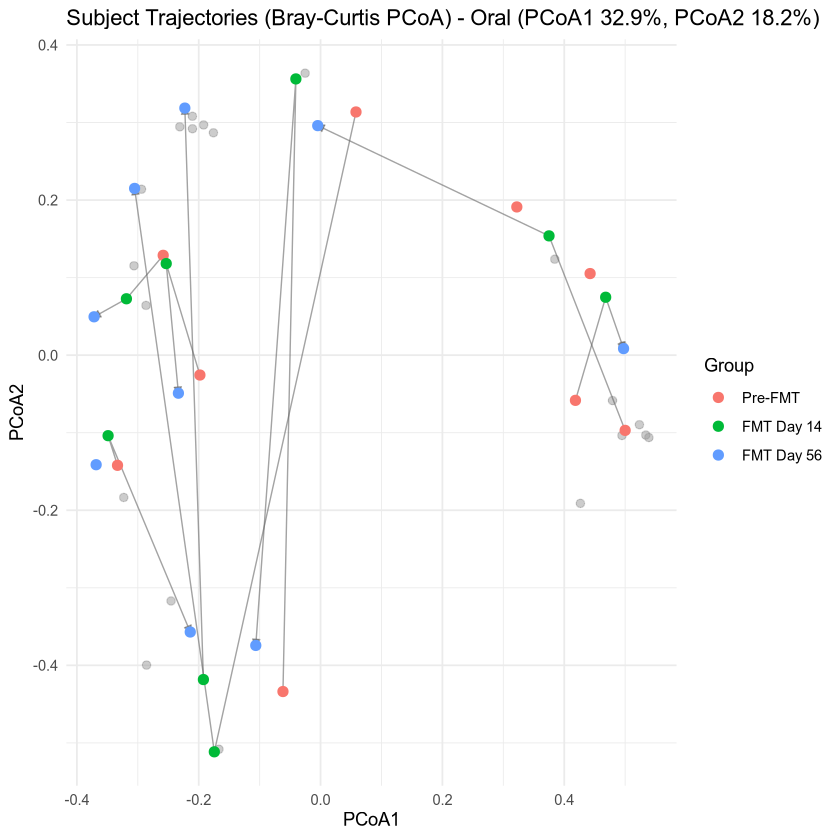

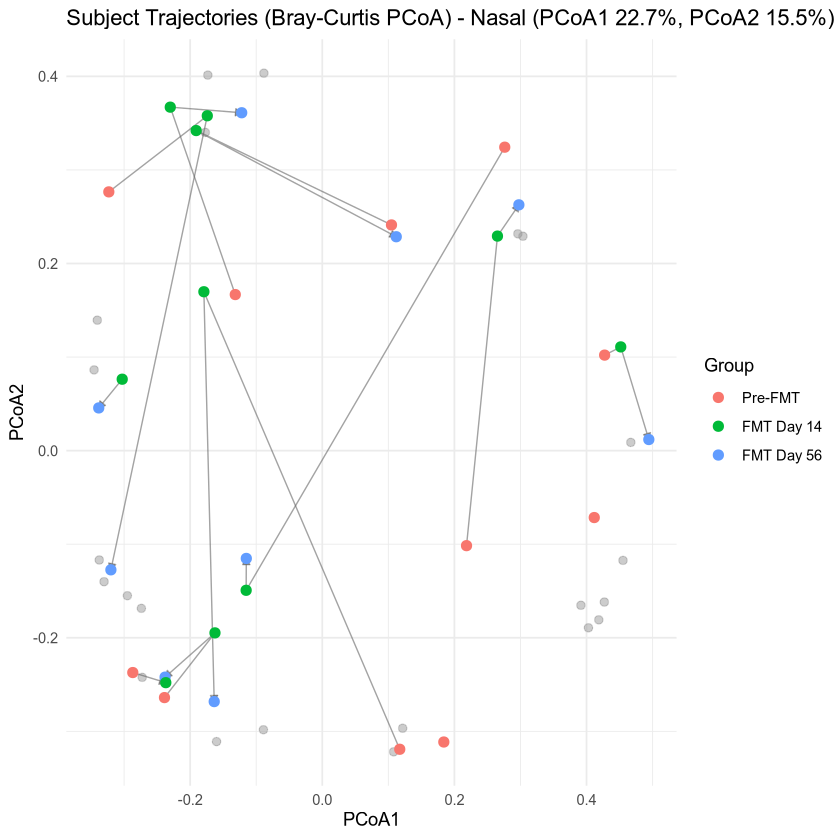

In [94]:
# ---- PCoA computed within each tissue, Healthy included as a static reference ----
tissue_pcoa_viz <- function(tissue_name, dist_mat, meta_df) {
  samples_tissue <- meta_df$sample[meta_df$tissue == tissue_name]
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- as.dist(dist_full[samples_tissue, samples_tissue])

  ord <- cmdscale(dist_sub, eig = TRUE, k = 2)
  pos_eig <- ord$eig[ord$eig > 0]
  var_exp <- round(pos_eig / sum(pos_eig) * 100, 1)

  df <- as.data.frame(ord$points)
  colnames(df) <- c("PCoA1", "PCoA2")
  df$sample <- samples_tissue
  df <- merge(df, meta_df, by = "sample")
  df$tissue_facet <- paste0(tissue_name, " (PCoA1 ", var_exp[1], "%, PCoA2 ", var_exp[2], "%)")
  df
}

# ---- Draws Healthy as static grey points; connects each FMT subject's timepoints with an arrowed path ----
plot_subject_trajectory <- function(tissue_name, dist_mat, meta_df) {
  df <- tissue_pcoa_viz(tissue_name, dist_mat, meta_df)

  df_fmt <- df %>%
    filter(condition_day_group != "Healthy") %>%
    mutate(condition_day_group = droplevels(condition_day_group)) %>%
    arrange(subject_id, condition_day_group)

  df_healthy <- df %>% filter(condition_day_group == "Healthy")

  ggplot() +
    geom_point(data = df_healthy, aes(x = PCoA1, y = PCoA2),
               color = "grey60", size = 2, alpha = 0.5) +
    geom_path(data = df_fmt, aes(x = PCoA1, y = PCoA2, group = subject_id),
              color = "grey40", linewidth = 0.4, alpha = 0.6,
              arrow = arrow(length = unit(0.15, "cm"), type = "closed")) +
    geom_point(data = df_fmt, aes(x = PCoA1, y = PCoA2, color = condition_day_group), size = 2.5) +
    theme_minimal() +
    labs(
      title = paste0("Subject Trajectories (Bray-Curtis PCoA) - ", unique(df$tissue_facet)),
      x = "PCoA1", y = "PCoA2", color = "Group"
    )
}

fecal_trajectory_plot <- plot_subject_trajectory("Fecal", bray, meta_bray_viz)
oral_trajectory_plot  <- plot_subject_trajectory("Oral",  bray, meta_bray_viz)
nasal_trajectory_plot <- plot_subject_trajectory("Nasal", bray, meta_bray_viz)

fecal_trajectory_plot
oral_trajectory_plot
nasal_trajectory_plot


### 2. Distance-to-Centroid (Dispersion) Check

`adonis2`/PERMANOVA tests for differences in group **location** (centroid), but it's sensitive to differences in group **dispersion** (spread) too -- a significant PERMANOVA can partly reflect unequal spread rather than a true compositional shift. `betadisper()` tests this directly: it computes each sample's distance to its own group centroid, then a permutation ANOVA (`permutest`) on those distances tests whether dispersion differs by group. 


In [95]:
# ---- betadisper: distance-to-centroid per sample, within each tissue's FMT-only PERMANOVA data ----
compute_betadisper <- function(tissue_name, fit, dist_mat) {
  d <- fit$data
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- as.dist(dist_full[d$sample, d$sample])

  bd <- betadisper(dist_sub, group = d$condition_day_group)

  list(
    tissue = tissue_name,
    bd     = bd,
    df     = data.frame(
      tissue               = tissue_name,
      sample               = names(bd$distances),
      condition_day_group  = d$condition_day_group[match(names(bd$distances), d$sample)],
      distance_to_centroid = bd$distances
    )
  )
}

fecal_betadisper <- compute_betadisper("Fecal", fecal_permanova, bray)
oral_betadisper  <- compute_betadisper("Oral",  oral_permanova,  bray)
nasal_betadisper <- compute_betadisper("Nasal", nasal_permanova, bray)

# ---- Formal test: does dispersion (spread) itself differ by group, within each tissue? ----
cat("==== Fecal (dispersion homogeneity test) ====\n"); print(permutest(fecal_betadisper$bd, permutations = 999))
cat("\n==== Oral (dispersion homogeneity test) ====\n");  print(permutest(oral_betadisper$bd,  permutations = 999))
cat("\n==== Nasal (dispersion homogeneity test) ====\n"); print(permutest(nasal_betadisper$bd, permutations = 999))


==== Fecal (dispersion homogeneity test) ====

Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
          Df  Sum Sq  Mean Sq      F N.Perm Pr(>F)  
Groups     2 0.12073 0.060363 2.7631    999  0.089 .
Residuals 31 0.67722 0.021846                       
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

==== Oral (dispersion homogeneity test) ====

Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
          Df  Sum Sq  Mean Sq      F N.Perm Pr(>F)
Groups     2 0.01479 0.007397 0.4741    999  0.613
Residuals 23 0.35888 0.015604                     

==== Nasal (dispersion homogeneity test) ====

Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
          Df  Sum Sq  Mean Sq      F N.Perm Pr(>F)
Groups     2 0.00085 0.000423 0.0302    999 

### Figure X. Within-group dispersion (distance to centroid) of Bray-Curtis distances, by tissue and timepoint.
Each point represents one sample's Bray-Curtis distance to its group's centroid (i.e., how compositionally atypical that sample is relative to the average for its group), computed separately within each tissue. betadisper() (vegan) was used to compute distances; group homogeneity of dispersion was tested via permutation ANOVA (999 permutations). Dispersion did not differ significantly across timepoints in any tissue (Fecal: F(2,20) = 2.56, p = 0.106; Oral: F(2,23) = 0.47, p = 0.605; Nasal: F(2,27) = 0.03, p = 0.967), indicating that the significant Fecal PERMANOVA result (main text) reflects a genuine shift in community composition (centroid location) rather than unequal within-group variance.

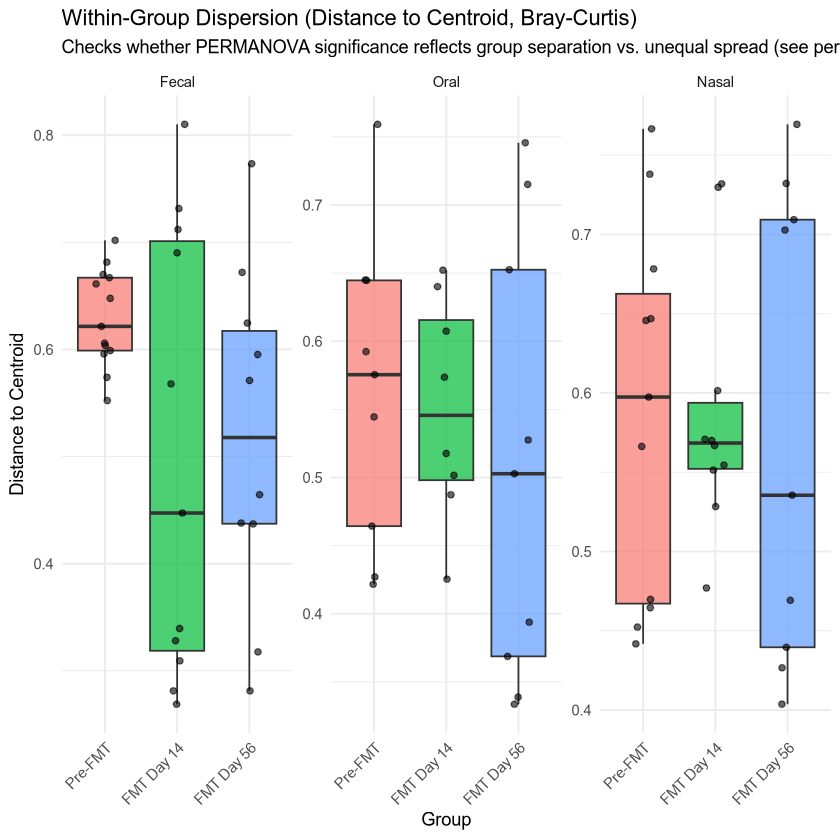

In [96]:
# ---- Distance-to-centroid boxplot, faceted by tissue ----
betadisper_df <- rbind(fecal_betadisper$df, oral_betadisper$df, nasal_betadisper$df)
betadisper_df$tissue <- factor(betadisper_df$tissue, levels = c("Fecal", "Oral", "Nasal"))

ggplot(betadisper_df, aes(x = condition_day_group, y = distance_to_centroid, fill = condition_day_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.15, alpha = 0.6, size = 1.5) +
  facet_wrap(~ tissue, scales = "free_y") +
  theme_minimal() +
  labs(
    title = "Within-Group Dispersion (Distance to Centroid, Bray-Curtis)",
    subtitle = "Checks whether PERMANOVA significance reflects group separation vs. unequal spread (see permutest() results above)",
    x = "Group", y = "Distance to Centroid", fill = "Group"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")


### 3. Forest Plot: PERMANOVA Effect Sizes (R²) Across Tissues

Same visual language as the LMM fixed-effect forest plot earlier, applied to `permanova_group_effect_summary` (omnibus) and `permanova_posthoc_by_tissue` (pairwise). One real difference: `adonis2`'s R² comes from a permutation test, not a closed-form estimator, so there's no analytic confidence interval to draw -- this plot shows point estimates only, with shape indicating BH-adjusted significance.


In [97]:
# ---- Combine omnibus + pairwise PERMANOVA results into one tidy table, tissue-grouped ----
permanova_omnibus_forest <- permanova_group_effect_summary %>%
  transmute(tissue, comparison = "Omnibus (condition_day_group)", R2, p_value, p_adj)

permanova_pairwise_forest <- permanova_posthoc_by_tissue %>%
  select(tissue, comparison, R2, p_value, p_adj)

permanova_forest_df <- bind_rows(permanova_omnibus_forest, permanova_pairwise_forest) %>%
  mutate(
    tissue     = factor(tissue, levels = c("Fecal", "Oral", "Nasal")),
    comparison = factor(comparison, levels = c("Omnibus (condition_day_group)",
                                                "Pre-FMT vs FMT Day 14",
                                                "Pre-FMT vs FMT Day 56",
                                                "FMT Day 14 vs FMT Day 56")),
    sig       = ifelse(p_adj < 0.05, "p_adj < 0.05", "n.s."),
    row_label = paste(tissue, comparison, sep = " \u2013 ")
  ) %>%
  arrange(tissue, comparison) %>%
  mutate(row_label = factor(row_label, levels = rev(unique(row_label))))

permanova_forest_df


tissue,comparison,R2,p_value,p_adj,sig,row_label
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
Fecal,Omnibus (condition_day_group),0.094,0.0010000,0.0030000,p_adj < 0.05,Fecal – Omnibus (condition_day_group)
Fecal,Pre-FMT vs FMT Day 14,0.092,0.0010000,0.0030000,p_adj < 0.05,Fecal – Pre-FMT vs FMT Day 14
Fecal,Pre-FMT vs FMT Day 56,0.085,0.0030000,0.0045000,p_adj < 0.05,Fecal – Pre-FMT vs FMT Day 56
Fecal,FMT Day 14 vs FMT Day 56,0.025,0.6190000,0.6190000,n.s.,Fecal – FMT Day 14 vs FMT Day 56
Oral,Omnibus (condition_day_group),0.060,0.6090000,0.6090000,n.s.,Oral – Omnibus (condition_day_group)
Oral,Pre-FMT vs FMT Day 14,0.038,0.6484375,0.6875000,n.s.,Oral – Pre-FMT vs FMT Day 14
Oral,Pre-FMT vs FMT Day 56,0.063,0.2343750,0.6875000,n.s.,Oral – Pre-FMT vs FMT Day 56
Oral,FMT Day 14 vs FMT Day 56,0.028,0.6875000,0.6875000,n.s.,Oral – FMT Day 14 vs FMT Day 56
Nasal,Omnibus (condition_day_group),0.052,0.5780000,0.6090000,n.s.,Nasal – Omnibus (condition_day_group)


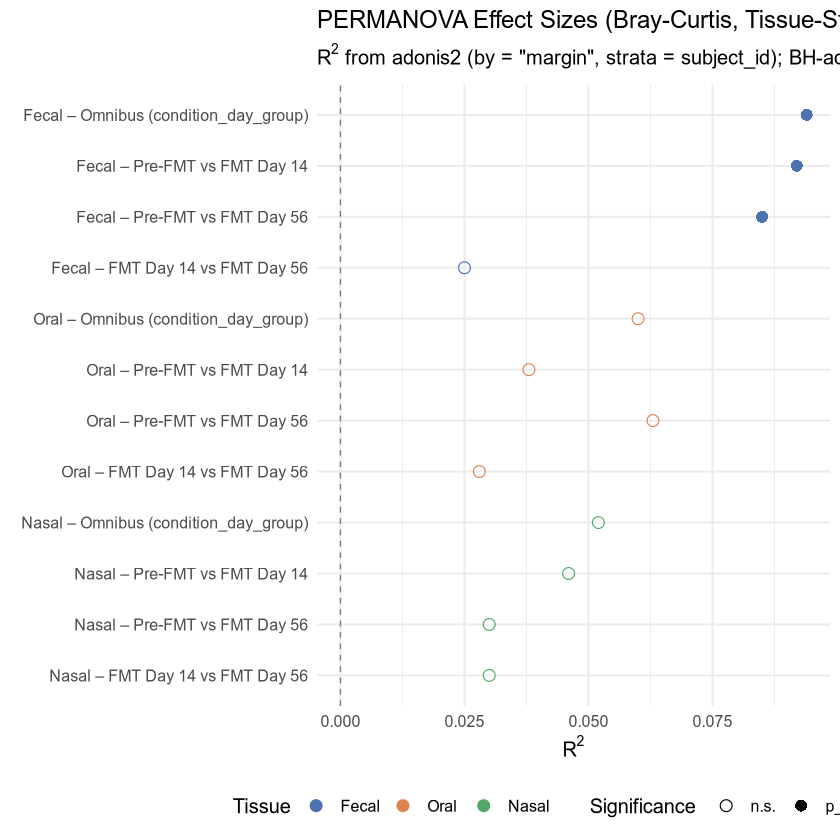

In [98]:
# ---- Forest plot of PERMANOVA R^2, point estimates only (no analytic CI for a permutation-based R^2) ----
ggplot(permanova_forest_df, aes(x = R2, y = row_label, color = tissue, shape = sig)) +
  geom_vline(xintercept = 0, color = "grey50", linetype = "dashed", linewidth = 0.4) +
  geom_point(size = 3) +
  scale_color_manual(values = c("Fecal" = "#4C72B0", "Oral" = "#DD8452", "Nasal" = "#55A868")) +
  scale_shape_manual(values = c("p_adj < 0.05" = 16, "n.s." = 1)) +
  labs(
    title = "PERMANOVA Effect Sizes (Bray-Curtis, Tissue-Stratified)",
    subtitle = expression(paste(R^2, " from adonis2 (by = \"margin\", strata = subject_id); BH-adjusted p within tissue")),
    x = expression(R^2), y = NULL, color = "Tissue", shape = "Significance"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "bottom")


### 4. Pairwise Bray-Curtis Distance Boxplots

A more intuitive, "plain-language" companion to the PERMANOVA result: every sample-pair's raw Bray-Curtis distance, categorized by which two groups the pair belongs to (e.g. "Pre-FMT vs Pre-FMT" = within-group, "Pre-FMT vs FMT Day 56" = between-group), faceted by tissue. What a significant PERMANOVA actually means: are between-timepoint sample pairs more dissimilar than within-timepoint pairs?


In [99]:
# ---- All pairwise Bray-Curtis distances within a tissue, labeled by the pair's group combination ----
compute_pairwise_bray_categories <- function(tissue_name, meta_df, dist_mat) {
  samples_tissue <- meta_df$sample[meta_df$tissue == tissue_name]
  dist_full <- as.matrix(dist_mat)
  dist_sub  <- dist_full[samples_tissue, samples_tissue]

  d <- meta_df[match(samples_tissue, meta_df$sample), ]
  group_lookup <- setNames(as.character(d$condition_day_group), d$sample)

  sample_pairs <- combn(samples_tissue, 2, simplify = FALSE)

  pair_df <- do.call(rbind, lapply(sample_pairs, function(p) {
    g_sorted <- sort(c(group_lookup[p[1]], group_lookup[p[2]]))  # collapses "A vs B" and "B vs A" into one category
    data.frame(
      tissue     = tissue_name,
      group_pair = paste(g_sorted, collapse = " vs "),
      distance   = dist_sub[p[1], p[2]]
    )
  }))

  pair_df
}

pairwise_bray_df <- rbind(
  compute_pairwise_bray_categories("Fecal", meta_bray_viz, bray),
  compute_pairwise_bray_categories("Oral",  meta_bray_viz, bray),
  compute_pairwise_bray_categories("Nasal", meta_bray_viz, bray)
)
pairwise_bray_df$tissue <- factor(pairwise_bray_df$tissue, levels = c("Fecal", "Oral", "Nasal"))


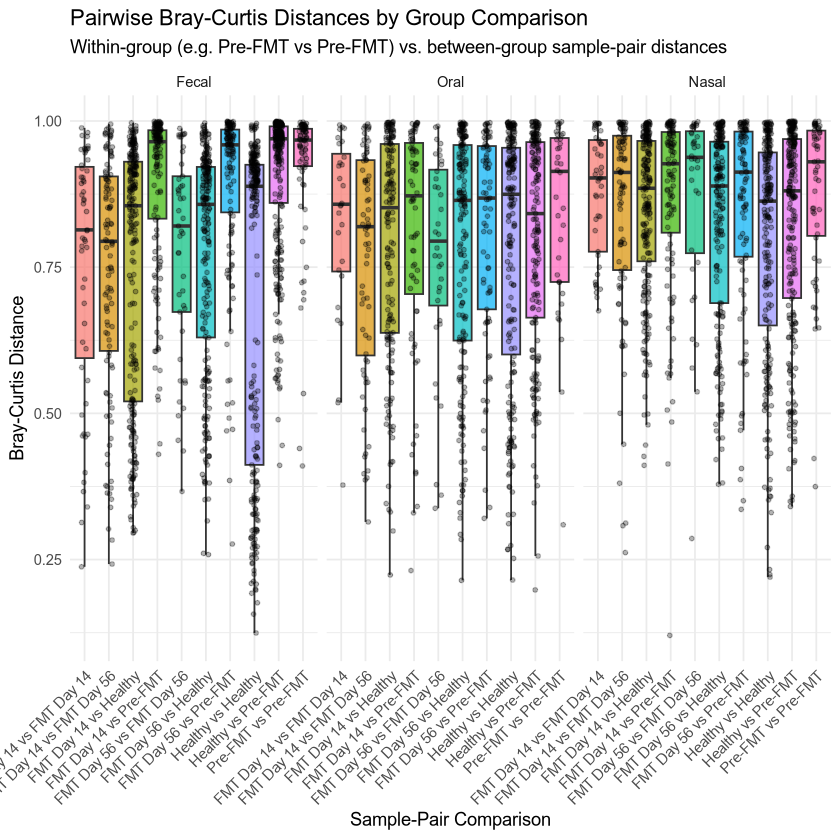

In [100]:
# ---- Boxplot: within-group vs. between-group pairwise Bray-Curtis distances, by tissue ----
ggplot(pairwise_bray_df, aes(x = group_pair, y = distance, fill = group_pair)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.15, alpha = 0.3, size = 1) +
  facet_wrap(~ tissue, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Pairwise Bray-Curtis Distances by Group Comparison",
    subtitle = "Within-group (e.g. Pre-FMT vs Pre-FMT) vs. between-group sample-pair distances",
    x = "Sample-Pair Comparison", y = "Bray-Curtis Distance"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")


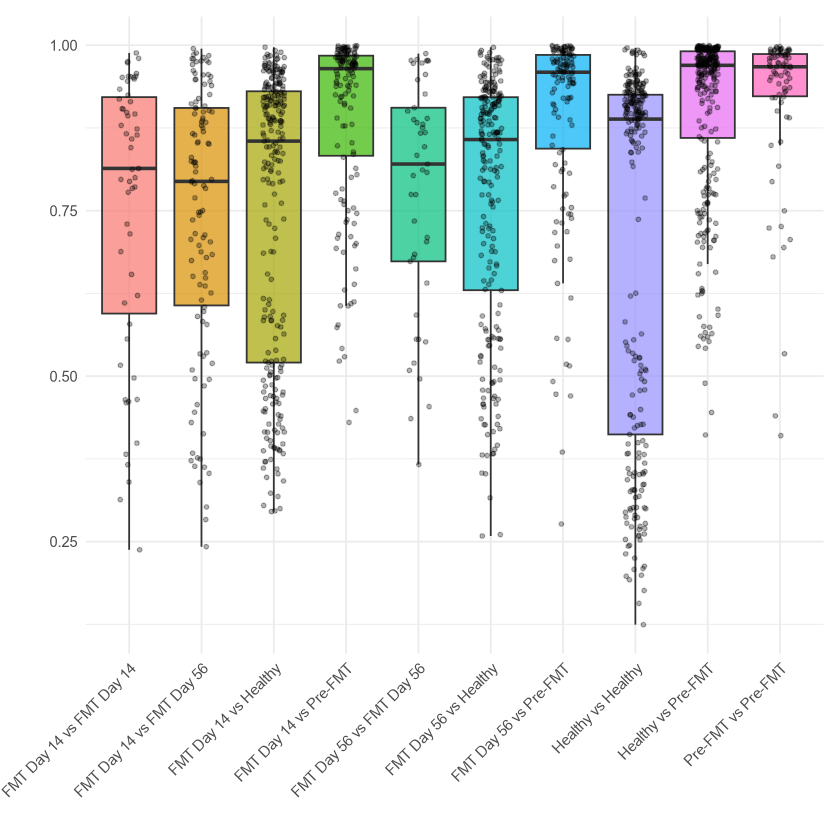

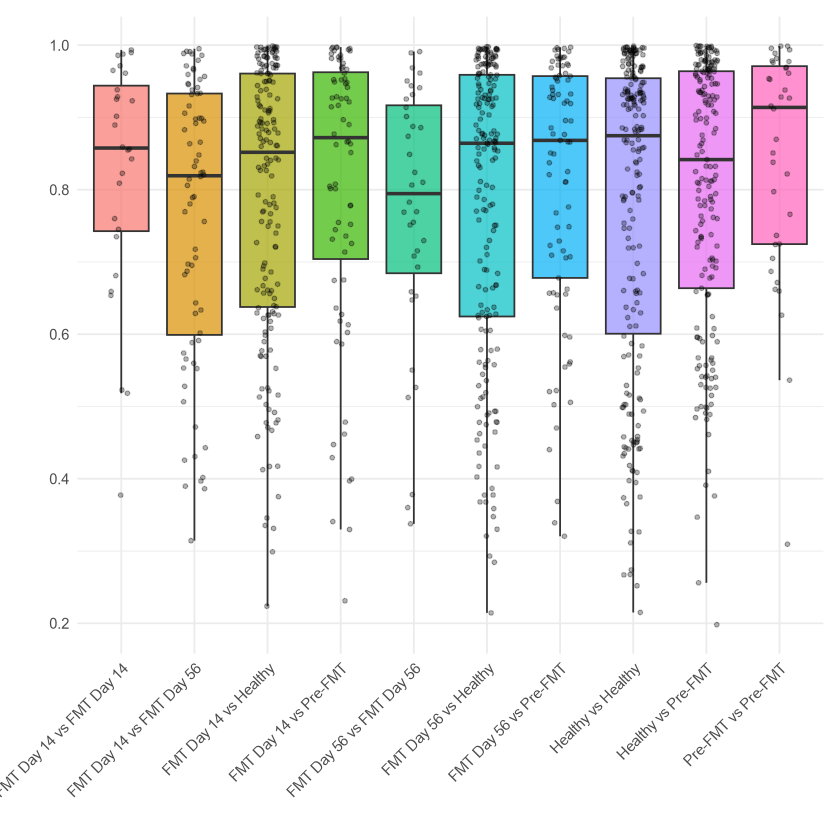

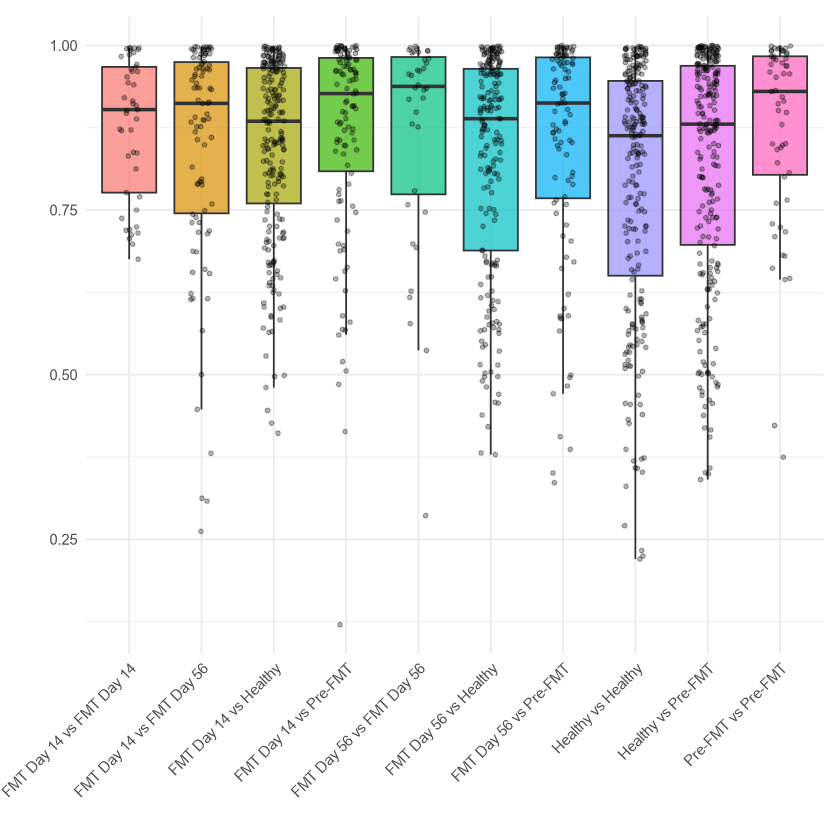

In [209]:
# ---- One separate plot per tissue, instead of facet_wrap ----
plot_pairwise_bray_tissue <- function(tissue_name, pairwise_df) {
  df <- pairwise_df %>% filter(tissue == tissue_name)

  ggplot(df, aes(x = group_pair, y = distance, fill = group_pair)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.7) +
    geom_jitter(width = 0.15, alpha = 0.3, size = 1) +
    theme_minimal() +
    labs(
      #title = paste0("Pairwise Bray-Curtis Distances by Group Comparison - ", tissue_name),
      #subtitle = "Within-group (e.g. Pre-FMT vs Pre-FMT) vs. between-group sample-pair distances",
      x = " ", y = " "
    ) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1), plot.margin = margin(t = 10, r = 10, b = 10, l = 15), legend.position = "none")
}

fecal_pairwise_bray_plot <- plot_pairwise_bray_tissue("Fecal", pairwise_bray_df)
oral_pairwise_bray_plot  <- plot_pairwise_bray_tissue("Oral",  pairwise_bray_df)
nasal_pairwise_bray_plot <- plot_pairwise_bray_tissue("Nasal", pairwise_bray_df)

fecal_pairwise_bray_plot
oral_pairwise_bray_plot
nasal_pairwise_bray_plot

Relative Abundance

Phylum stacked plots

In [19]:
# load ali_merged_counts.tsv
phylum_counts <- read.table("phylum_counts.tsv", sep="\t", header= TRUE, row.names=1, check.names=FALSE)


In [20]:
# Read metadata
metadata <- read.table("sample_metadata.tsv", sep="\t", header=TRUE)

# Check column names
head(metadata)
# Strip whitespace from sample names
metadata$sample <- str_trim(metadata$sample)

# Match sample names in metadata to those in the count table
colnames(phylum_counts) <- str_trim(colnames(phylum_counts))

sample_ids <- colnames(phylum_counts)
metadata_filtered <- metadata %>% filter(sample %in% sample_ids)

# Optional: check if any samples are missing
setdiff(sample_ids, metadata_filtered$sample)


,sample,donor,day,tissue,condition,data_origin,sex
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,garrett_1,g18,0,Fecal,Healthy,garrett,female
2,garrett_2,g17,0,Fecal,Healthy,garrett,male
3,garrett_3,g10,0,Fecal,FMT,garrett,female
4,garrett_4,g3,0,Fecal,FMT,garrett,female
5,garrett_5,g3,56,Fecal,FMT,garrett,female
6,garrett_6,g19,14,Fecal,Healthy,garrett,female


[1] "garrett_20" "garrett_73"

In [21]:
# Convert to long format
counts_long <- phylum_counts %>%
  as.data.frame() %>%
  rownames_to_column("Phylum") %>%
  pivot_longer(-Phylum, names_to = "sample", values_to = "Count")

# Join with metadata
counts_long <- counts_long %>%
  left_join(metadata_filtered, by = "sample")

# Check result
head(counts_long)

Phylum,sample,Count,donor,day,tissue,condition,data_origin,sex
<chr>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
Uroviricota,25617X10,17895744,m26,14,Fecal,FMT,mary,male
Uroviricota,25617X11,19770,m26,56,Fecal,FMT,mary,male
Uroviricota,25617X12,278971,m31,0,Fecal,Healthy,mary,male
Uroviricota,25617X13,141937,m31,14,Fecal,Healthy,mary,male
Uroviricota,25617X14,83041,m32,0,Fecal,FMT,mary,female
Uroviricota,25617X15,1244,m33,0,Fecal,FMT,mary,male


In [22]:
counts_long <- counts_long %>%
  group_by(sample, tissue) %>%
  mutate(Total_Count = sum(Count)) %>%
  ungroup() %>%
  mutate(Relative_Abundance = Count / Total_Count) %>%
  select(-Total_Count)


In [23]:
counts_long <- counts_long %>%
  mutate(Relative_Abundance = Relative_Abundance * 100)

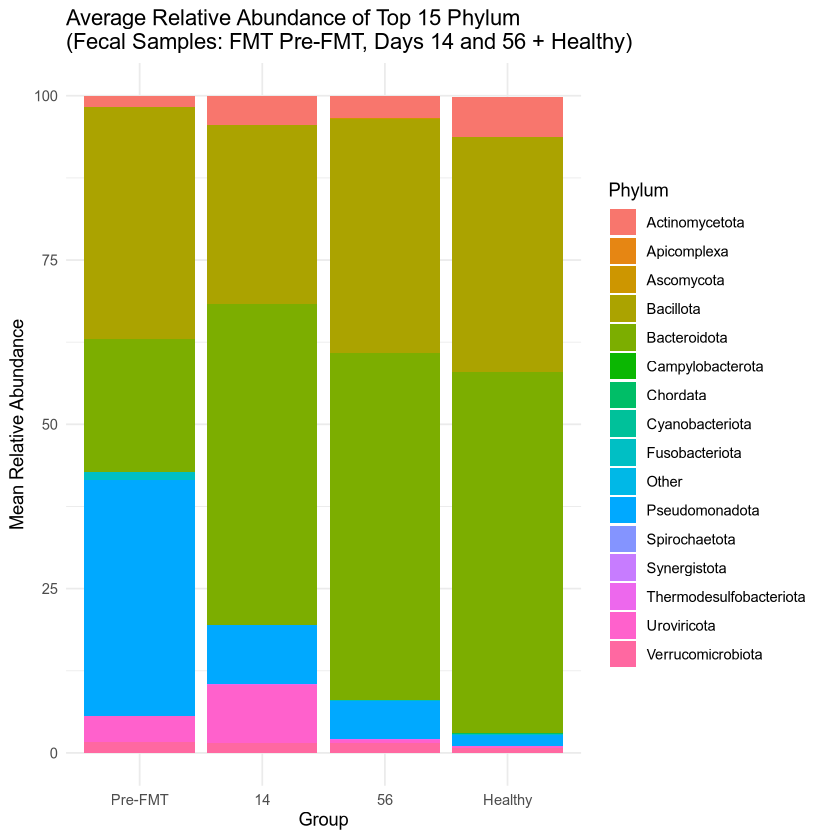

In [24]:
library(dplyr)
library(ggplot2)

# Step 1: Filter oral FMT samples (days 0, 14, 56)
Fecal_fmt <- counts_long %>%
  filter(tissue == "Fecal", condition == "FMT", day %in% c(0, 14, 56))

# Step 2: Identify top 15 genera in FMT oral samples
top15_genera <- Fecal_fmt %>%
  group_by(Phylum) %>%
  summarize(mean_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 15) %>%
  pull(Phylum)

# Step 3: Label other genera as "Other"
Fecal_fmt <- Fecal_fmt %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 4: Average relative abundance per day for FMT
fmt_avg <- Fecal_fmt %>%
  group_by(day, Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  # Change the 'day' factor to "Pre-FMT" for day 0
  mutate(group = as.character(day)) %>%
  mutate(group = ifelse(group == "0", "Pre-FMT", group))

# Step 5: Process Healthy oral samples (only days 0 and 14)
Fecal_healthy <- counts_long %>%
  filter(tissue == "Fecal", condition == "Healthy", day %in% c(0, 14)) %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 6: Average relative abundance for combined Healthy group
healthy_avg <- Fecal_healthy %>%
  group_by(Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  mutate(group = "Healthy")

# Step 7: Combine FMT and Healthy data
combined_df <- bind_rows(fmt_avg %>% select(group, Phylum, mean_rel_abundance),
                         healthy_avg %>% select(group, Phylum, mean_rel_abundance))

# Step 8: Set group order for x-axis
combined_df$group <- factor(combined_df$group, levels = c("Pre-FMT", "14", "56", "Healthy"))

# Step 9: Plot
my_plot <- ggplot(combined_df, aes(x = group, y = mean_rel_abundance, fill = Phylum)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(title = "Average Relative Abundance of Top 15 Phylum\n(Fecal Samples: FMT Pre-FMT, Days 14 and 56 + Healthy)",
       x = "Group",
       y = "Mean Relative Abundance") +
  theme_minimal() 

my_plot

# 2. Use ggsave() to save the plot
ggsave("phylum_fecal_abundance_bar_chart.png", plot = my_plot, width = 8, height = 6, units = "in", bg = "white") 

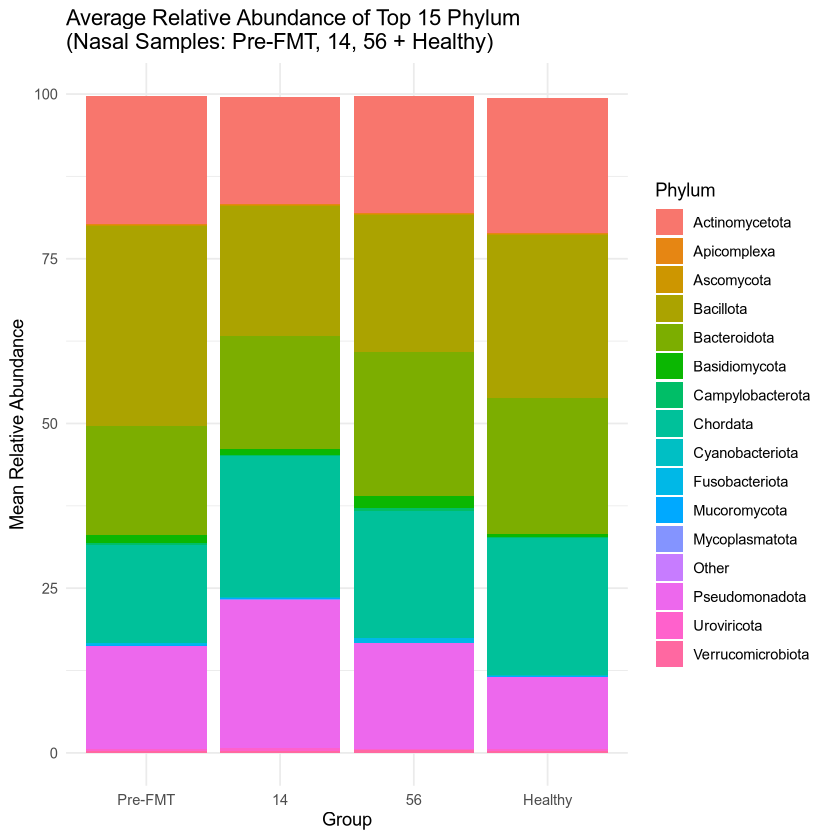

In [25]:
library(dplyr)
library(ggplot2)

# Step 1: Filter oral FMT samples (days 0, 14, 56)
Nasal_fmt <- counts_long %>%
  filter(tissue == "Nasal", condition == "FMT", day %in% c(0, 14, 56))

# Step 2: Identify top 15 genera in FMT oral samples
top15_genera <- Nasal_fmt %>%
  group_by(Phylum) %>%
  summarize(mean_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 15) %>%
  pull(Phylum)

# Step 3: Label other genera as "Other"
Nasal_fmt <- Nasal_fmt %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 4: Average relative abundance per day for FMT
fmt_avg <- Nasal_fmt %>%
  group_by(day, Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  # Change the 'day' factor to "Pre-FMT" for day 0
  mutate(group = as.character(day)) %>%
  mutate(group = ifelse(group == "0", "Pre-FMT", group))

# Step 5: Process Healthy oral samples (only days 0 and 14)
Nasal_healthy <- counts_long %>%
  filter(tissue == "Nasal", condition == "Healthy", day %in% c(0, 14)) %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 6: Average relative abundance for combined Healthy group
healthy_avg <- Nasal_healthy %>%
  group_by(Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  mutate(group = "Healthy")

# Step 7: Combine FMT and Healthy data
combined_df <- bind_rows(fmt_avg %>% select(group, Phylum, mean_rel_abundance),
                         healthy_avg %>% select(group, Phylum, mean_rel_abundance))

# Step 8: Set group order for x-axis
combined_df$group <- factor(combined_df$group, levels = c("Pre-FMT", "14", "56", "Healthy"))

# Step 9: Plot
ggplot(combined_df, aes(x = group, y = mean_rel_abundance, fill = Phylum)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(title = "Average Relative Abundance of Top 15 Phylum\n(Nasal Samples: Pre-FMT, 14, 56 + Healthy)",
       x = "Group",
       y = "Mean Relative Abundance") +
  theme_minimal() 

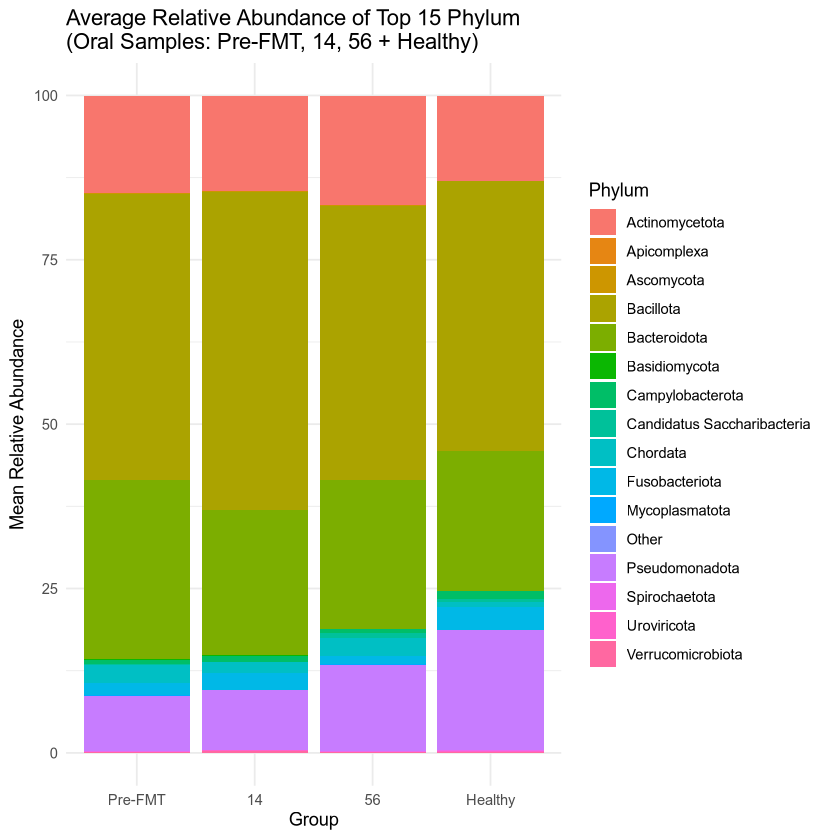

In [26]:
library(dplyr)
library(ggplot2)

# Step 1: Filter oral FMT samples (days 0, 14, 56)
Oral_fmt <- counts_long %>%
  filter(tissue == "Oral", condition == "FMT", day %in% c(0, 14, 56))

# Step 2: Identify top 15 genera in FMT oral samples
top15_genera <- Oral_fmt %>%
  group_by(Phylum) %>%
  summarize(mean_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 15) %>%
  pull(Phylum)

# Step 3: Label other genera as "Other"
Oral_fmt <- Oral_fmt %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 4: Average relative abundance per day for FMT
fmt_avg <- Oral_fmt %>%
  group_by(day, Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  # Change the 'day' factor to "Pre-FMT" for day 0
  mutate(group = as.character(day)) %>%
  mutate(group = ifelse(group == "0", "Pre-FMT", group))

# Step 5: Process Healthy oral samples (only days 0 and 14)
Oral_healthy <- counts_long %>%
  filter(tissue == "Oral", condition == "Healthy", day %in% c(0, 14)) %>%
  mutate(Phylum = ifelse(Phylum %in% top15_genera, Phylum, "Other"))

# Step 6: Average relative abundance for combined Healthy group
healthy_avg <- Oral_healthy %>%
  group_by(Phylum) %>%
  summarize(mean_rel_abundance = mean(Relative_Abundance), .groups = "drop") %>%
  mutate(group = "Healthy")

# Step 7: Combine FMT and Healthy data
combined_df <- bind_rows(fmt_avg %>% select(group, Phylum, mean_rel_abundance),
                         healthy_avg %>% select(group, Phylum, mean_rel_abundance))

# Step 8: Set group order for x-axis
combined_df$group <- factor(combined_df$group, levels = c("Pre-FMT", "14", "56", "Healthy"))

# Step 9: Plot
ggplot(combined_df, aes(x = group, y = mean_rel_abundance, fill = Phylum)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(title = "Average Relative Abundance of Top 15 Phylum\n(Oral Samples: Pre-FMT, 14, 56 + Healthy)",
       x = "Group",
       y = "Mean Relative Abundance") +
  theme_minimal() 

In [27]:
# This script calculates alpha diversity metrics (Richness and Evenness)
# and plots their joint distribution using a 2D density plot.

library(tidyverse)
library(vegan)
library(ggplot2)

# Load the data
# Make sure these files are in the same directory as this script.
counts_df <- read.csv("ali_merged_counts.tsv", sep='\t', row.names = 1)
metadata_df <- read.csv("sample_metadata.tsv", sep='\t', row.names = 1)
# remove row garrett_82 from metadata_df
metadata_df <- metadata_df %>%
  filter(rownames(metadata_df) != "garrett_82")
# Clean up sample names to ensure perfect matching across files
colnames(counts_df) <- gsub("^X", "", colnames(counts_df))
colnames(counts_df) <- trimws(colnames(counts_df))
metadata_df$sample <- trimws(rownames(metadata_df))



# Make sure the row names of the metadata match the column names of the counts
rownames(metadata_df) <- metadata_df$sample
counts_all <- counts_df[, rownames(metadata_df)]

# Remove taxa with zero counts across all samples
counts_all <- counts_all[rowSums(counts_all) > 0, ]

# Transpose the counts data so rows are samples and columns are taxa
counts_all_t <- t(counts_all)


# --- Calculate Alpha Diversity Metrics ---

# Calculate Richness using the ACE estimator, and rename the column to 'ACE'
richness_ace <- estimateR(counts_all_t) %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "sample") %>%
  select(sample, ACE = S.ACE)

# Calculate Pielou's Evenness
evenness_pielou <- diversity(counts_all_t, index = "shannon") / log(specnumber(counts_all_t)) %>%
   as.data.frame() 
colnames(evenness_pielou)[1] <- "Pielou"
evenness_pielou$sample <- rownames(evenness_pielou)

# Combine alpha diversity metrics with metadata
alpha_diversity_df <- metadata_df %>%
  left_join(richness_ace, by = "sample") %>%
  left_join(evenness_pielou, by = 'sample')

# Convert the relevant columns to numeric before plotting to avoid errors
alpha_diversity_df$ACE <- as.numeric(alpha_diversity_df$ACE)
alpha_diversity_df$Pielou <- as.numeric(alpha_diversity_df$Pielou)

# --- Create and save the density plot ---
# The plot now shows the joint density of richness and evenness
p <- ggplot(alpha_diversity_df, aes(x = ACE, y = Pielou)) +
  # Add the contour lines to show density
  geom_density_2d(aes(color = tissue)) +
  # Add the individual points
  geom_point(alpha = 0.5) +
  labs(
    title = "Density Distribution of Microbiome Richness and Evenness",
    x = "Richness (ACE)",
    y = "Evenness (Pielou)"
  ) +
  theme_minimal()

# Save the plot
png("Alpha_Diversity_Density_Plot.png", width = 800, height = 800)
print(p)
dev.off()


agg_record_979328494 
                   2